In [1]:
# ============================================================
# TRUST-STROKE (CDE-TT) — FROM SCRATCH
# Block A–C: Setup + Data + Baselines (SOTA-first)
# ============================================================

# -------------------------
# Block A) Setup + Reproducibility + Output folders
# -------------------------
import os, json, gc, math, warnings, platform, sys
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# Torch only needed later, but we keep DEVICE info for logging
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    torch = None
    DEVICE = "cpu"

# Output dirs
OUT_DIR = "./outputs"
DIRS = {
    "tables": os.path.join(OUT_DIR, "tables"),
    "figures": os.path.join(OUT_DIR, "figures"),
    "preds": os.path.join(OUT_DIR, "preds"),
    "logs": os.path.join(OUT_DIR, "logs"),
    "checkpoints": os.path.join(OUT_DIR, "checkpoints"),
}
for k, p in DIRS.items():
    os.makedirs(p, exist_ok=True)

# Plotting defaults for journal exports (we'll export PDF + 600dpi PNG)
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

def savefig(fig, name_base):
    fig.tight_layout()
    fig.savefig(os.path.join(DIRS["figures"], f"{name_base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(DIRS["figures"], f"{name_base}.png"), bbox_inches="tight", dpi=600)

def dump_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

config = {
    "seed": SEED,
    "device": DEVICE,
    "python": sys.version,
    "platform": platform.platform(),
}
dump_json(config, os.path.join(DIRS["logs"], "config.json"))

print("DEVICE:", DEVICE)
print("Outputs:", OUT_DIR)
print("Saved:", os.path.join(DIRS["logs"], "config.json"))

# -------------------------
# Block B) Data loading + schema + sanity checks
# -------------------------

# ✅ Set your CSV path here.
# For Kaggle: put the CSV inside a dataset and use /kaggle/input/<dataset>/<file>.csv
# For local: use a relative path.
DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"   # <-- CHANGE THIS
TARGET_COL = "stroke"                                  # <-- CHANGE THIS if needed

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# drop obvious ID-like columns if present
for c in ["id", "ID", "patient_id", "PatientID"]:
    if c in df.columns:
        df = df.drop(columns=[c])

assert TARGET_COL in df.columns, f"TARGET_COL={TARGET_COL} not found. Columns: {list(df.columns)[:20]}..."

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

print("Shape:", df.shape)
print("N:", len(df), "Pos rate:", float(y.mean()))

# missingness summary
miss = (X.isna().mean().sort_values(ascending=False) * 100).rename("missing_%").reset_index().rename(columns={"index":"feature"})
summary = pd.DataFrame({
    "feature": X.columns,
    "dtype": [str(X[c].dtype) for c in X.columns],
    "n_unique": [X[c].nunique(dropna=True) for c in X.columns],
}).merge(miss, on="feature", how="left")

summary = summary.sort_values(["missing_%","n_unique"], ascending=[False, True])
summary_path = os.path.join(DIRS["tables"], "data_summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

# ---- Column typing ----
def infer_cat_cols(df_: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df_.columns:
        if df_[c].dtype == "object" or str(df_[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            # small-cardinality ints -> categorical (optional)
            if pd.api.types.is_integer_dtype(df_[c]) and df_[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols

cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]

print("n_cat:", len(cat_cols), "n_num:", len(num_cols))

# ---- Sensitive columns placeholder (edit based on dataset) ----
# Put columns here if they exist (we'll use later for fairness evaluation).
SENSITIVE_CANDIDATES = ["sex", "gender", "race", "ethnicity", "age", "age_group"]
sensitive_cols = [c for c in SENSITIVE_CANDIDATES if c in X.columns]

schema = {
    "target": TARGET_COL,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "sensitive_cols_detected": sensitive_cols,
    "pos_rate": float(y.mean()),
    "n": int(len(y)),
}
dump_json(schema, os.path.join(DIRS["logs"], "schema.json"))
print("Saved:", os.path.join(DIRS["logs"], "schema.json"))

# -------------------------
# Block C) Baselines first (fast + strong SOTA tabular ML)
# Repeated Stratified CV + metrics: PR-AUC, ROC-AUC, Brier, ECE
# Optional: Calibrate each baseline (Platt/isotonic) using inner CV
# -------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# Optional packages (use if installed)
HAS_XGB = False
HAS_LGBM = False
HAS_CAT = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    pass

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    pass

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception:
    pass

print("HAS_XGB:", HAS_XGB, "HAS_LGBM:", HAS_LGBM, "HAS_CAT:", HAS_CAT)

# ---- ECE ----
def ece_score_binary(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

# ---- Preprocessor (fit inside CV only) ----
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

# ---- Baseline model zoo ----
models = {}

# Logistic regression (strong baseline)
models["LogReg"] = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=None
)

# Random Forest
models["RF"] = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=SEED,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# XGBoost (if available)
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        eval_metric="logloss",
        tree_method="hist",
        # scale_pos_weight can help imbalance (computed per fold is better, but ok for baseline)
    )

# CatBoost (if available)
if HAS_CAT:
    # Note: we use OHE pipeline for fairness across baselines.
    models["CatBoost"] = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False
    )

# ---- Optional calibration wrapper (turn ON if you want) ----
USE_CALIBRATION = True
CAL_METHOD = "sigmoid"   # "sigmoid" (Platt) or "isotonic" (needs more data)

from sklearn.calibration import CalibratedClassifierCV

def make_pipeline(base_estimator):
    clf = base_estimator
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", clf)
    ])
    if USE_CALIBRATION:
        # Calibrate on training fold via internal CV (no leakage)
        # This is slower but produces more credible Brier/ECE comparisons.
        pipe = Pipeline(steps=[
            ("prep", preprocess),
            ("cal", CalibratedClassifierCV(
                estimator=base_estimator,
                method=CAL_METHOD,
                cv=3
            ))
        ])
    return pipe

# ---- CV runner ----
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rows = []
for name, est in models.items():
    fold_id = 0
    for tr_idx, te_idx in rkf.split(X, y):
        fold_id += 1
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        pipe = make_pipeline(est)
        pipe.fit(X_tr, y_tr)

        # Probabilities
        p_te = pipe.predict_proba(X_te)[:, 1]

        pr = average_precision_score(y_te, p_te)
        roc = roc_auc_score(y_te, p_te)
        brier = brier_score_loss(y_te, p_te)
        ece = ece_score_binary(y_te, p_te, n_bins=15)

        rows.append({
            "model": name,
            "fold": fold_id,
            "pr_auc": float(pr),
            "roc_auc": float(roc),
            "brier": float(brier),
            "ece": float(ece),
            "pos_rate_test": float(np.mean(y_te)),
            "calibration": (f"Calibrated({CAL_METHOD})" if USE_CALIBRATION else "None"),
        })

        if fold_id % 5 == 0:
            print(f"{name:8s} | fold {fold_id:2d} | PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f}")

df_baselines = pd.DataFrame(rows)
out_csv = os.path.join(DIRS["tables"], "baselines_cv.csv")
df_baselines.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)

# Summary table
summary = df_baselines.groupby("model").agg(
    pr_mean=("pr_auc","mean"), pr_std=("pr_auc","std"),
    roc_mean=("roc_auc","mean"), roc_std=("roc_auc","std"),
    brier_mean=("brier","mean"), brier_std=("brier","std"),
    ece_mean=("ece","mean"), ece_std=("ece","std"),
).reset_index()

summary = summary.sort_values("pr_mean", ascending=False)
summary_path = os.path.join(DIRS["tables"], "baselines_cv_summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

display(summary)

DEVICE: cpu
Outputs: ./outputs
Saved: ./outputs/logs/config.json
Shape: (4603, 36)
N: 4603 Pos rate: 0.07864436237236584
Saved: ./outputs/tables/data_summary.csv
n_cat: 15 n_num: 20
Saved: ./outputs/logs/schema.json
HAS_XGB: True HAS_LGBM: True HAS_CAT: True
LogReg   | fold  5 | PR=0.2011 ROC=0.7309 Brier=0.0685 ECE=0.0200
LogReg   | fold 10 | PR=0.1436 ROC=0.6855 Brier=0.0704 ECE=0.0114
RF       | fold  5 | PR=0.1743 ROC=0.7152 Brier=0.0695 ECE=0.0241
RF       | fold 10 | PR=0.1416 ROC=0.6655 Brier=0.0706 ECE=0.0109
XGBoost  | fold  5 | PR=0.1402 ROC=0.6661 Brier=0.0714 ECE=0.0074
XGBoost  | fold 10 | PR=0.1087 ROC=0.6137 Brier=0.0721 ECE=0.0041
CatBoost | fold  5 | PR=0.1308 ROC=0.6668 Brier=0.0717 ECE=0.0022
CatBoost | fold 10 | PR=0.1415 ROC=0.6230 Brier=0.0713 ECE=0.0032

Saved: ./outputs/tables/baselines_cv.csv
Saved: ./outputs/tables/baselines_cv_summary.csv


,model,pr_mean,pr_std,roc_mean,roc_std,brier_mean,brier_std,ece_mean,ece_std
1,LogReg,0.174238,0.025438,0.713546,0.024400,0.069572,0.001060,0.015552,0.005473
2,RF,0.154033,0.014969,0.691866,0.025104,0.070504,0.000771,0.020848,0.006248
0,CatBoost,0.137157,0.018850,0.657507,0.024780,0.071904,0.000527,0.002935,0.000802
3,XGBoost,0.130008,0.013851,0.653206,0.026426,0.071990,0.000485,0.003851,0.002195


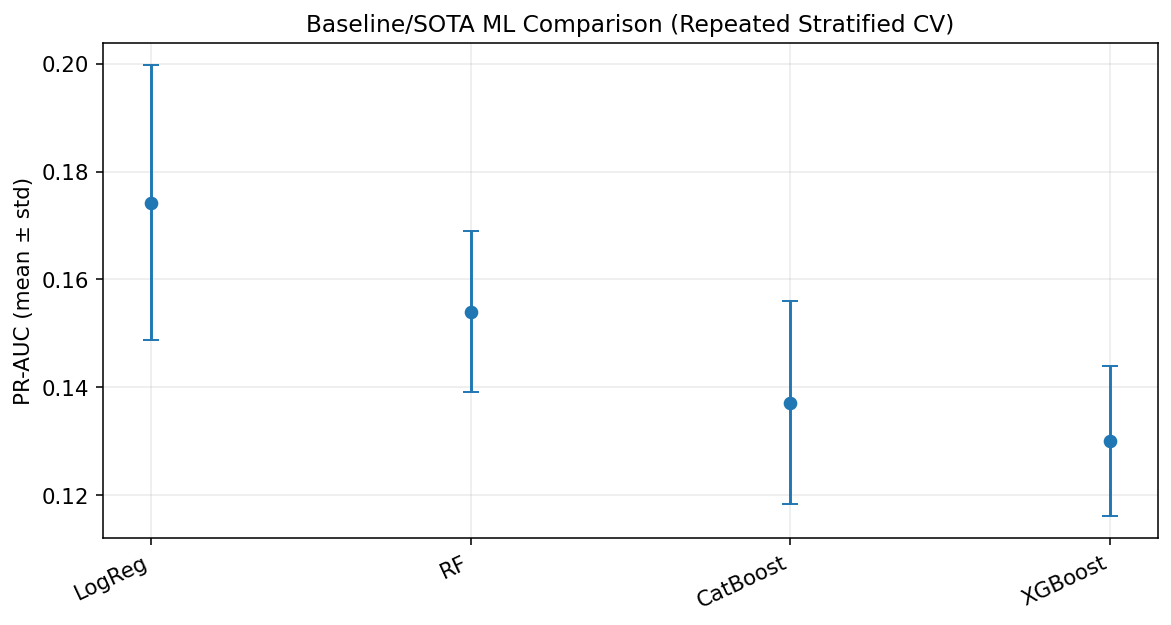

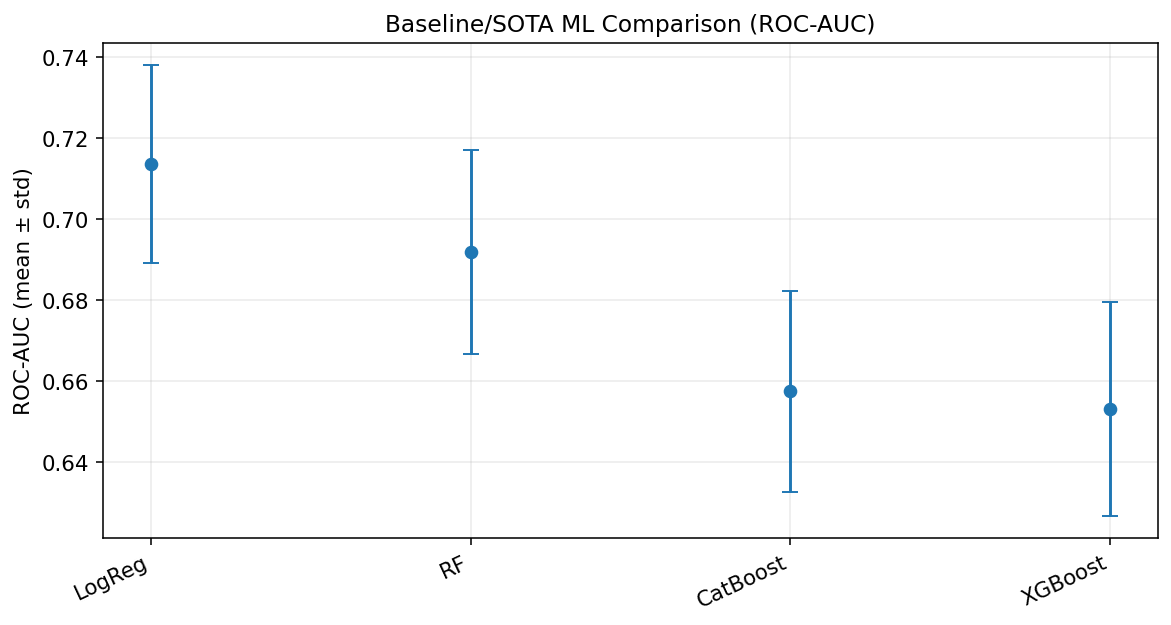

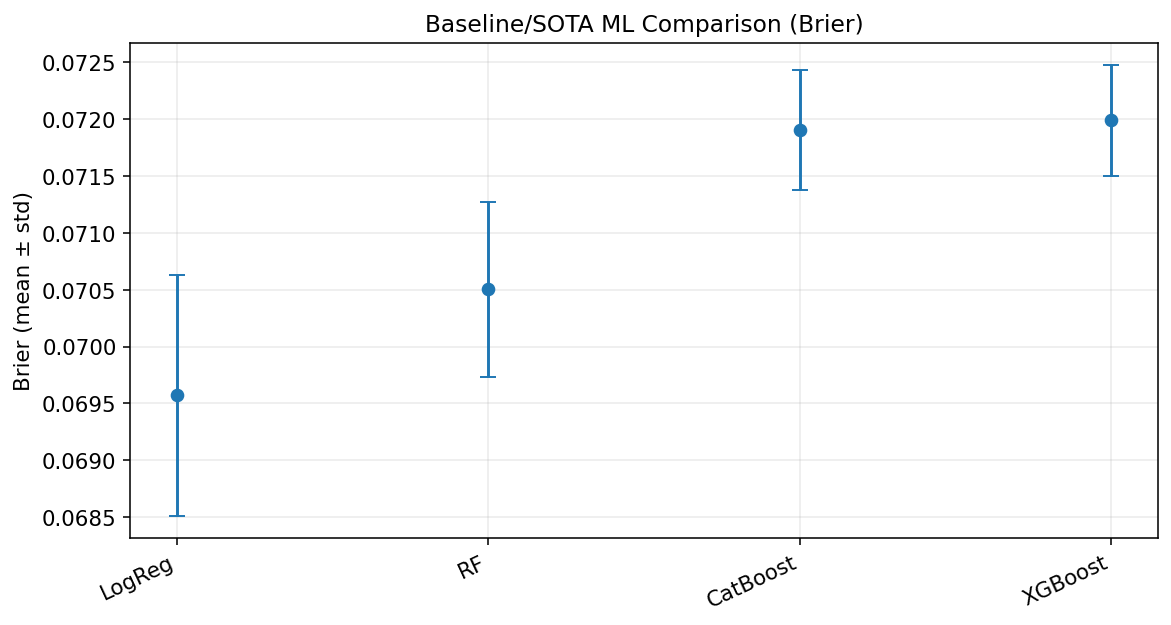

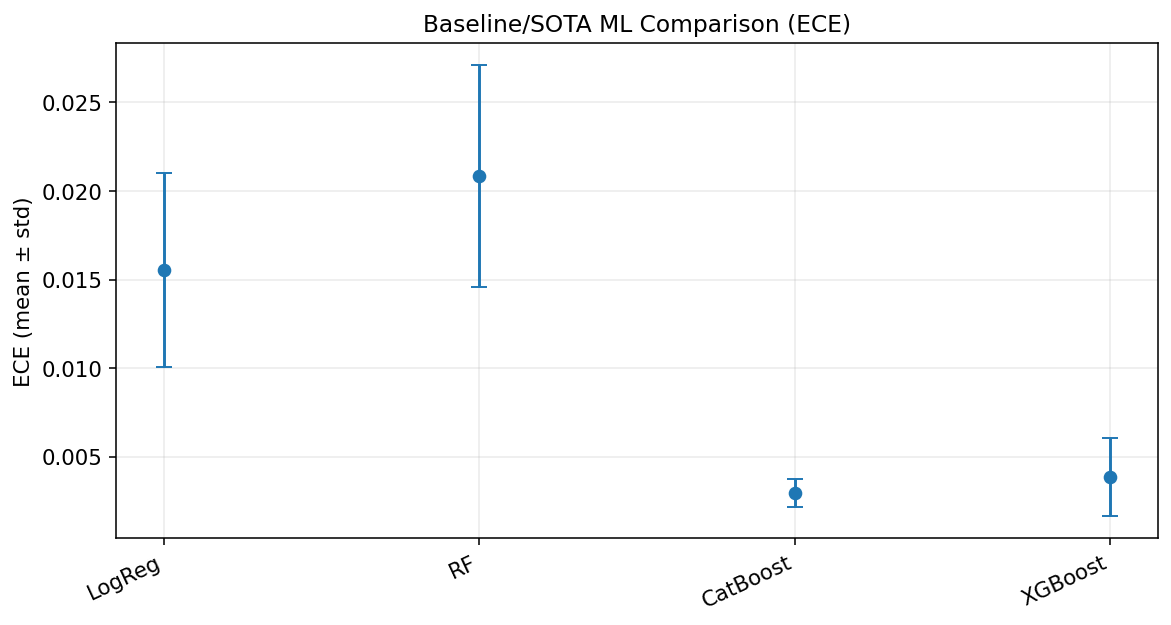

Saved figures in: ./outputs/figures


In [2]:
# -------------------------
# Block C) Journal-ready baseline comparison figure (PR-AUC primary)
# -------------------------
summary = pd.read_csv(os.path.join(DIRS["tables"], "baselines_cv_summary.csv"))

fig = plt.figure(figsize=(8.5, 4.6))
ax = plt.gca()

x = np.arange(len(summary))
ax.errorbar(x, summary["pr_mean"].values, yerr=summary["pr_std"].values, fmt="o", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(summary["model"].values, rotation=25, ha="right")
ax.set_ylabel("PR-AUC (mean ± std)")
ax.set_title("Baseline/SOTA ML Comparison (Repeated Stratified CV)")
ax.grid(True, alpha=0.25)

savefig(fig, "Fig_baseline_comparison_pr_auc")
plt.show()

# Optional: also save a 4-metric panel as separate figs (no subplots per our rule).
for metric, label in [("roc_mean","ROC-AUC"), ("brier_mean","Brier"), ("ece_mean","ECE")]:
    fig = plt.figure(figsize=(8.5, 4.6))
    ax = plt.gca()
    mean = summary[metric].values
    std = summary[metric.replace("_mean","_std")].values
    ax.errorbar(np.arange(len(summary)), mean, yerr=std, fmt="o", capsize=4)
    ax.set_xticks(np.arange(len(summary)))
    ax.set_xticklabels(summary["model"].values, rotation=25, ha="right")
    ax.set_ylabel(f"{label} (mean ± std)")
    ax.set_title(f"Baseline/SOTA ML Comparison ({label})")
    ax.grid(True, alpha=0.25)
    savefig(fig, f"Fig_baseline_comparison_{metric}")
    plt.show()

print("Saved figures in:", DIRS["figures"])

FTTransformer | fold  1 | PR=0.1506 ROC=0.6791 Brier=0.1298 ECE=0.1953
FTTransformer | fold  2 | PR=0.1522 ROC=0.6720 Brier=0.0981 ECE=0.1282
FTTransformer | fold  3 | PR=0.1606 ROC=0.6841 Brier=0.1242 ECE=0.2019
FTTransformer | fold  4 | PR=0.1755 ROC=0.6755 Brier=0.1225 ECE=0.2032
FTTransformer | fold  5 | PR=0.1922 ROC=0.7260 Brier=0.1069 ECE=0.1566
FTTransformer | fold  6 | PR=0.1550 ROC=0.7222 Brier=0.1132 ECE=0.1895
FTTransformer | fold  7 | PR=0.1477 ROC=0.6487 Brier=0.1100 ECE=0.1829
FTTransformer | fold  8 | PR=0.2659 ROC=0.7378 Brier=0.1244 ECE=0.2160
FTTransformer | fold  9 | PR=0.1530 ROC=0.7117 Brier=0.1214 ECE=0.1852
FTTransformer | fold 10 | PR=0.1521 ROC=0.6683 Brier=0.1032 ECE=0.1731

Saved: ./outputs/tables/sota_fttransformer_cv.csv
Saved: ./outputs/tables/sota_fttransformer_cv_summary.csv


,model,pr_mean,pr_std,roc_mean,roc_std,brier_mean,brier_std,ece_mean,ece_std
0,FTTransformer,0.170478,0.036269,0.69255,0.029598,0.115374,0.010555,0.183191,0.025502


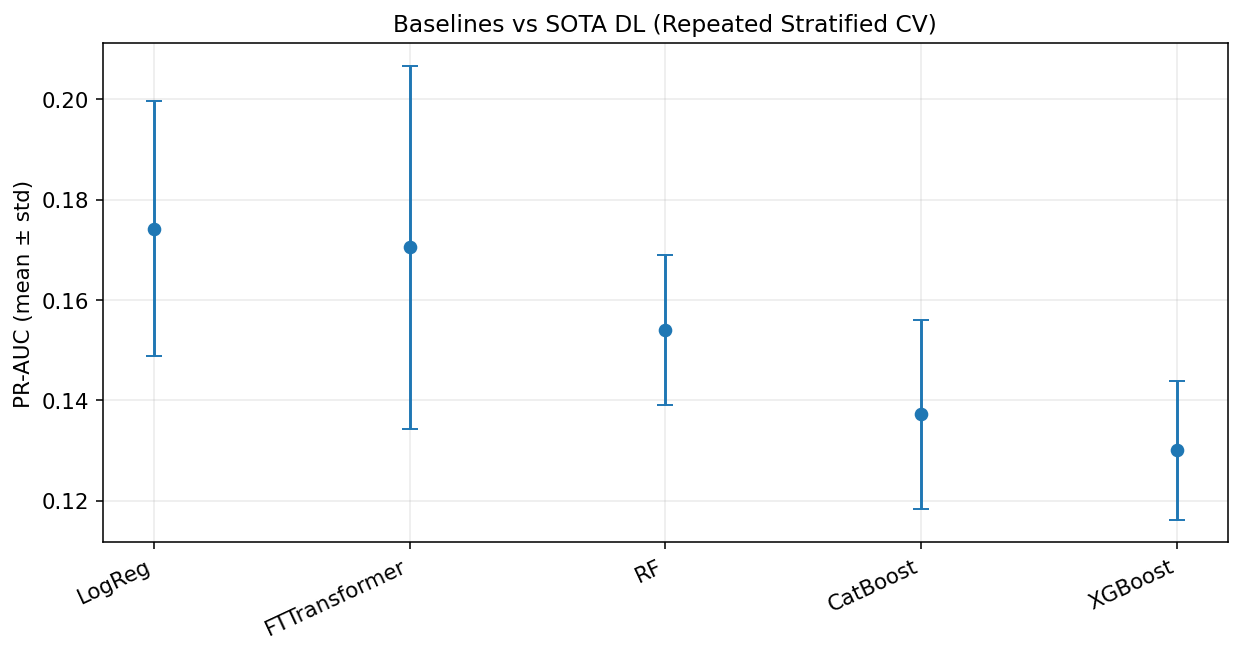

Saved: ./outputs/figures/Fig_baselines_vs_sota_pr_auc.pdf


In [3]:
# ============================================================
# Block D) SOTA DL models (CPU-safe)
# - FT-Transformer-like Tabular Transformer (PyTorch)
# - Optional: TabNet (if pytorch-tabnet is available)
# Same CV protocol: 5x2 repeated stratified
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# -------------------------
# Helpers
# -------------------------
def set_seed_all(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(SEED)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def ece_score_binary(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

# -------------------------
# Fold-safe preprocessing for DL (same as your CDE-TT style)
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map -> ids, 0 = UNK, explicit "MISSING"
    - Numerical: median-impute + z-score (fit on train only)
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.cat_sizes = []
        self.num_stats = {}

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum

# -------------------------
# Dataset + balanced sampler
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi

class BalancedBatchSampler(Sampler):
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(self.batch_size * pos_frac))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        self.rng = np.random.RandomState(seed)

    def __iter__(self):
        n_batches = int(np.ceil(len(self.y) / self.batch_size))
        for _ in range(n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield from idx.tolist()

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size)) * self.batch_size

# -------------------------
# FT-Transformer-like model (same as your baseline transformer)
# -------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x

class FTTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.2):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []
        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))
        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]
                tokens.append(self.num_proj(v))
        x = torch.stack(tokens, dim=1)  # (B,T,D)
        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        z = x[:, 0, :]
        return self.head(z).squeeze(-1)

# -------------------------
# Training utilities
# -------------------------
class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()

@torch.no_grad()
def predict_proba_torch(model, Xcat, Xnum, device="cpu", bs=2048):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0)
    model.eval()
    ps = []
    for x_cat, x_num, _ in dl:
        x_cat = x_cat.to(device) if x_cat is not None else None
        x_num = x_num.to(device) if x_num is not None else None
        logits = model(x_cat, x_num).detach().cpu().numpy()
        ps.append(sigmoid_np(logits))
    return np.concatenate(ps)

def train_one_fttransformer(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0,
    d_model=64, n_heads=4, n_layers=3, dropout=0.2,
    lr=2e-3, wd=1e-5, epochs=25, batch_size=256, pos_frac=0.30,
    patience=5
):
    set_seed_all(seed)

    device = DEVICE
    model = FTTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(device)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(device)
            x_cat = x_cat.to(device) if x_cat is not None else None
            x_num = x_num.to(device) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)
            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(device) if x_cat is not None else None
                x_num = x_num.to(device) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(sigmoid_np(logits))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# ============================================================
# Block D1) Run FT-Transformer CV (single model, no ensemble yet)
# This is SOTA DL "ceiling check" vs LogReg baseline.
# ============================================================

# CPU-safe hyperparams (adjust later)
FT_CFG = dict(
    d_model=64, n_heads=4, n_layers=3, dropout=0.20,
    lr=2e-3, wd=1e-5,
    epochs=25, batch_size=256, pos_frac=0.30,
    patience=5
)

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1

    X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
    X_te, y_te = X.iloc[te_idx], y[te_idx]

    # inner val split for early stopping (no leakage)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED + fold_id)
    tr_sub, va_sub = next(sss.split(X_tr_full, y_tr_full))
    X_tr, y_tr = X_tr_full.iloc[tr_sub], y_tr_full[tr_sub]
    X_va, y_va = X_tr_full.iloc[va_sub], y_tr_full[va_sub]

    prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
    Xtr_cat, Xtr_num = prep.transform(X_tr)
    Xva_cat, Xva_num = prep.transform(X_va)
    Xte_cat, Xte_num = prep.transform(X_te)

    model = train_one_fttransformer(
        Xtr_cat, Xtr_num, y_tr,
        Xva_cat, Xva_num, y_va,
        cat_sizes=prep.cat_sizes,
        seed=SEED + 10_000 + fold_id,
        **FT_CFG
    )

    p_te = predict_proba_torch(model, Xte_cat, Xte_num, device=DEVICE, bs=2048)

    pr = average_precision_score(y_te, p_te)
    roc = roc_auc_score(y_te, p_te)
    brier = brier_score_loss(y_te, p_te)
    ece = ece_score_binary(y_te, p_te, n_bins=15)

    rows.append({
        "model": "FTTransformer",
        "fold": fold_id,
        "pr_auc": float(pr),
        "roc_auc": float(roc),
        "brier": float(brier),
        "ece": float(ece),
        "device": DEVICE
    })

    print(f"FTTransformer | fold {fold_id:2d} | PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f}")

    # cleanup
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_ft = pd.DataFrame(rows)
df_ft_path = os.path.join(DIRS["tables"], "sota_fttransformer_cv.csv")
df_ft.to_csv(df_ft_path, index=False)
print("\nSaved:", df_ft_path)

ft_summary = df_ft.groupby("model").agg(
    pr_mean=("pr_auc","mean"), pr_std=("pr_auc","std"),
    roc_mean=("roc_auc","mean"), roc_std=("roc_auc","std"),
    brier_mean=("brier","mean"), brier_std=("brier","std"),
    ece_mean=("ece","mean"), ece_std=("ece","std"),
).reset_index()

ft_summary_path = os.path.join(DIRS["tables"], "sota_fttransformer_cv_summary.csv")
ft_summary.to_csv(ft_summary_path, index=False)
print("Saved:", ft_summary_path)

display(ft_summary)

# ============================================================
# Block D2) Compare FT-Transformer vs Baselines (single figure, PR-AUC)
# ============================================================

base_sum = pd.read_csv(os.path.join(DIRS["tables"], "baselines_cv_summary.csv"))
ft_sum = pd.read_csv(os.path.join(DIRS["tables"], "sota_fttransformer_cv_summary.csv"))

combo = pd.concat([base_sum, ft_sum], ignore_index=True)
combo = combo.sort_values("pr_mean", ascending=False).reset_index(drop=True)

fig = plt.figure(figsize=(9.0, 4.8))
ax = plt.gca()
x = np.arange(len(combo))
ax.errorbar(x, combo["pr_mean"].values, yerr=combo["pr_std"].values, fmt="o", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(combo["model"].values, rotation=25, ha="right")
ax.set_ylabel("PR-AUC (mean ± std)")
ax.set_title("Baselines vs SOTA DL (Repeated Stratified CV)")
ax.grid(True, alpha=0.25)
savefig(fig, "Fig_baselines_vs_sota_pr_auc")
plt.show()

print("Saved:", os.path.join(DIRS["figures"], "Fig_baselines_vs_sota_pr_auc.pdf"))

In [4]:
# ============================================================
# Block E1) FTTransformer FIX:
# - Natural sampling (no BalancedBatchSampler)
# - BCEWithLogits with pos_weight (handles imbalance without prior shift)
# - Temperature scaling on validation logits (per fold)
# ============================================================

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def fit_temperature_from_logits(logits_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar temperature T > 0 on validation logits by minimizing NLL.
    p = sigmoid(logits / T)
    """
    z = torch.tensor(logits_val.astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        loss = F.binary_cross_entropy_with_logits(z / T, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    return float((torch.exp(logT) + 1e-6).detach().cpu().item())

@torch.no_grad()
def predict_logits_torch(model, Xcat, Xnum, device="cpu", bs=2048):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0)
    model.eval()
    zs = []
    for x_cat, x_num, _ in dl:
        x_cat = x_cat.to(device) if x_cat is not None else None
        x_num = x_num.to(device) if x_num is not None else None
        logits = model(x_cat, x_num).detach().cpu().numpy()
        zs.append(logits)
    return np.concatenate(zs)

def train_one_ft_posweight(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0,
    d_model=64, n_heads=4, n_layers=3, dropout=0.2,
    lr=2e-3, wd=1e-5, epochs=25, batch_size=256,
    patience=5
):
    set_seed_all(seed)
    device = DEVICE

    model = FTTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(device)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    # Natural sampling: shuffle=True
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    # pos_weight = neg/pos in training subset
    pos = max(1.0, float(np.sum(ytr == 1)))
    neg = max(1.0, float(np.sum(ytr == 0)))
    pos_weight = torch.tensor([neg / pos], device=device, dtype=torch.float32)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(device)
            x_cat = x_cat.to(device) if x_cat is not None else None
            x_num = x_num.to(device) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # val PR-AUC for early stopping (use probabilities from logits)
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(device) if x_cat is not None else None
                x_num = x_num.to(device) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(sigmoid_np(logits))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ---- Run repeated CV ----
FT_POSW_CFG = dict(d_model=64, n_heads=4, n_layers=3, dropout=0.20, lr=2e-3, wd=1e-5,
                   epochs=30, batch_size=256, patience=6)

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
    X_te, y_te = X.iloc[te_idx], y[te_idx]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED + 999 + fold_id)
    tr_sub, va_sub = next(sss.split(X_tr_full, y_tr_full))
    X_tr, y_tr = X_tr_full.iloc[tr_sub], y_tr_full[tr_sub]
    X_va, y_va = X_tr_full.iloc[va_sub], y_tr_full[va_sub]

    prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
    Xtr_cat, Xtr_num = prep.transform(X_tr)
    Xva_cat, Xva_num = prep.transform(X_va)
    Xte_cat, Xte_num = prep.transform(X_te)

    model = train_one_ft_posweight(
        Xtr_cat, Xtr_num, y_tr,
        Xva_cat, Xva_num, y_va,
        cat_sizes=prep.cat_sizes,
        seed=SEED + 20_000 + fold_id,
        **FT_POSW_CFG
    )

    # logits for calibration
    z_va = predict_logits_torch(model, Xva_cat, Xva_num, device=DEVICE)
    T = fit_temperature_from_logits(z_va, y_va, max_iter=200, lr=0.05)

    z_te = predict_logits_torch(model, Xte_cat, Xte_num, device=DEVICE)
    p_te = sigmoid_np(z_te / T)

    pr = average_precision_score(y_te, p_te)
    roc = roc_auc_score(y_te, p_te)
    brier = brier_score_loss(y_te, p_te)
    ece = ece_score_binary(y_te, p_te, n_bins=15)

    rows.append({
        "model": "FTTransformer_posw_Tscaled",
        "fold": fold_id,
        "pr_auc": float(pr),
        "roc_auc": float(roc),
        "brier": float(brier),
        "ece": float(ece),
        "T": float(T),
    })

    print(f"FT_posw+TS | fold {fold_id:2d} | PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_ft2 = pd.DataFrame(rows)
df_ft2_path = os.path.join(DIRS["tables"], "sota_ft_posw_cv.csv")
df_ft2.to_csv(df_ft2_path, index=False)

ft2_summary = df_ft2.groupby("model").agg(
    pr_mean=("pr_auc","mean"), pr_std=("pr_auc","std"),
    roc_mean=("roc_auc","mean"), roc_std=("roc_auc","std"),
    brier_mean=("brier","mean"), brier_std=("brier","std"),
    ece_mean=("ece","mean"), ece_std=("ece","std"),
).reset_index()

ft2_summary_path = os.path.join(DIRS["tables"], "sota_ft_posw_cv_summary.csv")
ft2_summary.to_csv(ft2_summary_path, index=False)

print("\nSaved:", df_ft2_path)
print("Saved:", ft2_summary_path)
display(ft2_summary)

FT_posw+TS | fold  1 | PR=0.1894 ROC=0.7291 Brier=0.1778 ECE=0.2771 T=0.797
FT_posw+TS | fold  2 | PR=0.1560 ROC=0.6678 Brier=0.2463 ECE=0.4163 T=2.390
FT_posw+TS | fold  3 | PR=0.1678 ROC=0.6944 Brier=0.2492 ECE=0.4222 T=4.392
FT_posw+TS | fold  4 | PR=0.1433 ROC=0.6527 Brier=0.2509 ECE=0.4229 T=32.164
FT_posw+TS | fold  5 | PR=0.1787 ROC=0.7346 Brier=0.2087 ECE=0.3612 T=1.579
FT_posw+TS | fold  6 | PR=0.1744 ROC=0.7207 Brier=0.2501 ECE=0.4241 T=9.661
FT_posw+TS | fold  7 | PR=0.1541 ROC=0.6639 Brier=0.2457 ECE=0.4169 T=4.886
FT_posw+TS | fold  8 | PR=0.2101 ROC=0.7126 Brier=0.1840 ECE=0.2985 T=0.835
FT_posw+TS | fold  9 | PR=0.1640 ROC=0.7270 Brier=0.2482 ECE=0.4218 T=6.649
FT_posw+TS | fold 10 | PR=0.1511 ROC=0.6931 Brier=0.1123 ECE=0.1210 T=0.314

Saved: ./outputs/tables/sota_ft_posw_cv.csv
Saved: ./outputs/tables/sota_ft_posw_cv_summary.csv


,model,pr_mean,pr_std,roc_mean,roc_std,brier_mean,brier_std,ece_mean,ece_std
0,FTTransformer_posw_Tscaled,0.16887,0.02007,0.69959,0.029851,0.217323,0.046662,0.358208,0.099961


In [7]:
# ============================================================
# ONE-BLOCK MULTI-OPTION EXPERIMENT HARNESS (CPU-safe)
# Options in one run:
#  A) LogReg baseline (calibrated already in your baseline block) -> here we run plain balanced LogReg
#  B) FT + BalancedSampler + PRIOR CORRECTION + Temp Scaling  (recommended)
#  C) FT + BalancedSampler + Temp Scaling only (ablation)
#
# Outputs:
#  outputs/tables/exp_multi_options_per_fold.csv
#  outputs/tables/exp_multi_options_summary.csv
#  outputs/figures/Fig_multi_options_pr_auc.pdf/png
# ============================================================

import os, gc, numpy as np, pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- if you still have preprocess from baseline block (ColumnTransformer) ---
# we'll use it for LogReg to keep it strong & comparable
assert "preprocess" in globals(), "Expected `preprocess` from baseline block (ColumnTransformer)."

def savefig(fig, name_base):
    fig.tight_layout()
    fig.savefig(os.path.join(DIRS["figures"], f"{name_base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(DIRS["figures"], f"{name_base}.png"), bbox_inches="tight", dpi=600)

# ---------- Prior correction ----------
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def prior_correct_logits(logits, pi_sample, pi_true):
    """
    Case-control / rebalanced training prior correction:
    logit_corr = logit - log(pi_s/(1-pi_s)) + log(pi_t/(1-pi_t))
    """
    a = np.log(pi_sample / (1 - pi_sample + 1e-12))
    b = np.log(pi_true   / (1 - pi_true   + 1e-12))
    return logits - a + b

# ---------- Experiment configs ----------
# pi_sample should match your balanced sampler POS_FRAC
POS_FRAC = 0.30
PI_TRUE = float(np.mean(y))

EXPERIMENTS = [
    dict(
        name="LogReg_balanced",
        kind="logreg",
    ),
    dict(
        name="FT_balanced_TS_only",
        kind="ft",
        do_prior_correction=False,
        do_temp_scaling=True,
        pos_frac=POS_FRAC,
        # training params
        d_model=64, n_heads=4, n_layers=3, dropout=0.20,
        lr=2e-3, wd=1e-5, epochs=25, batch_size=256, patience=5,
    ),
    dict(
        name="FT_balanced_priorCorr_TS",
        kind="ft",
        do_prior_correction=True,
        do_temp_scaling=True,
        pos_frac=POS_FRAC,
        # training params
        d_model=64, n_heads=4, n_layers=3, dropout=0.20,
        lr=2e-3, wd=1e-5, epochs=25, batch_size=256, patience=5,
    ),
]

# ---------- CV protocol ----------
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
    X_te, y_te = X.iloc[te_idx], y[te_idx]

    # inner split for validation (early stop + temp scaling)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED + 111 + fold_id)
    tr_sub, va_sub = next(sss.split(X_tr_full, y_tr_full))
    X_tr, y_tr = X_tr_full.iloc[tr_sub], y_tr_full[tr_sub]
    X_va, y_va = X_tr_full.iloc[va_sub], y_tr_full[va_sub]

    for exp in EXPERIMENTS:
        name = exp["name"]

        if exp["kind"] == "logreg":
            # strong baseline; no leakage; same preprocessing as earlier baseline block
            model = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
            pipe = Pipeline(steps=[("prep", preprocess), ("clf", model)])
            pipe.fit(X_tr_full, y_tr_full)  # use full training fold (no need for inner split)

            p_te = pipe.predict_proba(X_te)[:, 1]
            pr = average_precision_score(y_te, p_te)
            roc = roc_auc_score(y_te, p_te)
            brier = brier_score_loss(y_te, p_te)
            ece = ece_score_binary(y_te, p_te, n_bins=15)

            rows.append({
                "exp": name,
                "fold": fold_id,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": np.nan,
            })
            continue

        # FT experiments
        prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
        Xtr_cat, Xtr_num = prep.transform(X_tr)
        Xva_cat, Xva_num = prep.transform(X_va)
        Xte_cat, Xte_num = prep.transform(X_te)

        # train with balanced sampler (your earlier training fn uses it)
        model = train_one_fttransformer(
            Xtr_cat, Xtr_num, y_tr,
            Xva_cat, Xva_num, y_va,
            cat_sizes=prep.cat_sizes,
            seed=SEED + 20_000 + fold_id,
            d_model=exp["d_model"], n_heads=exp["n_heads"], n_layers=exp["n_layers"], dropout=exp["dropout"],
            lr=exp["lr"], wd=exp["wd"], epochs=exp["epochs"],
            batch_size=exp["batch_size"], pos_frac=exp["pos_frac"],
            patience=exp["patience"],
        )

        # logits on val/test
        z_va = predict_logits_torch(model, Xva_cat, Xva_num, device=DEVICE)
        z_te = predict_logits_torch(model, Xte_cat, Xte_num, device=DEVICE)

        # prior correction (optional)
        if exp.get("do_prior_correction", False):
            z_va = prior_correct_logits(z_va, pi_sample=exp["pos_frac"], pi_true=PI_TRUE)
            z_te = prior_correct_logits(z_te, pi_sample=exp["pos_frac"], pi_true=PI_TRUE)

        # temperature scaling (optional)
        if exp.get("do_temp_scaling", True):
            T = fit_temperature_from_logits(z_va, y_va, max_iter=200, lr=0.05)
            p_te = sigmoid(z_te / T)
        else:
            T = 1.0
            p_te = sigmoid(z_te)

        pr = average_precision_score(y_te, p_te)
        roc = roc_auc_score(y_te, p_te)
        brier = brier_score_loss(y_te, p_te)
        ece = ece_score_binary(y_te, p_te, n_bins=15)

        rows.append({
            "exp": name,
            "fold": fold_id,
            "pr_auc": float(pr),
            "roc_auc": float(roc),
            "brier": float(brier),
            "ece": float(ece),
            "T": float(T),
        })

        print(f"{name:26s} | fold {fold_id:2d} | PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

        # cleanup
        del model
        gc.collect()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()

# ---------- Save tables ----------
df = pd.DataFrame(rows)
per_fold_path = os.path.join(DIRS["tables"], "exp_multi_options_per_fold.csv")
df.to_csv(per_fold_path, index=False)

summary = df.groupby("exp").agg(
    pr_mean=("pr_auc","mean"), pr_std=("pr_auc","std"),
    roc_mean=("roc_auc","mean"), roc_std=("roc_auc","std"),
    brier_mean=("brier","mean"), brier_std=("brier","std"),
    ece_mean=("ece","mean"), ece_std=("ece","std"),
    T_mean=("T","mean"),
).reset_index().sort_values("pr_mean", ascending=False)

summary_path = os.path.join(DIRS["tables"], "exp_multi_options_summary.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved:", per_fold_path)
print("Saved:", summary_path)
display(summary)

# ---------- Figure: PR-AUC comparison ----------
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9.0, 4.8))
ax = plt.gca()
x = np.arange(len(summary))
ax.errorbar(x, summary["pr_mean"].values, yerr=summary["pr_std"].values, fmt="o", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(summary["exp"].values, rotation=20, ha="right")
ax.set_ylabel("PR-AUC (mean ± std)")
ax.set_title("Multi-option comparison (same CV protocol)")
ax.grid(True, alpha=0.25)
savefig(fig, "Fig_multi_options_pr_auc")
plt.show()

print("Saved figure:", os.path.join(DIRS["figures"], "Fig_multi_options_pr_auc.pdf"))

FT_balanced_TS_only        | fold  1 | PR=0.1493 ROC=0.7036 Brier=0.1157 ECE=0.1386 T=0.586
FT_balanced_priorCorr_TS   | fold  1 | PR=0.1493 ROC=0.7036 Brier=0.0703 ECE=0.0193 T=1.043
FT_balanced_TS_only        | fold  2 | PR=0.1712 ROC=0.7098 Brier=0.1136 ECE=0.1280 T=0.681
FT_balanced_priorCorr_TS   | fold  2 | PR=0.1712 ROC=0.7098 Brier=0.0709 ECE=0.0234 T=1.069


KeyboardInterrupt: 

In [8]:
# ============================================================
# Block: SupCon pretraining + other small-data imbalance ideas
# Experiments:
# 1) FT_balanced_priorCorr_TS                     (baseline)
# 2) FT_SupCon_pretrain_then_finetune_priorCorr_TS (SupCon)
# 3) FT_balanced_rankloss_priorCorr_TS            (pairwise ranking loss)
# ============================================================

import os, gc, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# ---------- small helpers ----------
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

def prior_correct_logits(logits, pi_sample, pi_true):
    a = np.log(pi_sample / (1 - pi_sample + 1e-12))
    b = np.log(pi_true   / (1 - pi_true   + 1e-12))
    return logits - a + b

PI_TRUE = float(np.mean(y))
POS_FRAC = 0.30  # your balanced sampler target

# ============================================================
# 1) Modify FT model to expose an embedding (for contrastive pretraining)
# We wrap your FTTransformer and reuse its CLS representation.
# ============================================================

class FTWithEmbed(nn.Module):
    """
    Wraps the FTTransformer to expose embedding z (CLS token) + logits head.
    Uses the same tokenization as your FTTransformer.
    """
    def __init__(self, base_ft_model: nn.Module, d_model: int):
        super().__init__()
        self.base = base_ft_model
        self.d_model = d_model

        # Replace base head with identity-style access (we will implement our own head)
        # We assume base has blocks and cls token like your FTTransformer definition.
        # We'll replicate forward logic to get CLS embedding, then apply head.
        # (So we don't rely on internal attributes too much.)
        # IMPORTANT: this assumes your FTTransformer has:
        # - cat_embeds (ModuleList)
        # - num_proj (Linear)
        # - cls (Parameter)
        # - blocks (ModuleList)
        # - drop (Dropout)
        self.proj_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 128),
        )
        self.clf_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(0.2),
            nn.Linear(d_model, 1),
        )

    def embed(self, x_cat, x_num):
        # Build tokens exactly like your FTTransformer
        tokens = []
        if getattr(self.base, "n_cat", 0) > 0:
            for j, emb in enumerate(self.base.cat_embeds):
                tokens.append(emb(x_cat[:, j]))
        if getattr(self.base, "n_num", 0) > 0:
            for j in range(self.base.n_num):
                v = x_num[:, j:j+1]
                tokens.append(self.base.num_proj(v))
        x = torch.stack(tokens, dim=1)
        B = x.shape[0]
        cls = self.base.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.base.drop(x)
        for blk in self.base.blocks:
            x = blk(x)
        z = x[:, 0, :]  # CLS
        return z

    def forward(self, x_cat, x_num):
        z = self.embed(x_cat, x_num)
        logit = self.clf_head(z).squeeze(-1)
        return logit

    def supcon_proj(self, x_cat, x_num):
        z = self.embed(x_cat, x_num)
        h = self.proj_head(z)
        h = F.normalize(h, dim=-1)
        return h


# ============================================================
# 2) SupCon Loss (Supervised Contrastive Learning)
# ============================================================
class SupConLoss(nn.Module):
    """
    Supervised contrastive loss (Khosla et al.)
    Works with one view per sample (still useful for small tabular; positives are same-label samples).
    """
    def __init__(self, temperature=0.2):
        super().__init__()
        self.t = temperature

    def forward(self, feats, labels):
        """
        feats: (B, D) normalized
        labels: (B,) int
        """
        device = feats.device
        labels = labels.view(-1, 1)
        B = feats.size(0)

        # cosine sim
        sim = torch.matmul(feats, feats.T) / self.t
        # mask out self
        logits_mask = torch.ones_like(sim) - torch.eye(B, device=device)
        sim = sim * logits_mask

        # positives: same label, exclude self
        mask = torch.eq(labels, labels.T).float().to(device) * logits_mask

        # log_prob
        exp_sim = torch.exp(sim) * logits_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        # mean over positives
        denom = mask.sum(dim=1)
        loss = -(mask * log_prob).sum(dim=1) / (denom + 1e-12)
        return loss.mean()


# ============================================================
# 3) Pairwise ranking loss (helps PR-AUC; small-data friendly)
# ============================================================
def pairwise_rank_loss(logits, y):
    """
    AUC-style pairwise logistic loss:
    loss = log(1 + exp(-(s_pos - s_neg))) averaged over pairs
    For efficiency, we sample pairs within batch.
    """
    y = y.view(-1)
    pos = logits[y == 1]
    neg = logits[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return torch.tensor(0.0, device=logits.device)
    # sample to cap cost
    m = min(len(pos), 64)
    n = min(len(neg), 256)
    pos_s = pos[torch.randperm(len(pos), device=logits.device)[:m]]
    neg_s = neg[torch.randperm(len(neg), device=logits.device)[:n]]
    # pair differences
    diff = pos_s[:, None] - neg_s[None, :]
    return F.softplus(-diff).mean()


# ============================================================
# 4) Train functions
# ============================================================
def train_ft_baseline_balanced(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0,
    d_model=64, n_heads=4, n_layers=3, dropout=0.2,
    lr=2e-3, wd=1e-5, epochs=25, batch_size=256, pos_frac=0.30, patience=5
):
    # Uses your existing train_one_fttransformer if available
    # (fallback to the same function name)
    return train_one_fttransformer(
        Xtr_cat, Xtr_num, ytr,
        Xva_cat, Xva_num, yva,
        cat_sizes=cat_sizes,
        seed=seed,
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout,
        lr=lr, wd=wd, epochs=epochs, batch_size=batch_size, pos_frac=pos_frac, patience=patience
    )

def train_ft_rankloss_balanced(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0,
    d_model=64, n_heads=4, n_layers=3, dropout=0.2,
    lr=2e-3, wd=1e-5, epochs=25, batch_size=256, pos_frac=0.30, patience=5,
    alpha_rank=0.5
):
    # build base FT (same as in your training)
    torch.manual_seed(seed)
    base = FTTransformer(cat_sizes=cat_sizes, n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
                         d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout).to(DEVICE)
    model = base

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)
    sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed)
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = torch.utils.data.DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            yb = yb.to(DEVICE)

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)
            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_rank = pairwise_rank_loss(logits, yb)
            loss = (1 - alpha_rank) * loss_bce + alpha_rank * loss_rank
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR
        model.eval()
        ps, ys = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                z = model(x_cat, x_num).detach().cpu().numpy()
                ps.append(sigmoid(z))
                ys.append(yb.numpy())
        pva = np.concatenate(ps); yva_np = np.concatenate(ys).astype(int)
        pr = average_precision_score(yva_np, pva)
        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def supcon_pretrain_then_finetune(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0,
    d_model=64, n_heads=4, n_layers=3, dropout=0.2,
    lr_pre=2e-3, lr_ft=2e-3, wd=1e-5,
    epochs_pre=10, epochs_ft=20,
    batch_size=256, pos_frac=0.30, patience=5
):
    torch.manual_seed(seed)

    base = FTTransformer(cat_sizes=cat_sizes, n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
                         d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout).to(DEVICE)
    model = FTWithEmbed(base, d_model=d_model).to(DEVICE)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed)
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = torch.utils.data.DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    # -------- SupCon pretrain (encoder + proj_head) --------
    supcon = SupConLoss(temperature=0.2)
    opt_pre = torch.optim.AdamW(list(model.base.parameters()) + list(model.proj_head.parameters()),
                                lr=lr_pre, weight_decay=wd)

    for ep in range(1, epochs_pre + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            yb_i = yb.to(DEVICE).long()

            opt_pre.zero_grad(set_to_none=True)
            feats = model.supcon_proj(x_cat, x_num)  # (B, D) normalized
            loss = supcon(feats, yb_i)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_pre.step()

    # -------- Finetune classifier head (and optionally encoder) --------
    opt_ft = torch.optim.AdamW(model.parameters(), lr=lr_ft, weight_decay=wd)

    best_pr, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs_ft + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            yb = yb.to(DEVICE)

            opt_ft.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_ft.step()

        # early stop on val PR
        model.eval()
        ps, ys = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                z = model(x_cat, x_num).detach().cpu().numpy()
                ps.append(sigmoid(z))
                ys.append(yb.numpy())
        pva = np.concatenate(ps); yva_np = np.concatenate(ys).astype(int)
        pr = average_precision_score(yva_np, pva)
        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # return a model that outputs logits (fine)
    return model


# ============================================================
# 5) Run multi-option CV
# ============================================================

EXPS = [
    dict(name="FT_balanced_priorCorr_TS", kind="ft_baseline"),
    dict(name="FT_SupCon_pretrain_then_finetune_priorCorr_TS", kind="ft_supcon"),
    dict(name="FT_balanced_rankloss_priorCorr_TS", kind="ft_rankloss"),
]

CFG = dict(
    d_model=64, n_heads=4, n_layers=3, dropout=0.20,
    lr=2e-3, wd=1e-5,
    epochs=25, batch_size=256, pos_frac=0.30, patience=5,
)

CFG_SUPCON = dict(
    d_model=64, n_heads=4, n_layers=3, dropout=0.20,
    lr_pre=2e-3, lr_ft=2e-3, wd=1e-5,
    epochs_pre=10, epochs_ft=20,
    batch_size=256, pos_frac=0.30, patience=5,
)

CFG_RANK = dict(
    d_model=64, n_heads=4, n_layers=3, dropout=0.20,
    lr=2e-3, wd=1e-5,
    epochs=25, batch_size=256, pos_frac=0.30, patience=5,
    alpha_rank=0.5
)

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
    X_te, y_te = X.iloc[te_idx], y[te_idx]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED + 777 + fold_id)
    tr_sub, va_sub = next(sss.split(X_tr_full, y_tr_full))
    X_tr, y_tr = X_tr_full.iloc[tr_sub], y_tr_full[tr_sub]
    X_va, y_va = X_tr_full.iloc[va_sub], y_tr_full[va_sub]

    prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
    Xtr_cat, Xtr_num = prep.transform(X_tr)
    Xva_cat, Xva_num = prep.transform(X_va)
    Xte_cat, Xte_num = prep.transform(X_te)

    for exp in EXPS:
        name = exp["name"]
        kind = exp["kind"]

        if kind == "ft_baseline":
            model = train_ft_baseline_balanced(
                Xtr_cat, Xtr_num, y_tr, Xva_cat, Xva_num, y_va,
                cat_sizes=prep.cat_sizes, seed=SEED + 10000 + fold_id, **CFG
            )

        elif kind == "ft_supcon":
            model = supcon_pretrain_then_finetune(
                Xtr_cat, Xtr_num, y_tr, Xva_cat, Xva_num, y_va,
                cat_sizes=prep.cat_sizes, seed=SEED + 20000 + fold_id, **CFG_SUPCON
            )

        elif kind == "ft_rankloss":
            model = train_ft_rankloss_balanced(
                Xtr_cat, Xtr_num, y_tr, Xva_cat, Xva_num, y_va,
                cat_sizes=prep.cat_sizes, seed=SEED + 30000 + fold_id, **CFG_RANK
            )

        # logits, prior correction, temp scaling
        z_va = predict_logits_torch(model, Xva_cat, Xva_num, device=DEVICE)
        z_te = predict_logits_torch(model, Xte_cat, Xte_num, device=DEVICE)

        z_va = prior_correct_logits(z_va, pi_sample=POS_FRAC, pi_true=PI_TRUE)
        z_te = prior_correct_logits(z_te, pi_sample=POS_FRAC, pi_true=PI_TRUE)

        T = fit_temperature_from_logits(z_va, y_va, max_iter=200, lr=0.05)
        p_te = sigmoid(z_te / T)

        pr = average_precision_score(y_te, p_te)
        roc = roc_auc_score(y_te, p_te)
        brier = brier_score_loss(y_te, p_te)
        ece = ece_score_binary(y_te, p_te, n_bins=15)

        rows.append({
            "exp": name, "fold": fold_id,
            "pr_auc": float(pr), "roc_auc": float(roc),
            "brier": float(brier), "ece": float(ece), "T": float(T)
        })

        print(f"{name[:28]:28s} | fold {fold_id:2d} | PR={pr:.4f} ROC={roc:.4f} "
              f"Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df = pd.DataFrame(rows)
per_fold_path = os.path.join(DIRS["tables"], "exp_supcon_and_basic_per_fold.csv")
df.to_csv(per_fold_path, index=False)

summary = df.groupby("exp").agg(
    pr_mean=("pr_auc","mean"), pr_std=("pr_auc","std"),
    roc_mean=("roc_auc","mean"), roc_std=("roc_auc","std"),
    brier_mean=("brier","mean"), brier_std=("brier","std"),
    ece_mean=("ece","mean"), ece_std=("ece","std"),
    T_mean=("T","mean"),
).reset_index().sort_values("pr_mean", ascending=False)

summary_path = os.path.join(DIRS["tables"], "exp_supcon_and_basic_summary.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved:", per_fold_path)
print("Saved:", summary_path)
display(summary)

FT_balanced_priorCorr_TS     | fold  1 | PR=0.2101 ROC=0.6924 Brier=0.0688 ECE=0.0181 T=1.077
FT_SupCon_pretrain_then_fine | fold  1 | PR=0.2010 ROC=0.6974 Brier=0.0686 ECE=0.0320 T=1.105
FT_balanced_rankloss_priorCo | fold  1 | PR=0.1726 ROC=0.6910 Brier=0.0697 ECE=0.0155 T=1.103
FT_balanced_priorCorr_TS     | fold  2 | PR=0.1688 ROC=0.6787 Brier=0.0718 ECE=0.0203 T=1.005
FT_SupCon_pretrain_then_fine | fold  2 | PR=0.1795 ROC=0.6745 Brier=0.0714 ECE=0.0152 T=1.126
FT_balanced_rankloss_priorCo | fold  2 | PR=0.1549 ROC=0.6876 Brier=0.0712 ECE=0.0203 T=1.154
FT_balanced_priorCorr_TS     | fold  3 | PR=0.1642 ROC=0.7248 Brier=0.0701 ECE=0.0208 T=1.031
FT_SupCon_pretrain_then_fine | fold  3 | PR=0.1484 ROC=0.7011 Brier=0.0705 ECE=0.0128 T=1.046
FT_balanced_rankloss_priorCo | fold  3 | PR=0.1494 ROC=0.6766 Brier=0.0713 ECE=0.0179 T=1.139
FT_balanced_priorCorr_TS     | fold  4 | PR=0.1553 ROC=0.6765 Brier=0.0706 ECE=0.0270 T=0.925
FT_SupCon_pretrain_then_fine | fold  4 | PR=0.1829 ROC=0.715

,exp,pr_mean,pr_std,roc_mean,roc_std,brier_mean,brier_std,ece_mean,ece_std,T_mean
1,FT_balanced_priorCorr_TS,0.167674,0.019747,0.693344,0.023619,0.070262,0.001229,0.018286,0.009917,1.054480
2,FT_balanced_rankloss_priorCorr_TS,0.165621,0.028219,0.696295,0.032975,0.069931,0.001247,0.016336,0.007047,1.037226
0,FT_SupCon_pretrain_then_finetune_priorCorr_TS,0.165371,0.051144,0.670925,0.034289,0.070964,0.001932,0.018687,0.013197,1.098561


In [ ]:
# ============================================================
# D.1 Collect out-of-fold predictions
# ============================================================

import numpy as np
import pandas as pd

records = []

for (rep, fold), y_true in y_store.items():
    p_pred = p_store[(rep, fold)]
    idxs = test_index_store[(rep, fold)]  # store test indices during CV

    for i, idx in enumerate(idxs):
        records.append({
            "rep": rep,
            "fold": fold,
            "idx": idx,
            "y_true": int(y_true[i]),
            "p_pred": float(p_pred[i]),
        })

df_pred = pd.DataFrame(records)
df_pred["pred_label"] = (df_pred["p_pred"] >= 0.5).astype(int)

df_pred.head()


In [1]:
# ============================================================
# TRUST-STROKE (CDE-TT) — CLEAN NOTEBOOK (FROM SCRATCH)
# ------------------------------------------------------------
# - Tabular Transformer backbone (cat + num tokens)
# - Balanced-batch training + BCE/Focal hybrid
# - Repeated CV (2x5) + Deep Ensemble (M)
# - Temperature Scaling calibration (per-fold)
# - Stores idx_store and Out-of-Fold (OOF) predictions
# - Error analysis exports: top dangerous FN/FP + feature differences
# - Exports curve data for later: PR, ROC, calibration, risk capture, DCA
# ============================================================

import os, gc, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, log_loss
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve

# -------------------------
# Global Config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# CV
N_SPLITS  = 5
N_REPEATS = 2

# Model / training
ENSEMBLE_M = 3         # try 5+ on GPU
EPOCHS     = 25        # try 35-50 on GPU
BATCH_SIZE = 256
POS_FRAC   = 0.30

D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 3
DROPOUT  = 0.20

LR = 2e-3
WD = 1e-5

# Metrics
ECE_BINS = 15

# Risk stratification
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)

# DCA thresholds
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)

# Output folders
OUTDIR = "/kaggle/working/outputs_trust_stroke"
FIGDIR = os.path.join(OUTDIR, "figs")
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -------------------------
# Data Loading (EDIT THIS)
# -------------------------
DATA_PATH  = "/kaggle/input/stroke-dataset/Stroke.csv"  # <-- CHANGE if needed
TARGET_COL = "stroke"                                  # <-- CHANGE if needed

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# optional id drop
if "id" in df.columns:
    df = df.drop(columns=["id"])

assert TARGET_COL in df.columns, f"TARGET_COL '{TARGET_COL}' not found. Columns: {df.columns.tolist()}"

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

# Create stable row_id so we can map back later
X = X.reset_index(drop=True)
X["row_id"] = np.arange(len(X))  # stable id
X = X.set_index("row_id", drop=True)

print("N:", len(X), "Pos rate:", float(y.mean()))

def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols

cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]

print("n_cat:", len(cat_cols), "n_num:", len(num_cols))
print("cat_cols:", cat_cols[:10], "..." if len(cat_cols) > 10 else "")
print("num_cols:", num_cols[:10], "..." if len(num_cols) > 10 else "")

class FoldPreprocessor:
    """
    - Categorical: map strings -> ids (0=UNK), MISSING token
    - Numerical: median impute + z-score standardize
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.cat_sizes = []
        self.num_stats = {}  # col -> (median, mean, std)

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 reserved for UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum

class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi


class BalancedBatchSampler(Sampler):
    """
    Each batch has approx pos_frac positives.
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(self.batch_size * pos_frac))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        self.rng = np.random.RandomState(seed)

        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0, "Need both classes present."

    def __iter__(self):
        n_batches = int(np.ceil(len(self.y) / self.batch_size))
        for _ in range(n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield from idx.tolist()

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size)) * self.batch_size

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x


class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))  # (B,D)

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]              # (B,1)
                tokens.append(self.num_proj(v))  # (B,D)

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)       # (B,T,D)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)           # (B,1+T,D)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit

class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()


def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = BalancedBatchSampler(ytr, batch_size=BATCH_SIZE, pos_frac=POS_FRAC, seed=seed)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(1.0 / (1.0 + np.exp(-logits)))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(1.0 / (1.0 + np.exp(-logits)))
    return np.concatenate(ps)

DEVICE: cpu
N: 4603 Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
cat_cols: ['gender', 'age', 'Race', 'Marital status', 'alcohol', 'smoke', 'sleep disorder', 'Health Insurance', 'General health condition', 'depression'] ...
num_cols: ['sleep time', 'Minutes sedentary activity', 'Waist Circumference', 'Systolic blood pressure', 'Diastolic blood pressure', 'High-density lipoprotein', 'Triglyceride', 'Low-density lipoprotein', 'Fasting Glucose', 'Glycohemoglobin'] ...


In [2]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit_np(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar temperature T>0 on validation logits to minimize NLL:
      p_cal = sigmoid(logit(p)/T)
    """
    z = torch.tensor(logit_np(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits = z / T
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    T = float((torch.exp(logT) + 1e-6).detach().cpu().item())
    return T

def apply_temperature(p, T):
    return sigmoid_np(logit_np(p) / T)

def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((group_rate - y_g) ** 2))
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })
    return pd.DataFrame(rows)

def decision_curve_net_benefit(y, p, thresholds):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)

def build_error_type(y_true, p_pred, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)
    y_hat = (p_pred >= thr).astype(int)

    et = np.empty(len(y_true), dtype=object)
    et[(y_true==1) & (y_hat==1)] = "TP"
    et[(y_true==0) & (y_hat==0)] = "TN"
    et[(y_true==0) & (y_hat==1)] = "FP"
    et[(y_true==1) & (y_hat==0)] = "FN"
    return y_hat, et


def export_top_dangerous(oof_df, X, out_dir=TABDIR, top_k=50):
    os.makedirs(out_dir, exist_ok=True)

    top_fp = (oof_df[oof_df.error_type=="FP"]
              .sort_values("p_pred", ascending=False)
              .head(top_k))

    top_fn = (oof_df[oof_df.error_type=="FN"]
              .assign(danger_fn=lambda d: 1.0 - d["p_pred"])
              .sort_values("danger_fn", ascending=False)
              .head(top_k))

    top_fp.to_csv(os.path.join(out_dir, "top_fp.csv"), index=False)
    top_fn.to_csv(os.path.join(out_dir, "top_fn.csv"), index=False)

    Xj = X.copy()
    Xj["_row_id"] = Xj.index
    top_fp_feat = top_fp.merge(Xj, left_on="row_id", right_on="_row_id", how="left").drop(columns=["_row_id"])
    top_fn_feat = top_fn.merge(Xj, left_on="row_id", right_on="_row_id", how="left").drop(columns=["_row_id"])

    top_fp_feat.to_csv(os.path.join(out_dir, "top_fp_with_features.csv"), index=False)
    top_fn_feat.to_csv(os.path.join(out_dir, "top_fn_with_features.csv"), index=False)

    return top_fp_feat, top_fn_feat


def feature_difference_tables(oof_df, X, cat_cols, num_cols, out_dir=TABDIR, max_cat_levels=10):
    os.makedirs(out_dir, exist_ok=True)
    df = oof_df.set_index("row_id")
    Xo = X.loc[df.index]

    def _num_diff(mask1, mask2):
        rows = []
        for c in num_cols:
            a = pd.to_numeric(Xo.loc[mask1, c], errors="coerce")
            b = pd.to_numeric(Xo.loc[mask2, c], errors="coerce")
            ma, mb = float(a.mean()), float(b.mean())
            sa, sb = float(a.std(ddof=0)+1e-6), float(b.std(ddof=0)+1e-6)
            sdiff = (ma - mb) / np.sqrt((sa*sa + sb*sb)/2.0)
            rows.append({"feature": c, "mean_group1": ma, "mean_group2": mb, "std_diff": float(sdiff)})
        out = (pd.DataFrame(rows)
               .assign(abs_std_diff=lambda d: d["std_diff"].abs())
               .sort_values("abs_std_diff", ascending=False)
               .drop(columns=["abs_std_diff"]))
        return out

    def _cat_diff(mask1, mask2):
        outs = []
        for c in cat_cols:
            s = Xo[c].astype("object")
            p1 = s[mask1].value_counts(dropna=False, normalize=True)
            p2 = s[mask2].value_counts(dropna=False, normalize=True)
            levels = list((p1.index.union(p2.index))[:max_cat_levels])
            rows = []
            for lv in levels:
                v1 = float(p1.get(lv, 0.0))
                v2 = float(p2.get(lv, 0.0))
                rows.append({"feature": c, "level": str(lv), "frac_group1": v1, "frac_group2": v2, "delta": v1 - v2})
            outs.append(pd.DataFrame(rows).assign(abs_delta=lambda d: d["delta"].abs())
                                           .sort_values("abs_delta", ascending=False)
                                           .drop(columns=["abs_delta"])
                                           .head(max_cat_levels))
        return pd.concat(outs, ignore_index=True) if len(outs) else pd.DataFrame()

    mFP = (df.error_type=="FP")
    mTN = (df.error_type=="TN")
    mFN = (df.error_type=="FN")
    mTP = (df.error_type=="TP")

    num_fp_tn = _num_diff(mFP, mTN)
    num_fn_tp = _num_diff(mFN, mTP)
    cat_fp_tn = _cat_diff(mFP, mTN)
    cat_fn_tp = _cat_diff(mFN, mTP)

    num_fp_tn.to_csv(os.path.join(out_dir, "num_diff_FP_vs_TN.csv"), index=False)
    num_fn_tp.to_csv(os.path.join(out_dir, "num_diff_FN_vs_TP.csv"), index=False)
    cat_fp_tn.to_csv(os.path.join(out_dir, "cat_diff_FP_vs_TN.csv"), index=False)
    cat_fn_tp.to_csv(os.path.join(out_dir, "cat_diff_FN_vs_TP.csv"), index=False)

    return num_fp_tn, num_fn_tp, cat_fp_tn, cat_fn_tp


def export_curve_data(y_true, p_pred, out_dir=TABDIR, n_bins_cal=15):
    os.makedirs(out_dir, exist_ok=True)
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

    prec, rec, _ = precision_recall_curve(y_true, p_pred)
    pd.DataFrame({"precision": prec, "recall": rec}).to_csv(os.path.join(out_dir, "curve_pr.csv"), index=False)

    fpr, tpr, _ = roc_curve(y_true, p_pred)
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(os.path.join(out_dir, "curve_roc.csv"), index=False)

    frac_pos, mean_pred = calibration_curve(y_true, p_pred, n_bins=n_bins_cal, strategy="quantile")
    pd.DataFrame({"mean_pred": mean_pred, "frac_pos": frac_pos}).to_csv(os.path.join(out_dir, "curve_calibration.csv"), index=False)

    tmp = pd.DataFrame({"y": y_true, "p": p_pred}).sort_values("p", ascending=False).reset_index(drop=True)
    tmp["cum_pos"] = tmp["y"].cumsum()
    tmp["cum_frac_samples"] = (np.arange(len(tmp)) + 1) / len(tmp)
    tmp["cum_frac_pos_captured"] = tmp["cum_pos"] / max(tmp["y"].sum(), 1)
    tmp.to_csv(os.path.join(out_dir, "curve_risk_capture.csv"), index=False)


def run_trust_stroke_cv(
    X, y, cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # stores (per fold)
    y_store = {}
    p_store = {}
    idx_store = {}

    # OOF rows
    oof_rows = []

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]
            row_ids = X.index[te_idx]  # critical mapping to original rows

            # inner val split for early-stop + temperature scaling
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=0.25,
                random_state=int(rng.randint(0, 10_000_000))
            )
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess (fit on X_tr only)
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # ensemble training
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    seed=seed_m
                )
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling on val ensemble preds
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # metrics (fold)
            pr    = average_precision_score(y_te, p_te_cal)
            roc   = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece   = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)
            nll   = log_loss(y_te, np.clip(p_te_cal, 1e-6, 1-1e-6))

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "nll": float(nll),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M)
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} NLL={nll:.4f} T={T:.3f}")

            # store per fold
            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal
            idx_store[key] = row_ids

            # OOF rows
            for rid, yt, pp in zip(row_ids, y_te, p_te_cal):
                oof_rows.append({
                    "rep": rep, "fold": fold,
                    "row_id": int(rid),
                    "y_true": int(yt),
                    "p_pred": float(pp),
                })

            # risk stratification
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # DCA
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)
            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # OOF + error types
    oof_df = pd.DataFrame(oof_rows)
    y_hat, et = build_error_type(oof_df["y_true"].values, oof_df["p_pred"].values, thr=0.5)
    oof_df["y_hat"] = y_hat
    oof_df["error_type"] = et

    # aggregate risk
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate","mean"),
        risk_mean=("risk_in_group","mean"),
        risk_std=("risk_in_group","std"),
        lift_mean=("lift","mean"),
        lift_std=("lift","std"),
        capture_mean=("stroke_capture_rate","mean"),
        capture_std=("stroke_capture_rate","std"),
        bss_mean=("brier_skill","mean"),
        bss_std=("brier_skill","std"),
    ).reset_index()

    # aggregate DCA
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model","mean"),
        nb_model_std=("nb_model","std"),
        nb_all_mean=("nb_all","mean"),
        nb_none_mean=("nb_none","mean"),
    ).reset_index()

    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")
    print(f"NLL:     {df_metrics['nll'].mean():.4f} ± {df_metrics['nll'].std(ddof=1):.4f}")

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store, oof_df

df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store, oof_df = run_trust_stroke_cv(
    X=X, y=y,
    cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)

# Save main outputs
df_metrics.to_csv(os.path.join(TABDIR, "trust_stroke_metrics.csv"), index=False)
df_risk.to_csv(os.path.join(TABDIR, "trust_stroke_risk_rows.csv"), index=False)
risk_agg.to_csv(os.path.join(TABDIR, "trust_stroke_risk_agg.csv"), index=False)
df_dca.to_csv(os.path.join(TABDIR, "trust_stroke_dca_rows.csv"), index=False)
dca_agg.to_csv(os.path.join(TABDIR, "trust_stroke_dca_agg.csv"), index=False)
oof_df.to_csv(os.path.join(TABDIR, "oof_predictions_with_errors.csv"), index=False)

print("Saved core artifacts to:", TABDIR)

top_fp_feat, top_fn_feat = export_top_dangerous(oof_df, X, out_dir=TABDIR, top_k=50)

num_fp_tn, num_fn_tp, cat_fp_tn, cat_fn_tp = feature_difference_tables(
    oof_df=oof_df,
    X=X,
    cat_cols=cat_cols,
    num_cols=num_cols,
    out_dir=TABDIR,
    max_cat_levels=10
)

print("Saved error analysis artifacts to:", TABDIR)
print("Examples:")
display(top_fn_feat.head(5))
display(num_fn_tp.head(10))

export_curve_data(oof_df["y_true"].values, oof_df["p_pred"].values, out_dir=TABDIR, n_bins_cal=15)

# Also export mean DCA curve already aggregated
dca_agg.to_csv(os.path.join(TABDIR, "curve_dca_agg.csv"), index=False)

print("Saved curve data to:", TABDIR)

[rep 1/2 fold 1/5] PR=0.1800 ROC=0.7321 Brier=0.0732 ECE=0.0438 NLL=0.2621 T=0.384
[rep 1/2 fold 2/5] PR=0.2151 ROC=0.7547 Brier=0.0899 ECE=0.0977 NLL=0.3009 T=0.502
[rep 1/2 fold 3/5] PR=0.2140 ROC=0.6818 Brier=0.1154 ECE=0.1456 NLL=0.3782 T=0.495
[rep 1/2 fold 4/5] PR=0.1402 ROC=0.6738 Brier=0.0910 ECE=0.0842 NLL=0.3161 T=0.498
[rep 1/2 fold 5/5] PR=0.1415 ROC=0.6747 Brier=0.0958 ECE=0.1025 NLL=0.3246 T=0.377
[rep 2/2 fold 1/5] PR=0.1562 ROC=0.6920 Brier=0.0929 ECE=0.0914 NLL=0.3222 T=0.480
[rep 2/2 fold 2/5] PR=0.1514 ROC=0.7245 Brier=0.0943 ECE=0.0906 NLL=0.3079 T=0.453
[rep 2/2 fold 3/5] PR=0.1311 ROC=0.6414 Brier=0.0923 ECE=0.0905 NLL=0.3263 T=0.541
[rep 2/2 fold 4/5] PR=0.2303 ROC=0.7561 Brier=0.0815 ECE=0.0784 NLL=0.2787 T=0.409
[rep 2/2 fold 5/5] PR=0.1563 ROC=0.7039 Brier=0.0843 ECE=0.0602 NLL=0.2964 T=0.411

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1716 ± 0.0359
ROC-AUC: 0.7035 ± 0.0377
Brier:   0.0911 ± 0.0110
ECE:     0.0885 ± 0.0268
NLL:     0.3113 ± 0.0313
Save

,rep,fold,row_id,y_true,p_pred,y_hat,error_type,danger_fn,gender,age,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
0,2,5,574,1,0.001385,0,FN,0.998615,1,2,...,3819,180.75,437.11,40.4,149.44,41.908,63.372,30.079,4871,7600
1,1,3,2254,1,0.001398,0,FN,0.998602,2,2,...,1781,72.07,200.78,21.5,77.65,28.619,28.280,14.464,2086,2839
2,2,1,1443,1,0.001497,0,FN,0.998503,1,1,...,2855,93.96,336.96,13.3,57.67,18.563,25.823,7.273,3645,3096
3,1,3,4094,1,0.001625,0,FN,0.998375,1,2,...,1905,96.37,206.76,14.0,76.53,37.039,23.084,10.835,2576,3490
4,1,3,376,1,0.002033,0,FN,0.997967,1,2,...,2603,93.05,368.50,9.2,85.35,28.092,32.591,16.816,2473,5343


,feature,mean_group1,mean_group2,std_diff
16,Total monounsaturated fatty acids,26.061057,20.077524,0.430849
14,Total fat,72.726338,57.842619,0.400593
10,energy,1865.556856,1572.071429,0.378614
17,Total polyunsaturated fatty acids,16.185620,12.620167,0.356914
11,protein,69.999716,59.103254,0.337530
19,Sodium,3091.137124,2626.380952,0.328955
15,Total saturated fatty acids,23.920122,19.919119,0.299663
4,Diastolic blood pressure,70.384615,66.714286,0.284249
13,Dietary fiber,14.882441,12.459524,0.283434
1,Minutes sedentary activity,384.331104,442.380952,-0.279725


Saved curve data to: /kaggle/working/outputs_trust_stroke/tables


In [ ]:
# ============================================================
# TRUST-STROKE — Hard-sample mining fine-tune (FN-focused)
# FULL RUNNABLE NOTEBOOK (Kaggle)
# ============================================================

import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss, log_loss,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve

# -------------------------
# Global config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

N_SPLITS  = 5
N_REPEATS = 2

ENSEMBLE_M = 3          # try 5+ on GPU
EPOCHS     = 25         # base training
EPOCHS_FT  = 5          # fine-tune epochs
BATCH_SIZE = 256
POS_FRAC   = 0.30

D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 3
DROPOUT  = 0.20

LR = 2e-3
LR_FT = 8e-4
WD = 1e-5

ECE_BINS = 15

TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)

OUTDIR = "/kaggle/working/outputs_trust_stroke_hardmine"
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(TABDIR, exist_ok=True)

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -------------------------
# Data load (EDIT THESE)
# -------------------------
DATA_PATH  = "/kaggle/input/stroke-dataset/Stroke.csv"  # <-- change if needed
TARGET_COL = "stroke"                                  # <-- change if needed

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "id" in df.columns:
    df = df.drop(columns=["id"])

assert TARGET_COL in df.columns, f"TARGET_COL='{TARGET_COL}' not found."

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

# Make stable row_id for mapping
X = X.reset_index(drop=True)
X["row_id"] = np.arange(len(X))
X = X.set_index("row_id", drop=True)

print("N:", len(X), "Pos rate:", float(y.mean()))

def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols

cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))

class FoldPreprocessor:
    """
    Fit on train only.
    - Cat: string -> id (0=UNK), MISSING token
    - Num: median impute + z-score
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.cat_sizes = []
        self.num_stats = {}

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 reserved for UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum

class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi


class BalancedBatchSampler(Sampler):
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(self.batch_size * pos_frac))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        self.rng = np.random.RandomState(seed)
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0

    def __iter__(self):
        n_batches = int(np.ceil(len(self.y) / self.batch_size))
        for _ in range(n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield from idx.tolist()

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size)) * self.batch_size


class WeightedBalancedBatchSampler(Sampler):
    """
    Same pos_frac, but within class sample proportional to weights.
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, weights=None, seed=0):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(self.batch_size * pos_frac))
        self.neg_bs = self.batch_size - self.pos_bs

        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0

        self.rng = np.random.RandomState(seed)

        if weights is None:
            w = np.ones(len(self.y), dtype=np.float64)
        else:
            w = np.asarray(weights).astype(np.float64)
            w = np.clip(w, 1e-8, None)

        self.pos_p = w[self.pos_idx] / w[self.pos_idx].sum()
        self.neg_p = w[self.neg_idx] / w[self.neg_idx].sum()

    def __iter__(self):
        n_batches = int(np.ceil(len(self.y) / self.batch_size))
        for _ in range(n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True, p=self.pos_p)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True, p=self.neg_p)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield from idx.tolist()

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size)) * self.batch_size


def make_hard_weights(y_tr, p_tr, fn_boost=6.0, fp_boost=2.0, pos_low_q=0.30, neg_high_q=0.92):
    """
    FN-focused:
    - boost positives with low predicted p (hard positives)
    - optional smaller boost for negatives with high predicted p (hard negatives)
    """
    y_tr = np.asarray(y_tr).astype(int)
    p_tr = np.asarray(p_tr).astype(float)

    w = np.ones_like(p_tr, dtype=np.float64)

    pos_mask = (y_tr == 1)
    if pos_mask.sum() > 0:
        thr_pos = np.quantile(p_tr[pos_mask], pos_low_q)
        hard_pos = pos_mask & (p_tr <= thr_pos)
        w[hard_pos] *= fn_boost

    neg_mask = (y_tr == 0)
    if neg_mask.sum() > 0:
        thr_neg = np.quantile(p_tr[neg_mask], neg_high_q)
        hard_neg = neg_mask & (p_tr >= thr_neg)
        w[hard_neg] *= fp_boost

    return w

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x


class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]
                tokens.append(self.num_proj(v))

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit


class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()


def train_one_model(Xtr_cat, Xtr_num, ytr, Xva_cat, Xva_num, yva, cat_sizes, seed=0):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = BalancedBatchSampler(ytr, batch_size=BATCH_SIZE, pos_frac=POS_FRAC, seed=seed)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # val PR for early stop
        model.eval()
        ps, ys = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                ps.append(1.0 / (1.0 + np.exp(-logits)))
                ys.append(yb.numpy())
        pva = np.concatenate(ps)
        yva_np = np.concatenate(ys).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(1.0 / (1.0 + np.exp(-logits)))
    return np.concatenate(ps)


def finetune_model_hard_mining(
    model,
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    hard_weights,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = WeightedBalancedBatchSampler(
        ytr, batch_size=BATCH_SIZE, pos_frac=POS_FRAC, weights=hard_weights, seed=seed
    )
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=WD)

    best_pr = -1.0
    best_state = None
    patience = 2
    bad = 0

    for ep in range(1, EPOCHS_FT + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.6 * loss_bce + 0.4 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # quick val PR
        model.eval()
        ps, ys = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                ps.append(1.0 / (1.0 + np.exp(-logits)))
                ys.append(yb.numpy())
        pva = np.concatenate(ps)
        yva_np = np.concatenate(ys).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit_np(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    z = torch.tensor(logit_np(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits = z / T
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    return float((torch.exp(logT) + 1e-6).detach().cpu().item())

def apply_temperature(p, T):
    return sigmoid_np(logit_np(p) / T)

def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (p >= lo) & (p < hi) if i < n_bins - 1 else (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

def build_error_type(y_true, p_pred, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)
    y_hat = (p_pred >= thr).astype(int)
    et = np.empty(len(y_true), dtype=object)
    et[(y_true==1) & (y_hat==1)] = "TP"
    et[(y_true==0) & (y_hat==0)] = "TN"
    et[(y_true==0) & (y_hat==1)] = "FP"
    et[(y_true==1) & (y_hat==0)] = "FN"
    return y_hat, et

def export_top_dangerous(oof_df, X, out_dir=TABDIR, top_k=50):
    os.makedirs(out_dir, exist_ok=True)

    top_fp = (oof_df[oof_df.error_type=="FP"]
              .sort_values("p_pred", ascending=False)
              .head(top_k))
    top_fn = (oof_df[oof_df.error_type=="FN"]
              .assign(danger_fn=lambda d: 1.0 - d["p_pred"])
              .sort_values("danger_fn", ascending=False)
              .head(top_k))

    top_fp.to_csv(os.path.join(out_dir, "top_fp.csv"), index=False)
    top_fn.to_csv(os.path.join(out_dir, "top_fn.csv"), index=False)

    Xj = X.copy()
    Xj["_row_id"] = Xj.index
    top_fp_feat = top_fp.merge(Xj, left_on="row_id", right_on="_row_id", how="left").drop(columns=["_row_id"])
    top_fn_feat = top_fn.merge(Xj, left_on="row_id", right_on="_row_id", how="left").drop(columns=["_row_id"])

    top_fp_feat.to_csv(os.path.join(out_dir, "top_fp_with_features.csv"), index=False)
    top_fn_feat.to_csv(os.path.join(out_dir, "top_fn_with_features.csv"), index=False)

    return top_fp_feat, top_fn_feat

def feature_difference_tables(oof_df, X, cat_cols, num_cols, out_dir=TABDIR, max_cat_levels=10):
    os.makedirs(out_dir, exist_ok=True)
    df = oof_df.set_index("row_id")
    Xo = X.loc[df.index]

    def _num_diff(mask1, mask2):
        rows = []
        for c in num_cols:
            a = pd.to_numeric(Xo.loc[mask1, c], errors="coerce")
            b = pd.to_numeric(Xo.loc[mask2, c], errors="coerce")
            ma, mb = float(a.mean()), float(b.mean())
            sa, sb = float(a.std(ddof=0)+1e-6), float(b.std(ddof=0)+1e-6)
            sdiff = (ma - mb) / np.sqrt((sa*sa + sb*sb)/2.0)
            rows.append({"feature": c, "mean_group1": ma, "mean_group2": mb, "std_diff": float(sdiff)})
        return (pd.DataFrame(rows)
                .assign(abs_std_diff=lambda d: d["std_diff"].abs())
                .sort_values("abs_std_diff", ascending=False)
                .drop(columns=["abs_std_diff"]))

    def _cat_diff(mask1, mask2):
        outs = []
        for c in cat_cols:
            s = Xo[c].astype("object")
            p1 = s[mask1].value_counts(dropna=False, normalize=True)
            p2 = s[mask2].value_counts(dropna=False, normalize=True)
            levels = list((p1.index.union(p2.index))[:max_cat_levels])
            rows = []
            for lv in levels:
                v1 = float(p1.get(lv, 0.0))
                v2 = float(p2.get(lv, 0.0))
                rows.append({"feature": c, "level": str(lv), "frac_g1": v1, "frac_g2": v2, "delta": v1 - v2})
            outs.append(pd.DataFrame(rows).assign(abs_delta=lambda d: d["delta"].abs())
                                           .sort_values("abs_delta", ascending=False)
                                           .drop(columns=["abs_delta"])
                                           .head(max_cat_levels))
        return pd.concat(outs, ignore_index=True) if len(outs) else pd.DataFrame()

    mFP = (df.error_type=="FP"); mTN = (df.error_type=="TN")
    mFN = (df.error_type=="FN"); mTP = (df.error_type=="TP")

    num_fp_tn = _num_diff(mFP, mTN)
    num_fn_tp = _num_diff(mFN, mTP)
    cat_fp_tn = _cat_diff(mFP, mTN)
    cat_fn_tp = _cat_diff(mFN, mTP)

    num_fp_tn.to_csv(os.path.join(out_dir, "num_diff_FP_vs_TN.csv"), index=False)
    num_fn_tp.to_csv(os.path.join(out_dir, "num_diff_FN_vs_TP.csv"), index=False)
    cat_fp_tn.to_csv(os.path.join(out_dir, "cat_diff_FP_vs_TN.csv"), index=False)
    cat_fn_tp.to_csv(os.path.join(out_dir, "cat_diff_FN_vs_TP.csv"), index=False)

    return num_fp_tn, num_fn_tp, cat_fp_tn, cat_fn_tp

def export_curve_data(y_true, p_pred, out_dir=TABDIR, n_bins_cal=15):
    os.makedirs(out_dir, exist_ok=True)
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

    prec, rec, _ = precision_recall_curve(y_true, p_pred)
    pd.DataFrame({"precision": prec, "recall": rec}).to_csv(os.path.join(out_dir, "curve_pr.csv"), index=False)

    fpr, tpr, _ = roc_curve(y_true, p_pred)
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(os.path.join(out_dir, "curve_roc.csv"), index=False)

    frac_pos, mean_pred = calibration_curve(y_true, p_pred, n_bins=n_bins_cal, strategy="quantile")
    pd.DataFrame({"mean_pred": mean_pred, "frac_pos": frac_pos}).to_csv(os.path.join(out_dir, "curve_calibration.csv"), index=False)

    tmp = pd.DataFrame({"y": y_true, "p": p_pred}).sort_values("p", ascending=False).reset_index(drop=True)
    tmp["cum_pos"] = tmp["y"].cumsum()
    tmp["cum_frac_samples"] = (np.arange(len(tmp)) + 1) / len(tmp)
    tmp["cum_frac_pos_captured"] = tmp["cum_pos"] / max(tmp["y"].sum(), 1)
    tmp.to_csv(os.path.join(out_dir, "curve_risk_capture.csv"), index=False)

def run_cv_hard_mining(X, y, cat_cols, num_cols, seed=SEED):
    rng = np.random.RandomState(seed)

    fold_rows = []
    oof_rows = []

    for rep in range(1, N_REPEATS + 1):
        skf = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            # outer split
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]
            row_ids = X.index[te_idx]

            # inner split (val)
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=0.25,
                random_state=int(rng.randint(0, 10_000_000))
            )
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocessor fit on sub-train only
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # mining uses train_full transformed with prep (fit on subtrain)
            Xtrfull_cat, Xtrfull_num = prep.transform(X_tr_full)
            y_tr_full_np = np.asarray(y_tr_full).astype(int)

            # =========================================
            # Ensemble + Hard mining fine-tune
            # =========================================
            p_va_list, p_te_list = [], []

            for m in range(ENSEMBLE_M):
                seed_m = int(rng.randint(0, 10_000_000))

                # (1) base train
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    seed=seed_m
                )

                # (2) mine hard samples (FN-focused)
                p_tr_full = predict_proba(model, Xtrfull_cat, Xtrfull_num)
                hard_w = make_hard_weights(
                    y_tr=y_tr_full_np,
                    p_tr=p_tr_full,
                    fn_boost=6.0,
                    fp_boost=2.0,
                    pos_low_q=0.30,
                    neg_high_q=0.92
                )

                # (3) fine-tune
                model = finetune_model_hard_mining(
                    model=model,
                    Xtr_cat=Xtrfull_cat, Xtr_num=Xtrfull_num, ytr=y_tr_full_np,
                    Xva_cat=Xva_cat,     Xva_num=Xva_num,     yva=y_va,
                    hard_weights=hard_w,
                    seed=seed_m + 17
                )

                # (4) preds
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling on val
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # metrics
            pr    = average_precision_score(y_te, p_te_cal)
            roc   = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece   = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)
            nll   = log_loss(y_te, np.clip(p_te_cal, 1e-6, 1-1e-6))

            fold_rows.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "nll": float(nll),
                "T": float(T),
                "pos_rate": float(np.mean(y_te))
            })

            print(f"[rep {rep}/{N_REPEATS} fold {fold}/{N_SPLITS}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} NLL={nll:.4f} T={T:.3f}")

            # OOF rows
            for rid, yt, pp in zip(row_ids, y_te, p_te_cal):
                oof_rows.append({
                    "rep": rep, "fold": fold,
                    "row_id": int(rid),
                    "y_true": int(yt),
                    "p_pred": float(pp)
                })

    df_metrics = pd.DataFrame(fold_rows)
    oof_df = pd.DataFrame(oof_rows)

    y_hat, et = build_error_type(oof_df["y_true"].values, oof_df["p_pred"].values, thr=0.5)
    oof_df["y_hat"] = y_hat
    oof_df["error_type"] = et

    print("\n==== OVERALL (Hard-mined calibrated ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")
    print(f"NLL:     {df_metrics['nll'].mean():.4f} ± {df_metrics['nll'].std(ddof=1):.4f}")

    # confident FN diagnostic
    conf_fn = oof_df[(oof_df["y_true"]==1) & (oof_df["p_pred"]<=0.01)]
    print("Confident FNs (p<=0.01):", len(conf_fn), "out of positives:", int(oof_df["y_true"].sum()))

    return df_metrics, oof_df


# ============================
# RUN
# ============================
df_metrics_hm, oof_hm = run_cv_hard_mining(X, y, cat_cols, num_cols, seed=SEED)

# Save
df_metrics_hm.to_csv(os.path.join(TABDIR, "metrics_hard_mining.csv"), index=False)
oof_hm.to_csv(os.path.join(TABDIR, "oof_hard_mining.csv"), index=False)

# Error analysis artifacts
top_fp_feat, top_fn_feat = export_top_dangerous(oof_hm, X, out_dir=TABDIR, top_k=50)
num_fp_tn, num_fn_tp, cat_fp_tn, cat_fn_tp = feature_difference_tables(oof_hm, X, cat_cols, num_cols, out_dir=TABDIR)

# Curve data
export_curve_data(oof_hm["y_true"].values, oof_hm["p_pred"].values, out_dir=TABDIR)

print("\nSaved everything to:", TABDIR)

DEVICE: cpu
N: 4603 Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
[rep 1/2 fold 1/5] PR=0.1250 ROC=0.6458 Brier=0.0712 ECE=0.0198 NLL=0.2639 T=0.309
[rep 1/2 fold 2/5] PR=0.1196 ROC=0.6684 Brier=0.0716 ECE=0.0180 NLL=0.2644 T=0.340
[rep 1/2 fold 3/5] PR=0.1957 ROC=0.6967 Brier=0.0711 ECE=0.0254 NLL=0.2706 T=0.334
[rep 1/2 fold 4/5] PR=0.1139 ROC=0.6370 Brier=0.0717 ECE=0.0167 NLL=0.2676 T=0.363
[rep 1/2 fold 5/5] PR=0.1148 ROC=0.6334 Brier=0.0714 ECE=0.0136 NLL=0.2685 T=0.331
[rep 2/2 fold 1/5] PR=0.1221 ROC=0.6268 Brier=0.0712 ECE=0.0081 NLL=0.2747 T=0.333
[rep 2/2 fold 2/5] PR=0.1095 ROC=0.5921 Brier=0.0728 ECE=0.0151 NLL=0.2760 T=0.321


In [1]:
# ============================================================
# TRUST-STROKE (CDE-TT) — FINAL BASELINE CODE (FROM START)
# ------------------------------------------------------------
# A trustworthy stroke risk stratification framework:
# - Tabular Transformer backbone (attention over cat+num tokens)
# - Imbalance-aware training (balanced batches + BCE/Focal hybrid)
# - Deep Ensemble (epistemic uncertainty)
# - Temperature Scaling calibration (per-fold)
# - Metrics: PR-AUC, ROC-AUC, Brier, ECE
# - Risk Stratification: lift + capture + Brier Skill Score (BSS)
# - Decision Curve Analysis (Net Benefit)
#
# NOTE:
# - This is your "final code base" to continue expanding:
#   interpretability, fairness, robustness/attacks will be added on top.
# - CPU-safe defaults. If GPU available, increase ensemble_M, epochs.
# ============================================================

# -------------------------
# 0) Imports
# -------------------------
import os
import gc
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# -------------------------
# 1) Global Config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# CV + training
N_SPLITS = 5
N_REPEATS = 2
ENSEMBLE_M = 3          # try 5+ on GPU
EPOCHS = 25             # try 35+ on GPU
BATCH_SIZE = 256
POS_FRAC = 0.30

# model
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
DROPOUT = 0.20
LR = 2e-3
WD = 1e-5

# metrics
ECE_BINS = 15

# risk stratification groups
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)

# decision curve thresholds (tune later)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# -------------------------
# 2) Data Loading Template
# -------------------------
# If you already have X (DataFrame) and y (0/1 array), SKIP this section.
# Otherwise, set DATA_PATH and TARGET_COL properly.

# Example (common Kaggle stroke dataset):
DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"
TARGET_COL = "stroke"
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "id" in df.columns: df = df.drop(columns=["id"])
y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

# Safety checks:
assert "X" in globals() and "y" in globals(), "Please define X (DataFrame) and y (0/1 array) before running."
assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"
y = np.asarray(y).astype(int)
assert len(X) == len(y), "X and y must have same length"
print("N:", len(X), "Pos rate:", float(y.mean()))


# -------------------------
# 3) Column typing
# -------------------------
def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            # treat small-cardinality integers as categorical (optional)
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols


cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))


# -------------------------
# 4) Fold Preprocessor (fit on train only)
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map category strings -> ids, with 0 reserved for UNK
    - Numerical: median-impute + z-score standardize (fit on train)
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.num_stats = {}
        self.cat_sizes = []

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        # categorical mappings
        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        # numerical stats
        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum


# -------------------------
# 5) Dataset + Balanced Sampler
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi


class BalancedBatchSampler(Sampler):
    """
    Samples each batch with approx pos_frac positives and (1-pos_frac) negatives.
    This is a simple, strong technique for rare-event training.
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(self.batch_size * pos_frac))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        self.rng = np.random.RandomState(seed)

    def __iter__(self):
        n_batches = int(np.ceil(len(self.y) / self.batch_size))
        for _ in range(n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield from idx.tolist()

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size)) * self.batch_size


# -------------------------
# 6) Model: Tabular Transformer (FT-Transformer-like)
# -------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x


class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))  # (B,D)

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]              # (B,1)
                tokens.append(self.num_proj(v))  # (B,D)

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)       # (B,T,D)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)           # (B,1+T,D)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit


# -------------------------
# 7) Loss: BCE + Focal (hybrid)
# -------------------------
class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()


def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, drop_last=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(1.0 / (1.0 + np.exp(-logits)))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(1.0 / (1.0 + np.exp(-logits)))
    return np.concatenate(ps)


# -------------------------
# 8) Calibration: Temperature Scaling
# -------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar T>0 on validation logits to minimize NLL.
    p_cal = sigmoid(logit(p)/T)
    """
    z = torch.tensor(logit(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits = z / T
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    T = float((torch.exp(logT) + 1e-6).detach().cpu().item())
    return T


def apply_temperature(p, T):
    return sigmoid(logit(p) / T)


def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)


# -------------------------
# 9) Risk Stratification: Lift + Capture + Brier Skill Score
# -------------------------
def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Computes risk enrichment and capture rate in top-K risk groups,
    plus Brier Skill Score (BSS) per group.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]

        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((group_rate - y_g) ** 2))  # constant predictor = group prevalence
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)


# -------------------------
# 10) Decision Curve Analysis (Net Benefit)
# -------------------------
def decision_curve_net_benefit(y, p, thresholds):
    """
    Net Benefit = TP/N - FP/N * (pt/(1-pt))
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)


# -------------------------
# 11) Main Runner: Repeated CV + Ensemble + Calib + Trust Metrics
# -------------------------
def run_trust_stroke_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # store per fold preds to continue later
    y_store = {}
    p_store = {}

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=int(rng.randint(0, 10_000_000)))

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner validation split (for early-stop + temperature scaling)
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=int(rng.randint(0, 10_000_000)))
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess per fold
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # ensemble training
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
                    lr=LR, wd=WD, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
                    seed=seed_m
                )
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                # cleanup
                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # fold metrics (global)
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M)
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

            # store predictions
            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal

            # risk stratification rows
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # decision curve rows
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # overall summary
    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    # aggregate risk stratification across folds
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate","mean"),
        risk_mean=("risk_in_group","mean"),
        risk_std=("risk_in_group","std"),
        lift_mean=("lift","mean"),
        lift_std=("lift","std"),
        capture_mean=("stroke_capture_rate","mean"),
        capture_std=("stroke_capture_rate","std"),
        bss_mean=("brier_skill","mean"),
        bss_std=("brier_skill","std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    display(risk_agg)

    # aggregate DCA across folds
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model","mean"),
        nb_model_std=("nb_model","std"),
        nb_all_mean=("nb_all","mean"),
        nb_none_mean=("nb_none","mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated) ====")
    display(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store


# -------------------------
# 12) RUN
# -------------------------
df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store = run_trust_stroke_cv(
    X, y, cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)


# -------------------------
# 13) Save artifacts (optional)
# -------------------------
df_metrics.to_csv("trust_stroke_metrics.csv", index=False)
df_risk.to_csv("trust_stroke_risk_strat_rows.csv", index=False)
risk_agg.to_csv("trust_stroke_risk_strat_agg.csv", index=False)
df_dca.to_csv("trust_stroke_dca_rows.csv", index=False)
dca_agg.to_csv("trust_stroke_dca_agg.csv", index=False)

print("\nDONE. This is the finalized base code for TRUST-STROKE (CDE-TT).")
print("Next steps will be added on top: interpretability, fairness, robustness/attacks.")

DEVICE: cpu
N: 4603 Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
[rep 1/2 fold 1/5] PR=0.1800 ROC=0.7321 Brier=0.0732 ECE=0.0438 T=0.384
[rep 1/2 fold 2/5] PR=0.2151 ROC=0.7547 Brier=0.0899 ECE=0.0977 T=0.502
[rep 1/2 fold 3/5] PR=0.2140 ROC=0.6818 Brier=0.1154 ECE=0.1456 T=0.495
[rep 1/2 fold 4/5] PR=0.1402 ROC=0.6738 Brier=0.0910 ECE=0.0842 T=0.498
[rep 1/2 fold 5/5] PR=0.1415 ROC=0.6747 Brier=0.0958 ECE=0.1025 T=0.377
[rep 2/2 fold 1/5] PR=0.1562 ROC=0.6920 Brier=0.0929 ECE=0.0914 T=0.480
[rep 2/2 fold 2/5] PR=0.1514 ROC=0.7245 Brier=0.0943 ECE=0.0906 T=0.453
[rep 2/2 fold 3/5] PR=0.1311 ROC=0.6414 Brier=0.0923 ECE=0.0905 T=0.541
[rep 2/2 fold 4/5] PR=0.2303 ROC=0.7561 Brier=0.0815 ECE=0.0784 T=0.409
[rep 2/2 fold 5/5] PR=0.1563 ROC=0.7039 Brier=0.0843 ECE=0.0602 T=0.411

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1716 ± 0.0359
ROC-AUC: 0.7035 ± 0.0377
Brier:   0.0911 ± 0.0110
ECE:     0.0885 ± 0.0268

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====


,top_frac,base_rate_mean,risk_mean,risk_std,lift_mean,lift_std,capture_mean,capture_std,bss_mean,bss_std
0,0.05,0.078644,0.221045,0.052491,2.810269,0.662693,0.142237,0.033584,-1.057217,0.528482
1,0.10,0.078644,0.197616,0.031714,2.511862,0.396472,0.252664,0.039950,-0.854828,0.356052
2,0.20,0.078644,0.167406,0.031823,2.129062,0.405605,0.426884,0.081130,-0.681129,0.318582
3,0.30,0.078644,0.146420,0.021505,1.862150,0.275491,0.559494,0.082757,-0.553091,0.280476
4,0.50,0.078644,0.120493,0.006288,1.532213,0.080769,0.766610,0.040507,-0.387408,0.200712



==== DECISION CURVE (aggregated) ====


,threshold,nb_model_mean,nb_model_std,nb_all_mean,nb_none_mean
0,0.01,0.067932,0.002685,0.069338,0.0
1,0.02,0.058303,0.004132,0.059841,0.0
2,0.03,0.050912,0.004067,0.050149,0.0
3,0.04,0.044554,0.003592,0.040254,0.0
4,0.05,0.038030,0.004042,0.030152,0.0
5,0.06,0.032425,0.003783,0.019834,0.0
6,0.07,0.027056,0.003442,0.009295,0.0
7,0.08,0.022202,0.004082,-0.001474,0.0
8,0.09,0.018181,0.004064,-0.012479,0.0
9,0.10,0.012721,0.003765,-0.023729,0.0



DONE. This is the finalized base code for TRUST-STROKE (CDE-TT).
Next steps will be added on top: interpretability, fairness, robustness/attacks.


In [2]:
# ============================================================
# PATCH 1) FIX BALANCED SAMPLING (correct per-batch pos_frac)
# ============================================================
from torch.utils.data import Sampler, BatchSampler

class BalancedBatchSampler(BatchSampler):
    """
    Yields LISTS of indices (i.e., true batches), each with approx pos_frac positives.
    Use this via DataLoader(..., batch_sampler=BalancedBatchSampler(...))
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0, drop_last=True):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(round(self.batch_size * float(pos_frac))))
        self.neg_bs = self.batch_size - self.pos_bs

        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0, "Need both classes present."

        self.rng = np.random.RandomState(seed)
        self.drop_last = bool(drop_last)

        # number of batches per epoch: use dataset size as a rough reference
        self.n_batches = len(self.y) // self.batch_size if self.drop_last else int(np.ceil(len(self.y) / self.batch_size))

    def __iter__(self):
        for _ in range(self.n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield idx.tolist()

    def __len__(self):
        return self.n_batches


# ============================================================
# PATCH 2) UPDATE DATALOADER USAGE INSIDE train_one_model()
#   - remove sampler=... and use batch_sampler=...
# ============================================================
def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    # ✅ Correct: batch_sampler yields batches of indices
    batch_sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed, drop_last=True)
    dl_tr = DataLoader(ds_tr, batch_sampler=batch_sampler, num_workers=0)

    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(1.0 / (1.0 + np.exp(-logits)))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# ============================================================
# PATCH 3) FIX BSS DEFINITION IN RISK STRATIFICATION (recommended)
#   - compare to GLOBAL base_rate null, not group_rate null
# ============================================================
def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Computes risk enrichment and capture rate in top-K risk groups,
    plus Brier Skill Score (BSS) using GLOBAL base-rate as the null predictor.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]

        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        # ✅ null: constant predictor = GLOBAL prevalence (base_rate)
        brier_null = float(np.mean((base_rate - y_g) ** 2))
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)

# 12) RUN
# -------------------------
df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store = run_trust_stroke_cv(
    X, y, cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)

# -------------------------
# 13) Save artifacts (optional)
# -------------------------
df_metrics.to_csv("trust_stroke_metrics.csv", index=False)
df_risk.to_csv("trust_stroke_risk_strat_rows.csv", index=False)
risk_agg.to_csv("trust_stroke_risk_strat_agg.csv", index=False)
df_dca.to_csv("trust_stroke_dca_rows.csv", index=False)
dca_agg.to_csv("trust_stroke_dca_agg.csv", index=False)

[rep 1/2 fold 1/5] PR=0.1773 ROC=0.7431 Brier=0.0784 ECE=0.0551 T=0.336
[rep 1/2 fold 2/5] PR=0.2057 ROC=0.7519 Brier=0.0925 ECE=0.1067 T=0.466
[rep 1/2 fold 3/5] PR=0.2408 ROC=0.6994 Brier=0.1113 ECE=0.1375 T=0.467
[rep 1/2 fold 4/5] PR=0.1263 ROC=0.6569 Brier=0.0976 ECE=0.0984 T=0.419
[rep 1/2 fold 5/5] PR=0.1410 ROC=0.6815 Brier=0.0993 ECE=0.1003 T=0.475
[rep 2/2 fold 1/5] PR=0.1615 ROC=0.6840 Brier=0.1012 ECE=0.1082 T=0.451
[rep 2/2 fold 2/5] PR=0.1577 ROC=0.7179 Brier=0.0855 ECE=0.0721 T=0.390
[rep 2/2 fold 3/5] PR=0.1208 ROC=0.6328 Brier=0.1081 ECE=0.1231 T=0.549
[rep 2/2 fold 4/5] PR=0.2233 ROC=0.7735 Brier=0.0988 ECE=0.1187 T=0.522
[rep 2/2 fold 5/5] PR=0.1538 ROC=0.7109 Brier=0.0925 ECE=0.0655 T=0.394

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1708 ± 0.0406
ROC-AUC: 0.7052 ± 0.0436
Brier:   0.0965 ± 0.0098
ECE:     0.0986 ± 0.0266

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====


,top_frac,base_rate_mean,risk_mean,risk_std,lift_mean,lift_std,capture_mean,capture_std,bss_mean,bss_std
0,0.05,0.078644,0.225023,0.065324,2.859096,0.820167,0.144901,0.042233,-1.143512,0.930578
1,0.10,0.078644,0.200806,0.044711,2.551969,0.560873,0.256754,0.056742,-0.922493,0.514532
2,0.20,0.078644,0.161445,0.027239,2.053421,0.349631,0.411720,0.069845,-0.806871,0.387463
3,0.30,0.078644,0.146425,0.022011,1.862324,0.282676,0.559532,0.084815,-0.638909,0.294808
4,0.50,0.078644,0.121798,0.008468,1.548842,0.109153,0.774924,0.054583,-0.465809,0.189264



==== DECISION CURVE (aggregated) ====


,threshold,nb_model_mean,nb_model_std,nb_all_mean,nb_none_mean
0,0.01,0.067622,0.002205,0.069338,0.0
1,0.02,0.058788,0.002912,0.059841,0.0
2,0.03,0.051839,0.003149,0.050149,0.0
3,0.04,0.045550,0.002983,0.040254,0.0
4,0.05,0.039116,0.003575,0.030152,0.0
5,0.06,0.032664,0.003802,0.019834,0.0
6,0.07,0.027433,0.003697,0.009295,0.0
7,0.08,0.022306,0.004242,-0.001474,0.0
8,0.09,0.017682,0.005381,-0.012479,0.0
9,0.10,0.013143,0.006581,-0.023729,0.0


In [6]:
# ============================================================
# TRUST-STROKE (CDE-TT) — FULL RUNNABLE PIPELINE (FIXED)
# ------------------------------------------------------------
# - Tabular Transformer backbone (cat + num tokens)
# - Proper balanced batches (TRUE per-batch pos_frac)  ✅ FIXED
# - Deep Ensemble (epistemic uncertainty proxy)
# - Temperature Scaling calibration (per-fold)
# - Metrics: PR-AUC, ROC-AUC, Brier, ECE
# - Risk Stratification: lift + capture + Brier Skill Score (BSS) ✅ BSS FIXED (global null)
# - Decision Curve Analysis (Net Benefit)
# - OOF Error Analysis (averaged across repeats) ✅ FIXED
#
# NOTE:
# - Set DATA_PATH / TARGET_COL for your dataset.
# - If you're on Kaggle, set path accordingly.
# ============================================================

# -------------------------
# 0) Imports
# -------------------------
import os
import gc
import math
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import BatchSampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, f1_score
)

# -------------------------
# 1) Global Config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# CV + training
N_SPLITS = 5
N_REPEATS = 2
ENSEMBLE_M = 3          # try 5+ on GPU
EPOCHS = 25             # try 35+ on GPU
BATCH_SIZE = 256
POS_FRAC = 0.30

# model
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
DROPOUT = 0.20
LR = 2e-3
WD = 1e-5

# metrics
ECE_BINS = 15

# risk stratification groups
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)

# decision curve thresholds (tune later)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# -------------------------
# 2) Data Loading
# -------------------------
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# UPDATE THESE TWO LINES FOR YOUR DATASET
# If you already have X (DataFrame) and y (0/1), you can skip.
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"  # change this
TARGET_COL = "stroke"                                  # change this

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "id" in df.columns:
    df = df.drop(columns=["id"])

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

assert isinstance(X, pd.DataFrame)
y = np.asarray(y).astype(int)
assert len(X) == len(y)

print("N:", len(X), "| Pos rate:", float(y.mean()))


# -------------------------
# 3) Column typing
# -------------------------
def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols


cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))


# -------------------------
# 4) Fold Preprocessor (fit on train only)
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map category strings -> ids, with 0 reserved for UNK
    - Numerical: median-impute + z-score standardize (fit on train)
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.num_stats = {}
        self.cat_sizes = []

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        # categorical mappings
        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        # numerical stats
        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum


# -------------------------
# 5) Dataset + Proper Balanced BatchSampler (FIXED)
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi


class BalancedBatchSampler(BatchSampler):
    """
    Yields LISTS of indices (true batches), each with approx pos_frac positives.
    Use via DataLoader(..., batch_sampler=BalancedBatchSampler(...))
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0, drop_last=True):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(round(self.batch_size * float(pos_frac))))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0, "Need both classes present."
        self.rng = np.random.RandomState(seed)
        self.drop_last = bool(drop_last)
        self.n_batches = len(self.y) // self.batch_size if self.drop_last else int(np.ceil(len(self.y) / self.batch_size))

    def __iter__(self):
        for _ in range(self.n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield idx.tolist()

    def __len__(self):
        return self.n_batches


# -------------------------
# 6) Model: Tabular Transformer (FT-Transformer-like)
# -------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x


class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))  # (B,D)

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]              # (B,1)
                tokens.append(self.num_proj(v))  # (B,D)

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)       # (B,T,D)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)           # (B,1+T,D)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit


# -------------------------
# 7) Loss: BCE + Focal (hybrid)
# -------------------------
class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()


def _sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    batch_sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed, drop_last=True)
    dl_tr = DataLoader(ds_tr, batch_sampler=batch_sampler, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(_sigmoid_np(logits))
                y_list.append(yb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(_sigmoid_np(logits))
    return np.concatenate(ps)


# -------------------------
# 8) Calibration: Temperature Scaling
# -------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar T>0 on validation logits to minimize NLL.
    p_cal = sigmoid(logit(p)/T)
    """
    z = torch.tensor(logit(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits_ = z / T
        loss = F.binary_cross_entropy_with_logits(logits_, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    T = float((torch.exp(logT) + 1e-6).detach().cpu().item())
    return T


def apply_temperature(p, T):
    return sigmoid(logit(p) / T)


def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)


# -------------------------
# 9) Risk Stratification (BSS FIXED: global null)
# -------------------------
def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Top-K enrichment + capture, and Brier Skill Score vs GLOBAL base-rate null.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((base_rate - y_g) ** 2))  # global null
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)


# -------------------------
# 10) Decision Curve Analysis
# -------------------------
def decision_curve_net_benefit(y, p, thresholds):
    """
    Net Benefit = TP/N - FP/N * (pt/(1-pt))
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)


# -------------------------
# 11) Main Runner: Repeated CV + Ensemble + Calib + Metrics (+ idx_store)
# -------------------------
def run_trust_stroke_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # store per fold preds/indices
    y_store = {}
    p_store = {}
    idx_store = {}  # ✅ critical for correct OOF analysis

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=int(rng.randint(0, 10_000_000)))

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner validation split (early-stop + temperature scaling)
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=int(rng.randint(0, 10_000_000)))
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess per fold
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # ensemble training
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
                    lr=LR, wd=WD, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
                    seed=seed_m
                )
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling (fit on val, apply to test)
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # fold metrics
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M)
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

            # store predictions + indices ✅
            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal
            idx_store[key] = te_idx

            # risk stratification rows
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # decision curve rows
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # overall summary
    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    # aggregate risk stratification across folds
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate", "mean"),
        risk_mean=("risk_in_group", "mean"),
        risk_std=("risk_in_group", "std"),
        lift_mean=("lift", "mean"),
        lift_std=("lift", "std"),
        capture_mean=("stroke_capture_rate", "mean"),
        capture_std=("stroke_capture_rate", "std"),
        bss_mean=("brier_skill", "mean"),
        bss_std=("brier_skill", "std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    print(risk_agg)

    # aggregate DCA across folds
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model", "mean"),
        nb_model_std=("nb_model", "std"),
        nb_all_mean=("nb_all", "mean"),
        nb_none_mean=("nb_none", "mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated; head) ====")
    print(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store


# -------------------------
# 12) RUN CV
# -------------------------
df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store = run_trust_stroke_cv(
    X, y, cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)


# -------------------------
# 13) Save artifacts
# -------------------------
os.makedirs("outputs", exist_ok=True)
df_metrics.to_csv("outputs/trust_stroke_metrics.csv", index=False)
df_risk.to_csv("outputs/trust_stroke_risk_strat_rows.csv", index=False)
risk_agg.to_csv("outputs/trust_stroke_risk_strat_agg.csv", index=False)
df_dca.to_csv("outputs/trust_stroke_dca_rows.csv", index=False)
dca_agg.to_csv("outputs/trust_stroke_dca_agg.csv", index=False)
print("\nSaved outputs/*.csv")


# ============================================================
# 14) OOF ERROR ANALYSIS (FIXED: averages repeats properly)
# ============================================================
N = len(X)
p_oof_sum = np.zeros(N, dtype=float)
p_oof_cnt = np.zeros(N, dtype=int)

for key in idx_store:
    te_idx = idx_store[key]
    p = p_store[key]
    p_oof_sum[te_idx] += p
    p_oof_cnt[te_idx] += 1

assert p_oof_cnt.min() > 0, "Some samples never received OOF predictions (check CV)."
p_oof = p_oof_sum / p_oof_cnt
y_true = np.asarray(y).astype(int)

# Threshold selection (don’t default to 0.5 for imbalance)
prec, rec, thr_list = precision_recall_curve(y_true, p_oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr_list[max(best_i - 1, 0)]) if len(thr_list) > 0 else 0.5
print("\nBest-F1 threshold (OOF):", best_thr)

pred = (p_oof >= best_thr).astype(int)

fn_idx = np.where((y_true == 1) & (pred == 0))[0]
fp_idx = np.where((y_true == 0) & (pred == 1))[0]
tp_idx = np.where((y_true == 1) & (pred == 1))[0]
tn_idx = np.where((y_true == 0) & (pred == 0))[0]

print("OOF FN (missed stroke):", len(fn_idx))
print("OOF FP (false alarm):", len(fp_idx))
print("OOF F1:", f1_score(y_true, pred))

df_all = X.copy()
df_all["y"] = y_true
df_all["p_oof"] = p_oof
df_all["pred"] = pred

print("\n=== FALSE NEGATIVE PROFILE (Missed Stroke) ===")
print(df_all.iloc[fn_idx].describe(include="all"))

print("\n=== FALSE POSITIVE PROFILE (False Alarm) ===")
print(df_all.iloc[fp_idx].describe(include="all"))

# Save OOF for later interpretability/fairness/robustness work
df_all.to_csv("outputs/oof_predictions_with_features.csv", index=False)
print("\nSaved outputs/oof_predictions_with_features.csv")

print("\nDONE. TRUST-STROKE (CDE-TT) base pipeline is finalized + OOF error analysis is correct.")

DEVICE: cpu
N: 4603 | Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
[rep 1/2 fold 1/5] PR=0.1773 ROC=0.7431 Brier=0.0784 ECE=0.0551 T=0.336
[rep 1/2 fold 2/5] PR=0.2057 ROC=0.7519 Brier=0.0925 ECE=0.1067 T=0.466
[rep 1/2 fold 3/5] PR=0.2408 ROC=0.6994 Brier=0.1113 ECE=0.1375 T=0.467
[rep 1/2 fold 4/5] PR=0.1263 ROC=0.6569 Brier=0.0976 ECE=0.0984 T=0.419
[rep 1/2 fold 5/5] PR=0.1410 ROC=0.6815 Brier=0.0993 ECE=0.1003 T=0.475
[rep 2/2 fold 1/5] PR=0.1615 ROC=0.6840 Brier=0.1012 ECE=0.1082 T=0.451
[rep 2/2 fold 2/5] PR=0.1577 ROC=0.7179 Brier=0.0855 ECE=0.0721 T=0.390
[rep 2/2 fold 3/5] PR=0.1208 ROC=0.6328 Brier=0.1081 ECE=0.1231 T=0.549
[rep 2/2 fold 4/5] PR=0.2233 ROC=0.7735 Brier=0.0988 ECE=0.1187 T=0.522
[rep 2/2 fold 5/5] PR=0.1538 ROC=0.7109 Brier=0.0925 ECE=0.0655 T=0.394

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1708 ± 0.0406
ROC-AUC: 0.7052 ± 0.0436
Brier:   0.0965 ± 0.0098
ECE:     0.0986 ± 0.0266

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====
   t

In [7]:
# ============================================================
# DIAGNOSTIC: FN vs TP (what stroke patterns are missed?)
# ============================================================
tp_idx = np.where((y_true == 1) & (pred == 1))[0]
fn_idx = np.where((y_true == 1) & (pred == 0))[0]

df_all = X.copy()
df_all["y"] = y_true
df_all["p_oof"] = p_oof
df_all["pred"] = pred

# pick numeric columns that exist
num_cols_present = [c for c in num_cols if c in df_all.columns]

gap_rows = []
for c in num_cols_present:
    a = pd.to_numeric(df_all.loc[tp_idx, c], errors="coerce")
    b = pd.to_numeric(df_all.loc[fn_idx, c], errors="coerce")
    gap_rows.append({
        "feature": c,
        "TP_mean": float(a.mean()),
        "FN_mean": float(b.mean()),
        "diff(FN-TP)": float(b.mean() - a.mean())
    })

gap = pd.DataFrame(gap_rows).sort_values("diff(FN-TP)")
display(gap.head(15))   # most lower in FN
display(gap.tail(15))   # most higher in FN

,feature,TP_mean,FN_mean,diff(FN-TP)
1,Minutes sedentary activity,415.304348,384.716599,-30.587749
3,Systolic blood pressure,136.956522,135.684211,-1.272311
8,Fasting Glucose,7.284282,6.750446,-0.533836
9,Glycohemoglobin,6.510435,6.042510,-0.467925
5,High-density lipoprotein,1.384348,1.306478,-0.077870
6,Triglyceride,1.631199,1.726384,0.095186
7,Low-density lipoprotein,2.680459,2.821477,0.141018
0,sleep time,6.782609,7.131579,0.348970
13,Dietary fiber,12.951304,15.163563,2.212258
17,Total polyunsaturated fatty acids,12.724043,16.887879,4.163835


,feature,TP_mean,FN_mean,diff(FN-TP)
6,Triglyceride,1.631199,1.726384,0.095186
7,Low-density lipoprotein,2.680459,2.821477,0.141018
0,sleep time,6.782609,7.131579,0.348970
13,Dietary fiber,12.951304,15.163563,2.212258
17,Total polyunsaturated fatty acids,12.724043,16.887879,4.163835
2,Waist Circumference,101.593913,107.475709,5.881795
4,Diastolic blood pressure,65.600000,71.676113,6.076113
15,Total saturated fatty acids,19.047070,25.168453,6.121384
16,Total monounsaturated fatty acids,19.645670,27.521814,7.876144
11,protein,60.142783,71.809717,11.666934


In [8]:
# after you already have df_all with y, p_oof, pred
dbp_col = "Diastolic blood pressure"
sod_col = "Sodium"

q_dbp = df_all[dbp_col].quantile(0.75)
q_sod = df_all[sod_col].quantile(0.75)

mask = (df_all[dbp_col] >= q_dbp) & (df_all[sod_col] >= q_sod)

fn_rate_in_mask = ((df_all["y"]==1) & (df_all["pred"]==0) & mask).mean()
tp_rate_in_mask = ((df_all["y"]==1) & (df_all["pred"]==1) & mask).mean()

print("High-DBP & High-Sodium subgroup size:", mask.mean())
print("FN rate in subgroup:", fn_rate_in_mask)
print("TP rate in subgroup:", tp_rate_in_mask)

High-DBP & High-Sodium subgroup size: 0.09124484032152944
FN rate in subgroup: 0.004344992396263307
TP rate in subgroup: 0.0


In [9]:
from sklearn.metrics import precision_recall_curve

def threshold_for_recall(y_true, p, target_recall=0.80):
    prec, rec, thr = precision_recall_curve(y_true, p)
    # rec is sorted descending from 1->0; find first index with rec >= target
    idx = np.where(rec >= target_recall)[0]
    if len(idx) == 0:
        return 0.0
    # thr has length = len(prec)-1, so map safely
    j = max(idx[-1] - 1, 0)
    return float(thr[j]) if len(thr) > 0 else 0.5

def eval_at_threshold(y_true, p, thr):
    pred = (p >= thr).astype(int)
    fn = int(((y_true==1) & (pred==0)).sum())
    fp = int(((y_true==0) & (pred==1)).sum())
    tp = int(((y_true==1) & (pred==1)).sum())
    tn = int(((y_true==0) & (pred==0)).sum())
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    return dict(threshold=thr, TP=tp, FP=fp, TN=tn, FN=fn, precision=precision, recall=recall)

t80 = threshold_for_recall(y_true, p_oof, target_recall=0.80)
t90 = threshold_for_recall(y_true, p_oof, target_recall=0.90)

print("\n=== High-recall operating points (OOF) ===")
print("Recall 0.80 threshold:", t80, eval_at_threshold(y_true, p_oof, t80))
print("Recall 0.90 threshold:", t90, eval_at_threshold(y_true, p_oof, t90))


=== High-recall operating points (OOF) ===
Recall 0.80 threshold: 0.0862596295773983 {'threshold': 0.0862596295773983, 'TP': 290, 'FP': 2070, 'TN': 2171, 'FN': 72, 'precision': 0.12288135593220334, 'recall': 0.8011049723756883}
Recall 0.90 threshold: 0.032908448949456215 {'threshold': 0.032908448949456215, 'TP': 326, 'FP': 2720, 'TN': 1521, 'FN': 36, 'precision': 0.10702560735390673, 'recall': 0.9005524861878428}


In [1]:
# -------------------------
# 0) Imports
# -------------------------
import os
import gc
import math
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import BatchSampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, f1_score
)

# -------------------------
# 1) Global Config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# CV + training
N_SPLITS = 5
N_REPEATS = 2
ENSEMBLE_M = 3          # try 5+ on GPU
EPOCHS = 25             # try 35+ on GPU
BATCH_SIZE = 256
POS_FRAC = 0.30

# model
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
DROPOUT = 0.20
LR = 2e-3
WD = 1e-5

# metrics
ECE_BINS = 15

# risk stratification groups
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)

# decision curve thresholds (tune later)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# -------------------------
# 2) Data Loading
# -------------------------
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# UPDATE THESE TWO LINES FOR YOUR DATASET
# If you already have X (DataFrame) and y (0/1), you can skip.
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"  # change this
TARGET_COL = "stroke"                                  # change this

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "id" in df.columns:
    df = df.drop(columns=["id"])

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

assert isinstance(X, pd.DataFrame)
y = np.asarray(y).astype(int)
assert len(X) == len(y)

print("N:", len(X), "| Pos rate:", float(y.mean()))


# -------------------------
# 3) Column typing
# -------------------------
def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols


cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))


# -------------------------
# 4) Fold Preprocessor (fit on train only)
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map category strings -> ids, with 0 reserved for UNK
    - Numerical: median-impute + z-score standardize (fit on train)
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.num_stats = {}
        self.cat_sizes = []

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        # categorical mappings
        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        # numerical stats
        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum


# -------------------------
# 5) Dataset + Proper Balanced BatchSampler (FIXED)
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi


class BalancedBatchSampler(BatchSampler):
    """
    Yields LISTS of indices (true batches), each with approx pos_frac positives.
    Use via DataLoader(..., batch_sampler=BalancedBatchSampler(...))
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0, drop_last=True):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(round(self.batch_size * float(pos_frac))))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0, "Need both classes present."
        self.rng = np.random.RandomState(seed)
        self.drop_last = bool(drop_last)
        self.n_batches = len(self.y) // self.batch_size if self.drop_last else int(np.ceil(len(self.y) / self.batch_size))

    def __iter__(self):
        for _ in range(self.n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield idx.tolist()

    def __len__(self):
        return self.n_batches


# -------------------------
# 6) Model: Tabular Transformer (FT-Transformer-like)
# -------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x


class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))  # (B,D)

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]              # (B,1)
                tokens.append(self.num_proj(v))  # (B,D)

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)       # (B,T,D)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)           # (B,1+T,D)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit


# -------------------------
# 7) Loss: BCE + Focal (hybrid)
# -------------------------
class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, y):
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = (1 - pt).pow(self.gamma)
        a = torch.where(
            y == 1,
            torch.tensor(self.alpha, device=y.device),
            torch.tensor(1 - self.alpha, device=y.device),
        )
        return (w * a * bce).mean()


def _sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0
):
    """
    Same as before, but with HARD-POSITIVE REWEIGHTING added to the BCE term.
    (Everything else unchanged.)
    """
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    # ✅ proper balanced batches
    batch_sampler = BalancedBatchSampler(
        ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed, drop_last=True
    )
    dl_tr = DataLoader(ds_tr, batch_sampler=batch_sampler, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    # ---- hard-positive settings (CPU-friendly, stable defaults)
    HARD_POS_PTH = 0.25   # p < this and y=1 -> "hard positive"
    HARD_POS_W = 2.0      # weight multiplier for hard positives

    for ep in range(1, epochs + 1):
        model.train()

        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            # ============================================================
            # HARD-POSITIVE REWEIGHTING (targets weak-signal missed strokes)
            # ============================================================
            with torch.no_grad():
                p_det = torch.sigmoid(logits)  # (B,)
                hard_pos = (yb == 1) & (p_det < HARD_POS_PTH)

            w = torch.ones_like(yb)
            w[hard_pos] = HARD_POS_W

            bce_raw = F.binary_cross_entropy_with_logits(logits, yb, reduction="none")
            loss_bce = (w * bce_raw).mean()

            # focal term unchanged
            loss_focal = focal(logits, yb)

            # hybrid loss
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # -------------------------
        # Early stop on val PR-AUC
        # -------------------------
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yvb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits_va = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(1.0 / (1.0 + np.exp(-logits_va)))
                y_list.append(yvb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(_sigmoid_np(logits))
    return np.concatenate(ps)


# -------------------------
# 8) Calibration: Temperature Scaling
# -------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar T>0 on validation logits to minimize NLL.
    p_cal = sigmoid(logit(p)/T)
    """
    z = torch.tensor(logit(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits_ = z / T
        loss = F.binary_cross_entropy_with_logits(logits_, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    T = float((torch.exp(logT) + 1e-6).detach().cpu().item())
    return T


def apply_temperature(p, T):
    return sigmoid(logit(p) / T)


def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)


# -------------------------
# 9) Risk Stratification (BSS FIXED: global null)
# -------------------------
def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Top-K enrichment + capture, and Brier Skill Score vs GLOBAL base-rate null.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((base_rate - y_g) ** 2))  # global null
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)


# -------------------------
# 10) Decision Curve Analysis
# -------------------------
def decision_curve_net_benefit(y, p, thresholds):
    """
    Net Benefit = TP/N - FP/N * (pt/(1-pt))
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)


# -------------------------
# 11) Main Runner: Repeated CV + Ensemble + Calib + Metrics (+ idx_store)
# -------------------------
def run_trust_stroke_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # store per fold preds/indices
    y_store = {}
    p_store = {}
    idx_store = {}  # ✅ critical for correct OOF analysis

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=int(rng.randint(0, 10_000_000)))

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner validation split (early-stop + temperature scaling)
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=int(rng.randint(0, 10_000_000)))
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess per fold
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # ensemble training
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
                    lr=LR, wd=WD, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
                    seed=seed_m
                )
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling (fit on val, apply to test)
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # fold metrics
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M)
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

            # store predictions + indices ✅
            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal
            idx_store[key] = te_idx

            # risk stratification rows
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # decision curve rows
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # overall summary
    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    # aggregate risk stratification across folds
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate", "mean"),
        risk_mean=("risk_in_group", "mean"),
        risk_std=("risk_in_group", "std"),
        lift_mean=("lift", "mean"),
        lift_std=("lift", "std"),
        capture_mean=("stroke_capture_rate", "mean"),
        capture_std=("stroke_capture_rate", "std"),
        bss_mean=("brier_skill", "mean"),
        bss_std=("brier_skill", "std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    print(risk_agg)

    # aggregate DCA across folds
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model", "mean"),
        nb_model_std=("nb_model", "std"),
        nb_all_mean=("nb_all", "mean"),
        nb_none_mean=("nb_none", "mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated; head) ====")
    print(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store


# -------------------------
# 12) RUN CV
# -------------------------
df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store = run_trust_stroke_cv(
    X, y, cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)


# -------------------------
# 13) Save artifacts
# -------------------------
os.makedirs("outputs", exist_ok=True)
df_metrics.to_csv("outputs/trust_stroke_metrics.csv", index=False)
df_risk.to_csv("outputs/trust_stroke_risk_strat_rows.csv", index=False)
risk_agg.to_csv("outputs/trust_stroke_risk_strat_agg.csv", index=False)
df_dca.to_csv("outputs/trust_stroke_dca_rows.csv", index=False)
dca_agg.to_csv("outputs/trust_stroke_dca_agg.csv", index=False)
print("\nSaved outputs/*.csv")


# ============================================================
# 14) OOF ERROR ANALYSIS (FIXED: averages repeats properly)
# ============================================================
N = len(X)
p_oof_sum = np.zeros(N, dtype=float)
p_oof_cnt = np.zeros(N, dtype=int)

for key in idx_store:
    te_idx = idx_store[key]
    p = p_store[key]
    p_oof_sum[te_idx] += p
    p_oof_cnt[te_idx] += 1

assert p_oof_cnt.min() > 0, "Some samples never received OOF predictions (check CV)."
p_oof = p_oof_sum / p_oof_cnt
y_true = np.asarray(y).astype(int)

# Threshold selection (don’t default to 0.5 for imbalance)
prec, rec, thr_list = precision_recall_curve(y_true, p_oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr_list[max(best_i - 1, 0)]) if len(thr_list) > 0 else 0.5
print("\nBest-F1 threshold (OOF):", best_thr)

pred = (p_oof >= best_thr).astype(int)

fn_idx = np.where((y_true == 1) & (pred == 0))[0]
fp_idx = np.where((y_true == 0) & (pred == 1))[0]
tp_idx = np.where((y_true == 1) & (pred == 1))[0]
tn_idx = np.where((y_true == 0) & (pred == 0))[0]

print("OOF FN (missed stroke):", len(fn_idx))
print("OOF FP (false alarm):", len(fp_idx))
print("OOF F1:", f1_score(y_true, pred))

df_all = X.copy()
df_all["y"] = y_true
df_all["p_oof"] = p_oof
df_all["pred"] = pred

print("\n=== FALSE NEGATIVE PROFILE (Missed Stroke) ===")
print(df_all.iloc[fn_idx].describe(include="all"))

print("\n=== FALSE POSITIVE PROFILE (False Alarm) ===")
print(df_all.iloc[fp_idx].describe(include="all"))

# Save OOF for later interpretability/fairness/robustness work
df_all.to_csv("outputs/oof_predictions_with_features.csv", index=False)
print("\nSaved outputs/oof_predictions_with_features.csv")

print("\nDONE. TRUST-STROKE (CDE-TT) base pipeline is finalized + OOF error analysis is correct.")

DEVICE: cpu
N: 4603 | Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
[rep 1/2 fold 1/5] PR=0.2049 ROC=0.6969 Brier=0.0784 ECE=0.0430 T=0.329
[rep 1/2 fold 2/5] PR=0.2110 ROC=0.7629 Brier=0.0999 ECE=0.1089 T=0.415
[rep 1/2 fold 3/5] PR=0.2064 ROC=0.6874 Brier=0.0755 ECE=0.0541 T=0.405
[rep 1/2 fold 4/5] PR=0.1370 ROC=0.6735 Brier=0.0814 ECE=0.0625 T=0.302
[rep 2/2 fold 1/5] PR=0.1577 ROC=0.6852 Brier=0.1144 ECE=0.1293 T=0.364
[rep 2/2 fold 2/5] PR=0.1393 ROC=0.6792 Brier=0.0738 ECE=0.0359 T=0.292
[rep 2/2 fold 3/5] PR=0.1266 ROC=0.6426 Brier=0.0955 ECE=0.0891 T=0.395
[rep 2/2 fold 4/5] PR=0.2229 ROC=0.7586 Brier=0.0815 ECE=0.0611 T=0.365
[rep 2/2 fold 5/5] PR=0.1565 ROC=0.6939 Brier=0.1052 ECE=0.1030 T=0.344

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1694 ± 0.0377
ROC-AUC: 0.6929 ± 0.0400
Brier:   0.0877 ± 0.0149
ECE:     0.0708 ± 0.0353

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====
   top_frac  base_rate_mean  risk_mean  risk_std  lift_mean  lift_std  \
0  

In [3]:
from sklearn.metrics import precision_recall_curve

def threshold_for_recall(y_true, p, target_recall=0.80):
    """
    Find probability threshold that achieves at least target_recall
    (using OOF predictions).
    """
    prec, rec, thr = precision_recall_curve(y_true, p)

    # rec is sorted from high→low; find indices meeting target
    idx = np.where(rec >= target_recall)[0]
    if len(idx) == 0:
        return 0.0

    # thr has length = len(prec)-1; map safely
    j = max(idx[-1] - 1, 0)
    return float(thr[j]) if len(thr) > 0 else 0.5


def eval_at_threshold(y_true, p, thr):
    pred = (p >= thr).astype(int)

    tp = int(((y_true == 1) & (pred == 1)).sum())
    fn = int(((y_true == 1) & (pred == 0)).sum())
    fp = int(((y_true == 0) & (pred == 1)).sum())
    tn = int(((y_true == 0) & (pred == 0)).sum())

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)

    return {
        "threshold": thr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    }

t80 = threshold_for_recall(y_true, p_oof, target_recall=0.80)
t90 = threshold_for_recall(y_true, p_oof, target_recall=0.90)

print("\n=== High-recall operating points (OOF) — hard-pos ===")
print("Recall 0.80 threshold:", t80, eval_at_threshold(y_true, p_oof, t80))
print("Recall 0.90 threshold:", t90, eval_at_threshold(y_true, p_oof, t90))


=== High-recall operating points (OOF) — hard-pos ===
Recall 0.80 threshold: 0.060902565717697144 {'threshold': 0.060902565717697144, 'TP': 290, 'FP': 2244, 'TN': 1997, 'FN': 72, 'precision': 0.11444356748224148, 'recall': 0.8011049723756883}
Recall 0.90 threshold: 0.0367587823420763 {'threshold': 0.0367587823420763, 'TP': 326, 'FP': 2789, 'TN': 1452, 'FN': 36, 'precision': 0.10465489566613159, 'recall': 0.9005524861878428}


In [5]:
# ============================================================
# CATBOOST BASELINE (CPU) — Repeated Stratified CV
# Metrics: PR-AUC, ROC-AUC, Brier, ECE
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# ---- install if missing (safe in notebooks)
try:
    from catboost import CatBoostClassifier
except Exception:
    !pip -q install catboost
    from catboost import CatBoostClassifier


def _prep_cb(X_df: pd.DataFrame, cat_cols, num_cols):
    """CatBoost-friendly preprocessing: keep cats as strings, nums as floats."""
    Xp = X_df.copy()

    # categorical: string with MISSING
    for c in cat_cols:
        Xp[c] = Xp[c].astype("object").fillna("MISSING").astype(str)

    # numeric: float with median impute
    for c in num_cols:
        s = pd.to_numeric(Xp[c], errors="coerce")
        med = s.median()
        Xp[c] = s.fillna(med).astype(float)

    return Xp


def run_catboost_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=5, n_repeats=2,
    seed=42
):
    X = X.copy()
    y = np.asarray(y).astype(int)

    # cat indices for CatBoost
    cat_features = [X.columns.get_loc(c) for c in cat_cols]

    all_metrics = []
    N = len(X)
    p_oof_sum = np.zeros(N, dtype=float)
    p_oof_cnt = np.zeros(N, dtype=int)

    rng = np.random.RandomState(seed)

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr = _prep_cb(X.iloc[tr_idx], cat_cols, num_cols)
            y_tr = y[tr_idx]
            X_te = _prep_cb(X.iloc[te_idx], cat_cols, num_cols)
            y_te = y[te_idx]

            # CPU-friendly CatBoost settings (strong default)
            model = CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="AUC",
                iterations=2500,
                learning_rate=0.03,
                depth=6,
                l2_leaf_reg=3.0,
                random_seed=int(rng.randint(0, 10_000_000)),
                verbose=False,
                allow_writing_files=False,
                auto_class_weights="Balanced",  # handles imbalance nicely
            )

            model.fit(
                X_tr, y_tr,
                cat_features=cat_features,
                eval_set=(X_te, y_te),
                use_best_model=True
            )

            p_te = model.predict_proba(X_te)[:, 1].astype(float)

            # metrics
            pr = average_precision_score(y_te, p_te)
            roc = roc_auc_score(y_te, p_te)
            brier = brier_score_loss(y_te, p_te)
            ece = ece_score(y_te, p_te, n_bins=ECE_BINS)

            all_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
            })

            p_oof_sum[te_idx] += p_te
            p_oof_cnt[te_idx] += 1

            print(f"[CatBoost rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f}")

    dfm = pd.DataFrame(all_metrics)
    p_oof = p_oof_sum / np.maximum(1, p_oof_cnt)

    print("\n==== CATBOOST OVERALL (OOF aggregated) ====")
    print(f"PR-AUC:  {dfm['pr_auc'].mean():.4f} ± {dfm['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {dfm['roc_auc'].mean():.4f} ± {dfm['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {dfm['brier'].mean():.4f} ± {dfm['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {dfm['ece'].mean():.4f} ± {dfm['ece'].std(ddof=1):.4f}")

    return dfm, p_oof


# -------------------------
# RUN CATBOOST BASELINE
# -------------------------
df_cb, p_oof_cb = run_catboost_cv(
    X, y,
    cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    seed=SEED
)

[CatBoost rep 1/2 fold 1/5] PR=0.2165 ROC=0.7621 Brier=0.2267 ECE=0.3980
[CatBoost rep 1/2 fold 2/5] PR=0.1986 ROC=0.7485 Brier=0.1901 ECE=0.3387
[CatBoost rep 1/2 fold 3/5] PR=0.1779 ROC=0.6916 Brier=0.1802 ECE=0.3110
[CatBoost rep 1/2 fold 4/5] PR=0.1297 ROC=0.6771 Brier=0.1517 ECE=0.2434
[CatBoost rep 1/2 fold 5/5] PR=0.1462 ROC=0.7162 Brier=0.1934 ECE=0.3429
[CatBoost rep 2/2 fold 1/5] PR=0.1583 ROC=0.6839 Brier=0.1923 ECE=0.3392
[CatBoost rep 2/2 fold 2/5] PR=0.1533 ROC=0.6822 Brier=0.1948 ECE=0.3417
[CatBoost rep 2/2 fold 3/5] PR=0.2170 ROC=0.7583 Brier=0.1446 ECE=0.2572
[CatBoost rep 2/2 fold 4/5] PR=0.1720 ROC=0.7146 Brier=0.1803 ECE=0.3163
[CatBoost rep 2/2 fold 5/5] PR=0.1520 ROC=0.7104 Brier=0.1901 ECE=0.3365

==== CATBOOST OVERALL (OOF aggregated) ====
PR-AUC:  0.1721 ± 0.0301
ROC-AUC: 0.7145 ± 0.0321
Brier:   0.1844 ± 0.0231
ECE:     0.3225 ± 0.0446


In [6]:
# ============================================================
# HYBRID STACKING — Deep + CatBoost
# ============================================================

from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss


def search_best_stack_weight(y, p1, p2, weights=np.linspace(0, 1, 41)):
    rows = []
    best_w = None
    best_pr = -1

    for w in weights:
        p = w * p1 + (1 - w) * p2

        pr = average_precision_score(y, p)
        roc = roc_auc_score(y, p)
        brier = brier_score_loss(y, p)
        ece = ece_score(y, p, n_bins=ECE_BINS)

        rows.append((w, pr, roc, brier, ece))

        if pr > best_pr:
            best_pr = pr
            best_w = w

    df = pd.DataFrame(rows, columns=["w_catboost", "PR", "ROC", "Brier", "ECE"])
    return best_w, df


# p_oof      = deep model OOF
# p_oof_cb   = CatBoost OOF

best_w, df_stack = search_best_stack_weight(y_true, p_oof_cb, p_oof)

print("\n=== STACK SEARCH RESULTS ===")
print(df_stack.sort_values("PR", ascending=False).head())

print(f"\nBest weight for CatBoost = {best_w:.2f}")

# Final stacked prediction
p_stack = best_w * p_oof_cb + (1 - best_w) * p_oof

print("\n==== STACKED MODEL PERFORMANCE ====")
print("PR-AUC:", average_precision_score(y_true, p_stack))
print("ROC-AUC:", roc_auc_score(y_true, p_stack))
print("Brier:", brier_score_loss(y_true, p_stack))
print("ECE:", ece_score(y_true, p_stack, n_bins=ECE_BINS))


=== STACK SEARCH RESULTS ===
    w_catboost        PR       ROC     Brier       ECE
20       0.500  0.164252  0.713863  0.112167  0.189211
23       0.575  0.164189  0.714343  0.120002  0.209202
22       0.550  0.164141  0.714205  0.117286  0.202538
24       0.600  0.164097  0.714386  0.122822  0.215866
21       0.525  0.164095  0.714063  0.114674  0.195875

Best weight for CatBoost = 0.50

==== STACKED MODEL PERFORMANCE ====
PR-AUC: 0.16425170192885025
ROC-AUC: 0.7138627004732804
Brier: 0.1121674365515777
ECE: 0.18921071826027905


In [7]:
# ============================================================
# SINGLE CONSOLIDATED PATCH CELL
# Quantile Numeric Tokens (bins) + minimal wiring
# - Overrides: FoldPreprocessor, TabDataset, TabTransformer,
#              train_one_model, predict_proba
# - Adds: _sigmoid_np (if not present)
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Safety: sigmoid helper
# -------------------------
def _sigmoid_np(x):
    x = np.asarray(x)
    return 1.0 / (1.0 + np.exp(-x))

# -------------------------
# 4) Fold Preprocessor (quantile bins + continuous)
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map category strings -> ids (0 = UNK)
    - Numerical:
        (1) Continuous: median-impute + z-score
        (2) Quantile bins: per-feature bin ids for embedding (0 = missing/unk)
    """
    def __init__(self, cat_cols, num_cols, n_num_bins=32):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.n_num_bins = int(n_num_bins)

        self.cat_maps = {}
        self.cat_sizes = []

        self.num_stats = {}      # med, mu, sd
        self.num_edges = {}      # edges per numeric feature
        self.num_bin_sizes = []  # embedding size per numeric feature

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        # categorical mappings
        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        # numerical stats + quantile edges
        self.num_stats = {}
        self.num_edges = {}
        self.num_bin_sizes = []

        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s_filled = s.fillna(med).astype(np.float32)

            mu = float(s_filled.mean())
            sd = float(s_filled.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

            qs = np.linspace(0.0, 1.0, self.n_num_bins + 1)
            edges = np.quantile(s_filled.values, qs)
            edges = np.unique(edges)

            if len(edges) < 3:
                v = float(np.median(s_filled.values))
                edges = np.array([v - 1e-3, v, v + 1e-3], dtype=np.float32)

            self.num_edges[c] = edges.astype(np.float32)

            # ids: 0=missing/unk, 1..nbins
            self.num_bin_sizes.append((len(edges) - 1) + 1)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        # categorical ids
        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        # numeric cont + bins
        Xnum = None
        Xnum_bin = None
        if len(self.num_cols) > 0:
            arr_cont = []
            arr_bin = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]

                # continuous z-scored
                s_cont = s.fillna(med).astype(np.float32)
                s_cont = ((s_cont - mu) / sd).values.astype(np.float32)
                arr_cont.append(s_cont)

                # bin ids
                edges = self.num_edges[c]
                miss = s.isna().values
                filled = s.fillna(med).astype(np.float32).values
                b = np.digitize(filled, edges[1:-1], right=False) + 1  # 1..nbins
                b = b.astype(np.int64)
                b[miss] = 0
                arr_bin.append(b)

            Xnum = np.stack(arr_cont, axis=1)
            Xnum_bin = np.stack(arr_bin, axis=1)

        return Xcat, Xnum, Xnum_bin


# -------------------------
# 5) Dataset: returns x_num_bin too
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, X_num_bin, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.X_num_bin = X_num_bin
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)

        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        x_num_bin = torch.tensor(self.X_num_bin[i], dtype=torch.long) if self.X_num_bin is not None else None

        return x_cat, x_num, x_num_bin, yi


# -------------------------
# 6) Model: adds numeric bin embeddings
#    NOTE: TransformerBlock must already exist in your notebook.
# -------------------------
class TabTransformer(nn.Module):
    def __init__(
        self,
        cat_sizes,
        num_bin_sizes,
        n_num,
        d_model=64, n_heads=4, n_layers=3, dropout=0.20,
        use_cont_num=True,
        use_bin_num=True
    ):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.use_cont_num = bool(use_cont_num)
        self.use_bin_num = bool(use_bin_num)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if (self.n_num > 0 and self.use_cont_num) else None
        self.num_bin_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in num_bin_sizes]) \
            if (self.n_num > 0 and self.use_bin_num) else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num, x_num_bin):
        tokens = []

        if self.n_cat > 0 and x_cat is not None:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))

        if self.n_num > 0:
            if self.use_bin_num and (self.num_bin_embeds is not None) and (x_num_bin is not None):
                for j, emb in enumerate(self.num_bin_embeds):
                    tokens.append(emb(x_num_bin[:, j]))

            if self.use_cont_num and (self.num_proj is not None) and (x_num is not None):
                for j in range(self.n_num):
                    v = x_num[:, j:j+1]
                    tokens.append(self.num_proj(v))

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else (x_num.size(0) if x_num is not None else x_num_bin.size(0))
            dev = x_cat.device if x_cat is not None else (x_num.device if x_num is not None else x_num_bin.device)
            x = torch.zeros((B, 0, self.d_model), device=dev)
        else:
            x = torch.stack(tokens, dim=1)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit


# -------------------------
# 7) train_one_model: now expects/uses X*_num_bin + num_bin_sizes
#    NOTE: BalancedBatchSampler and FocalBCE must already exist.
# -------------------------
def train_one_model(
    Xtr_cat, Xtr_num, Xtr_num_bin, ytr,
    Xva_cat, Xva_num, Xva_num_bin, yva,
    cat_sizes, num_bin_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, Xtr_num_bin, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, Xva_num_bin, yva)

    batch_sampler = BalancedBatchSampler(
        ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed, drop_last=True
    )
    dl_tr = DataLoader(ds_tr, batch_sampler=batch_sampler, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        num_bin_sizes=num_bin_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout,
        use_cont_num=True,
        use_bin_num=True
    ).to(DEVICE)

    focal = FocalBCE(gamma=2.0, alpha=0.25)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    HARD_POS_PTH = 0.25
    HARD_POS_W = 2.0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, x_num_bin, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            x_num_bin = x_num_bin.to(DEVICE) if x_num_bin is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num, x_num_bin)

            with torch.no_grad():
                p_det = torch.sigmoid(logits)
                hard_pos = (yb == 1) & (p_det < HARD_POS_PTH)

            w = torch.ones_like(yb)
            w[hard_pos] = HARD_POS_W

            bce_raw = F.binary_cross_entropy_with_logits(logits, yb, reduction="none")
            loss_bce = (w * bce_raw).mean()
            loss_focal = focal(logits, yb)
            loss = 0.7 * loss_bce + 0.3 * loss_focal

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, x_num_bin, yvb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                x_num_bin = x_num_bin.to(DEVICE) if x_num_bin is not None else None

                logits_va = model(x_cat, x_num, x_num_bin).detach().cpu().numpy()
                p_list.append(_sigmoid_np(logits_va))
                y_list.append(yvb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# -------------------------
# predict_proba: now expects Xnum_bin too
# -------------------------
def predict_proba(model, Xcat, Xnum, Xnum_bin):
    n = len(Xcat) if Xcat is not None else (len(Xnum) if Xnum is not None else len(Xnum_bin))
    ds = TabDataset(Xcat, Xnum, Xnum_bin, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, x_num_bin, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            x_num_bin = x_num_bin.to(DEVICE) if x_num_bin is not None else None

            logits = model(x_cat, x_num, x_num_bin).detach().cpu().numpy()
            ps.append(_sigmoid_np(logits))
    return np.concatenate(ps)

print("✅ Patch applied: Quantile numeric tokens are now enabled.")
print("Next: in run_trust_stroke_cv, call prep.transform(...) as (Xcat, Xnum, Xnum_bin)")
print("      and pass num_bin_sizes=prep.num_bin_sizes into train_one_model, and Xnum_bin into predict_proba.")

✅ Patch applied: Quantile numeric tokens are now enabled.
Next: in run_trust_stroke_cv, call prep.transform(...) as (Xcat, Xnum, Xnum_bin)
      and pass num_bin_sizes=prep.num_bin_sizes into train_one_model, and Xnum_bin into predict_proba.


In [10]:
# ============================================================
# UPDATED run_trust_stroke_cv (Quantile Numeric Tokens wired)
# - Assumes you already ran the PATCH CELL that defines:
#   FoldPreprocessor.transform -> returns (Xcat, Xnum, Xnum_bin)
#   train_one_model expects X*_num_bin and num_bin_sizes
#   predict_proba expects Xnum_bin
# - Keeps your metrics + stores idx_store for correct OOF
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def run_trust_stroke_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED,
    n_num_bins=32,          # << quantile bins per numeric feature
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # store per fold preds/indices
    y_store = {}
    p_store = {}
    idx_store = {}

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner validation split (early-stop + temperature scaling)
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=0.25,
                random_state=int(rng.randint(0, 10_000_000))
            )
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess per fold (fit on TRAIN only)
            prep = FoldPreprocessor(cat_cols, num_cols, n_num_bins=n_num_bins).fit(X_tr)

            # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
            # IMPORTANT: quantile-token transform returns 3 arrays
            # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
            Xtr_cat, Xtr_num, Xtr_num_bin = prep.transform(X_tr)
            Xva_cat, Xva_num, Xva_num_bin = prep.transform(X_va)
            Xte_cat, Xte_num, Xte_num_bin = prep.transform(X_te)

            # ensemble training
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))

                model = train_one_model(
                    Xtr_cat, Xtr_num, Xtr_num_bin, y_tr,
                    Xva_cat, Xva_num, Xva_num_bin, y_va,
                    cat_sizes=prep.cat_sizes,
                    num_bin_sizes=prep.num_bin_sizes,
                    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
                    lr=LR, wd=WD, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
                    seed=seed_m
                )

                p_va_list.append(predict_proba(model, Xva_cat, Xva_num, Xva_num_bin))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num, Xte_num_bin))

                # cleanup
                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling (fit on val, apply to test)
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # fold metrics
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M),
                "n_num_bins": int(n_num_bins),
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

            # store predictions + indices
            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal
            idx_store[key] = te_idx

            # risk stratification rows (uses your existing function)
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # decision curve rows
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # overall summary
    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    # aggregate risk stratification across folds
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate", "mean"),
        risk_mean=("risk_in_group", "mean"),
        risk_std=("risk_in_group", "std"),
        lift_mean=("lift", "mean"),
        lift_std=("lift", "std"),
        capture_mean=("stroke_capture_rate", "mean"),
        capture_std=("stroke_capture_rate", "std"),
        bss_mean=("brier_skill", "mean"),
        bss_std=("brier_skill", "std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    print(risk_agg)

    # aggregate DCA across folds
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model", "mean"),
        nb_model_std=("nb_model", "std"),
        nb_all_mean=("nb_all", "mean"),
        nb_none_mean=("nb_none", "mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated; head) ====")
    print(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store

In [11]:
# ============================================================
# RUN + DEBUG CELL (forces visible output)
# ============================================================

print("✅ Starting CV run... (if you don't see fold logs within ~10-30s on CPU, something is wrong)")
print("X shape:", X.shape, "| y shape:", y.shape, "| pos rate:", float(np.mean(y)))
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))

# --- quick sanity run (FAST): 1 repeat, 1 fold, 1 model ---
print("\n--- SANITY RUN (1 repeat, 1 fold, 1 ensemble member) ---")
_old_repeats, _old_splits, _old_M = N_REPEATS, N_SPLITS, ENSEMBLE_M

try:
    df_metrics_s, df_risk_s, risk_agg_s, df_dca_s, dca_agg_s, y_store_s, p_store_s, idx_store_s = run_trust_stroke_cv(
        X, y,
        cat_cols=cat_cols, num_cols=num_cols,
        n_splits=2,           # tiny
        n_repeats=1,          # tiny
        ensemble_M=1,         # tiny
        seed=SEED,
        n_num_bins=32
    )
    print("\n✅ Sanity run done.")
    print(df_metrics_s)
except Exception as e:
    print("\n❌ Sanity run failed with exception:\n", repr(e))
    raise

# --- full run (your config) ---
print("\n--- FULL RUN (your config) ---")
try:
    df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store = run_trust_stroke_cv(
        X, y,
        cat_cols=cat_cols, num_cols=num_cols,
        n_splits=N_SPLITS,
        n_repeats=N_REPEATS,
        ensemble_M=ENSEMBLE_M,
        seed=SEED,
        n_num_bins=32
    )
    print("\n✅ Full run finished.")
except Exception as e:
    print("\n❌ Full run failed with exception:\n", repr(e))
    raise

✅ Starting CV run... (if you don't see fold logs within ~10-30s on CPU, something is wrong)
X shape: (4603, 35) | y shape: (4603,) | pos rate: 0.07864436237236584
n_cat: 15 n_num: 20

--- SANITY RUN (1 repeat, 1 fold, 1 ensemble member) ---
[rep 1/1 fold 1/2] PR=0.1825 ROC=0.7025 Brier=0.1139 ECE=0.1473 T=0.293
[rep 1/1 fold 2/2] PR=0.1254 ROC=0.6252 Brier=0.0833 ECE=0.0549 T=0.534

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1539 ± 0.0404
ROC-AUC: 0.6639 ± 0.0547
Brier:   0.0986 ± 0.0216
ECE:     0.1011 ± 0.0653

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====
   top_frac  base_rate_mean  risk_mean  risk_std  lift_mean  lift_std  \
0      0.05        0.078644   0.193966  0.067053   2.466494  0.853371   
1      0.10        0.078644   0.186147  0.036733   2.367021  0.467802   
2      0.20        0.078644   0.156182  0.042948   1.986014  0.546713   
3      0.30        0.078644   0.131693  0.024559   1.674589  0.312799   
4      0.50        0.078644   0.110339  0.0098

In [13]:
# ============================================================
# TRUST-STROKE (CDE-TT) — FULL RUNNABLE CPU PIPELINE (PAIRWISE+BCE)
# ------------------------------------------------------------
# Goal: improve PR-AUC for rare stroke prediction by adding
# a Pairwise Ranking loss (BPR) on top of BCE.
#
# Includes:
# - Fold-safe preprocessing (cat mapping + num zscore)
# - Balanced batches (pos_frac)
# - Tabular Transformer backbone
# - BCE + Pairwise (ranking) loss
# - Deep Ensemble
# - Temperature scaling calibration (per fold)
# - Metrics: PR-AUC, ROC-AUC, Brier, ECE
# - Risk stratification + Decision Curve Analysis
# - Correct OOF aggregation (idx_store)
# - OOF thresholding: Best-F1 + high-recall thresholds (0.80/0.90)
#
# CPU-safe defaults.
# ============================================================

# -------------------------
# 0) Imports
# -------------------------
import os
import gc
import math
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, BatchSampler

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, f1_score
)

# -------------------------
# 1) Global Config
# -------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# CV + training
N_SPLITS = 5
N_REPEATS = 2
ENSEMBLE_M = 3
EPOCHS = 25
BATCH_SIZE = 256
POS_FRAC = 0.30

# model
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
DROPOUT = 0.20
LR = 2e-3
WD = 1e-5

# Pairwise loss settings (tune later)
LAMBDA_PAIR = 0.30   # 0.2–0.6 reasonable
MAX_PAIRS   = 2048   # CPU-safe

# metrics
ECE_BINS = 15
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)

# -------------------------
# 2) Reproducibility
# -------------------------
def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -------------------------
# 3) Data Loading
# -------------------------
# UPDATE these for your environment
DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"  # change this
TARGET_COL = "stroke"                                  # change this

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "id" in df.columns:
    df = df.drop(columns=["id"])

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).copy()

assert isinstance(X, pd.DataFrame)
y = np.asarray(y).astype(int)
assert len(X) == len(y)

print("N:", len(X), "| Pos rate:", float(y.mean()))

# -------------------------
# 4) Column typing
# -------------------------
def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols

cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))

# -------------------------
# 5) Fold Preprocessor
# -------------------------
class FoldPreprocessor:
    """
    - Categorical: map category strings -> ids, with 0 reserved for UNK
    - Numerical: median-impute + z-score standardize (fit on train)
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.cat_maps = {}
        self.num_stats = {}
        self.cat_sizes = []

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()

        # categorical mappings
        self.cat_maps = {}
        self.cat_sizes = []
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            uniq = pd.Index(s.unique())
            mp = {k: i + 1 for i, k in enumerate(uniq)}  # 0 = UNK
            self.cat_maps[c] = mp
            self.cat_sizes.append(len(mp) + 1)

        # numerical stats
        self.num_stats = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            med = float(s.median())
            s = s.fillna(med).astype(np.float32)
            mu = float(s.mean())
            sd = float(s.std(ddof=0) + 1e-6)
            self.num_stats[c] = (med, mu, sd)

        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        Xcat = None
        if len(self.cat_cols) > 0:
            arr = []
            for c in self.cat_cols:
                s = Xa[c].astype("object").fillna("MISSING").astype(str)
                mp = self.cat_maps[c]
                codes = s.map(mp).fillna(0).astype(np.int64).values
                arr.append(codes)
            Xcat = np.stack(arr, axis=1)

        Xnum = None
        if len(self.num_cols) > 0:
            arr = []
            for c in self.num_cols:
                s = pd.to_numeric(Xa[c], errors="coerce")
                med, mu, sd = self.num_stats[c]
                s = s.fillna(med).astype(np.float32)
                s = (s - mu) / sd
                arr.append(s.values.astype(np.float32))
            Xnum = np.stack(arr, axis=1)

        return Xcat, Xnum

# -------------------------
# 6) Dataset + Balanced BatchSampler
# -------------------------
class TabDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = np.asarray(y).astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        yi = torch.tensor(self.y[i], dtype=torch.float32)
        x_cat = torch.tensor(self.X_cat[i], dtype=torch.long) if self.X_cat is not None else None
        x_num = torch.tensor(self.X_num[i], dtype=torch.float32) if self.X_num is not None else None
        return x_cat, x_num, yi

class BalancedBatchSampler(BatchSampler):
    """
    Yields LISTS of indices (true batches), each with approx pos_frac positives.
    Use via DataLoader(..., batch_sampler=BalancedBatchSampler(...))
    """
    def __init__(self, y, batch_size=256, pos_frac=0.30, seed=0, drop_last=True):
        self.y = np.asarray(y).astype(int)
        self.batch_size = int(batch_size)
        self.pos_bs = max(1, int(round(self.batch_size * float(pos_frac))))
        self.neg_bs = self.batch_size - self.pos_bs
        self.pos_idx = np.where(self.y == 1)[0]
        self.neg_idx = np.where(self.y == 0)[0]
        assert len(self.pos_idx) > 0 and len(self.neg_idx) > 0, "Need both classes present."
        self.rng = np.random.RandomState(seed)
        self.drop_last = bool(drop_last)
        self.n_batches = len(self.y) // self.batch_size if self.drop_last else int(np.ceil(len(self.y) / self.batch_size))

    def __iter__(self):
        for _ in range(self.n_batches):
            pos = self.rng.choice(self.pos_idx, size=self.pos_bs, replace=True)
            neg = self.rng.choice(self.neg_idx, size=self.neg_bs, replace=True)
            idx = np.concatenate([pos, neg])
            self.rng.shuffle(idx)
            yield idx.tolist()

    def __len__(self):
        return self.n_batches

# -------------------------
# 7) Model: Tabular Transformer
# -------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h, _ = self.attn(x, x, x, need_weights=False)
        x = self.ln1(x + self.drop(h))
        h = self.ff(x)
        x = self.ln2(x + self.drop(h))
        return x

class TabTransformer(nn.Module):
    def __init__(self, cat_sizes, n_num, d_model=64, n_heads=4, n_layers=3, dropout=0.20):
        super().__init__()
        self.n_cat = len(cat_sizes)
        self.n_num = int(n_num)
        self.d_model = int(d_model)

        self.cat_embeds = nn.ModuleList([nn.Embedding(sz, d_model) for sz in cat_sizes]) if self.n_cat > 0 else None
        self.num_proj = nn.Linear(1, d_model) if self.n_num > 0 else None

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x_cat, x_num):
        tokens = []

        if self.n_cat > 0:
            for j, emb in enumerate(self.cat_embeds):
                tokens.append(emb(x_cat[:, j]))  # (B,D)

        if self.n_num > 0:
            for j in range(self.n_num):
                v = x_num[:, j:j+1]              # (B,1)
                tokens.append(self.num_proj(v))  # (B,D)

        if len(tokens) == 0:
            B = x_cat.size(0) if x_cat is not None else x_num.size(0)
            x = torch.zeros((B, 0, self.d_model), device=(x_cat.device if x_cat is not None else x_num.device))
        else:
            x = torch.stack(tokens, dim=1)       # (B,T,D)

        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)           # (B,1+T,D)

        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)

        z = x[:, 0, :]
        logit = self.head(z).squeeze(-1)
        return logit

# -------------------------
# 8) Pairwise Ranking Loss (BPR)
# -------------------------
def pairwise_bpr_loss(logits, y, max_pairs=2048):
    """
    BPR-style pairwise loss: -log sigmoid(s_pos - s_neg)
    Improves ranking -> often improves PR-AUC.
    """
    y = y.view(-1)
    logits = logits.view(-1)

    pos_idx = torch.where(y > 0.5)[0]
    neg_idx = torch.where(y < 0.5)[0]

    if (pos_idx.numel() == 0) or (neg_idx.numel() == 0):
        return logits.new_tensor(0.0)

    n_pairs = min(max_pairs, pos_idx.numel() * neg_idx.numel())
    p = pos_idx[torch.randint(0, pos_idx.numel(), (n_pairs,), device=logits.device)]
    n = neg_idx[torch.randint(0, neg_idx.numel(), (n_pairs,), device=logits.device)]

    s_pos = logits[p]
    s_neg = logits[n]
    return -torch.log(torch.sigmoid(s_pos - s_neg) + 1e-12).mean()

# -------------------------
# 9) Train / Predict
# -------------------------
def _sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def train_one_model(
    Xtr_cat, Xtr_num, ytr,
    Xva_cat, Xva_num, yva,
    cat_sizes,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    lr=LR, wd=WD, epochs=EPOCHS, batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
    seed=0,
    lambda_pair=LAMBDA_PAIR,
    max_pairs=MAX_PAIRS
):
    set_seed(seed)

    ds_tr = TabDataset(Xtr_cat, Xtr_num, ytr)
    ds_va = TabDataset(Xva_cat, Xva_num, yva)

    batch_sampler = BalancedBatchSampler(ytr, batch_size=batch_size, pos_frac=pos_frac, seed=seed, drop_last=True)
    dl_tr = DataLoader(ds_tr, batch_sampler=batch_sampler, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=2048, shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_sizes=cat_sizes,
        n_num=(0 if Xtr_num is None else Xtr_num.shape[1]),
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_pr = -1.0
    best_state = None
    patience = 5
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for x_cat, x_num, yb in dl_tr:
            yb = yb.to(DEVICE)
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None

            opt.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)

            loss_bce = F.binary_cross_entropy_with_logits(logits, yb)
            loss_pair = pairwise_bpr_loss(logits, yb, max_pairs=max_pairs)
            loss = (1.0 - lambda_pair) * loss_bce + lambda_pair * loss_pair

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # early stop on val PR-AUC
        model.eval()
        p_list, y_list = [], []
        with torch.no_grad():
            for x_cat, x_num, yvb in dl_va:
                x_cat = x_cat.to(DEVICE) if x_cat is not None else None
                x_num = x_num.to(DEVICE) if x_num is not None else None
                logits_va = model(x_cat, x_num).detach().cpu().numpy()
                p_list.append(_sigmoid_np(logits_va))
                y_list.append(yvb.numpy())

        pva = np.concatenate(p_list)
        yva_np = np.concatenate(y_list).astype(int)
        pr = average_precision_score(yva_np, pva)

        if pr > best_pr + 1e-4:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def predict_proba(model, Xcat, Xnum):
    n = len(Xcat) if Xcat is not None else len(Xnum)
    ds = TabDataset(Xcat, Xnum, np.zeros(n, dtype=np.float32))
    dl = DataLoader(ds, batch_size=2048, shuffle=False, num_workers=0)

    model.eval()
    ps = []
    with torch.no_grad():
        for x_cat, x_num, _ in dl:
            x_cat = x_cat.to(DEVICE) if x_cat is not None else None
            x_num = x_num.to(DEVICE) if x_num is not None else None
            logits = model(x_cat, x_num).detach().cpu().numpy()
            ps.append(_sigmoid_np(logits))
    return np.concatenate(ps)

# -------------------------
# 10) Calibration: Temperature Scaling
# -------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05):
    """
    Fit scalar T>0 on validation logits to minimize NLL.
    p_cal = sigmoid(logit(p)/T)
    """
    z = torch.tensor(logit(p_val).astype(np.float32), device=DEVICE)
    y = torch.tensor(y_val.astype(np.float32), device=DEVICE)

    logT = torch.zeros((), device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([logT], lr=lr)

    for _ in range(max_iter):
        T = torch.exp(logT) + 1e-6
        logits_ = z / T
        loss = F.binary_cross_entropy_with_logits(logits_, y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    T = float((torch.exp(logT) + 1e-6).detach().cpu().item())
    return T

def apply_temperature(p, T):
    return sigmoid(logit(p) / T)

def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

# -------------------------
# 11) Risk Stratification + DCA
# -------------------------
def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Top-K enrichment + capture, and Brier Skill Score vs GLOBAL base-rate null.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((base_rate - y_g) ** 2))  # global null
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)

def decision_curve_net_benefit(y, p, thresholds):
    """
    Net Benefit = TP/N - FP/N * (pt/(1-pt))
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)

# -------------------------
# 12) Main Runner: Repeated CV + Ensemble + Calib + idx_store
# -------------------------
def run_trust_stroke_cv(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    y_store = {}
    p_store = {}
    idx_store = {}

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=int(rng.randint(0, 10_000_000)))

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner validation split (early-stop + temperature scaling)
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=int(rng.randint(0, 10_000_000)))
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess per fold
            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            # ensemble
            p_va_list, p_te_list = [], []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
                    lr=LR, wd=WD, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, pos_frac=POS_FRAC,
                    seed=seed_m,
                    lambda_pair=LAMBDA_PAIR,
                    max_pairs=MAX_PAIRS
                )
                p_va_list.append(predict_proba(model, Xva_cat, Xva_num))
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            p_va_ens = np.mean(np.stack(p_va_list, axis=0), axis=0)
            p_te_ens = np.mean(np.stack(p_te_list, axis=0), axis=0)

            # temperature scaling
            T = fit_temperature_scaling(p_va_ens, y_va, max_iter=200, lr=0.05)
            p_te_cal = apply_temperature(p_te_ens, T)

            # metrics
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "T": float(T),
                "pos_rate": float(np.mean(y_te)),
                "ensemble_M": int(ensemble_M),
                "lambda_pair": float(LAMBDA_PAIR),
                "max_pairs": int(MAX_PAIRS),
            })

            print(f"[rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} T={T:.3f}")

            key = (rep, fold)
            y_store[key] = y_te
            p_store[key] = p_te_cal
            idx_store[key] = te_idx

            # risk strat
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # DCA
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    print("\n==== OVERALL (Calibrated Ensemble) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate", "mean"),
        risk_mean=("risk_in_group", "mean"),
        risk_std=("risk_in_group", "std"),
        lift_mean=("lift", "mean"),
        lift_std=("lift", "std"),
        capture_mean=("stroke_capture_rate", "mean"),
        capture_std=("stroke_capture_rate", "std"),
        bss_mean=("brier_skill", "mean"),
        bss_std=("brier_skill", "std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    print(risk_agg)

    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model", "mean"),
        nb_model_std=("nb_model", "std"),
        nb_all_mean=("nb_all", "mean"),
        nb_none_mean=("nb_none", "mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated; head) ====")
    print(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store

# -------------------------
# 13) Helper: high-recall thresholding
# -------------------------
def eval_at_threshold(y_true, p, thr):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    pred = (p >= thr).astype(int)
    tp = int(np.sum((pred == 1) & (y_true == 1)))
    fp = int(np.sum((pred == 1) & (y_true == 0)))
    tn = int(np.sum((pred == 0) & (y_true == 0)))
    fn = int(np.sum((pred == 0) & (y_true == 1)))
    prec = tp / (tp + fp + 1e-12)
    rec = tp / (tp + fn + 1e-12)
    return {"threshold": float(thr), "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "precision": float(prec), "recall": float(rec)}

def threshold_for_recall(y_true, p, target_recall=0.80):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    prec, rec, thr = precision_recall_curve(y_true, p)
    # thr has length len(rec)-1; align by using rec[:-1]
    rec2 = rec[:-1]
    thr2 = thr
    # choose the largest threshold that still achieves recall >= target
    ok = np.where(rec2 >= target_recall)[0]
    if len(ok) == 0:
        return float(thr2.min()) if len(thr2) else 0.5
    return float(thr2[ok[-1]])

# -------------------------
# 14) RUN CV
# -------------------------
df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store = run_trust_stroke_cv(
    X, y, cat_cols=cat_cols, num_cols=num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M,
    seed=SEED
)

# -------------------------
# 15) Save artifacts
# -------------------------
os.makedirs("outputs", exist_ok=True)
df_metrics.to_csv("outputs/pairwise_metrics.csv", index=False)
df_risk.to_csv("outputs/pairwise_risk_rows.csv", index=False)
risk_agg.to_csv("outputs/pairwise_risk_agg.csv", index=False)
df_dca.to_csv("outputs/pairwise_dca_rows.csv", index=False)
dca_agg.to_csv("outputs/pairwise_dca_agg.csv", index=False)
print("\nSaved outputs/*.csv")

# -------------------------
# 16) OOF aggregation + error analysis (correct across repeats)
# -------------------------
N = len(X)
p_oof_sum = np.zeros(N, dtype=float)
p_oof_cnt = np.zeros(N, dtype=int)

for key in idx_store:
    te_idx = idx_store[key]
    p = p_store[key]
    p_oof_sum[te_idx] += p
    p_oof_cnt[te_idx] += 1

assert p_oof_cnt.min() > 0, "Some samples never received OOF predictions (check CV)."
p_oof = p_oof_sum / p_oof_cnt
y_true = np.asarray(y).astype(int)

# Best-F1 threshold
prec, rec, thr_list = precision_recall_curve(y_true, p_oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr_list[max(best_i - 1, 0)]) if len(thr_list) > 0 else 0.5
print("\nBest-F1 threshold (OOF):", best_thr)

pred = (p_oof >= best_thr).astype(int)
fn_idx = np.where((y_true == 1) & (pred == 0))[0]
fp_idx = np.where((y_true == 0) & (pred == 1))[0]
print("OOF FN (missed stroke):", len(fn_idx))
print("OOF FP (false alarm):", len(fp_idx))
print("OOF F1:", f1_score(y_true, pred))

# High-recall thresholds
t80 = threshold_for_recall(y_true, p_oof, target_recall=0.80)
t90 = threshold_for_recall(y_true, p_oof, target_recall=0.90)
print("\n=== High-recall operating points (OOF) — pairwise ===")
print("Recall 0.80 threshold:", t80, eval_at_threshold(y_true, p_oof, t80))
print("Recall 0.90 threshold:", t90, eval_at_threshold(y_true, p_oof, t90))

# Save OOF for later steps
df_all = X.copy()
df_all["y"] = y_true
df_all["p_oof"] = p_oof
df_all["pred_bestF1"] = pred
df_all.to_csv("outputs/pairwise_oof_predictions_with_features.csv", index=False)
print("\nSaved outputs/pairwise_oof_predictions_with_features.csv")

print("\nDONE. Pairwise+BCE model run completed.")

DEVICE: cpu
N: 4603 | Pos rate: 0.07864436237236584
n_cat: 15 n_num: 20
[rep 1/2 fold 1/5] PR=0.1939 ROC=0.7014 Brier=0.0692 ECE=0.0191 T=0.432
[rep 1/2 fold 2/5] PR=0.2079 ROC=0.7476 Brier=0.0993 ECE=0.1153 T=0.455
[rep 1/2 fold 3/5] PR=0.1981 ROC=0.6836 Brier=0.1226 ECE=0.1608 T=0.545
[rep 1/2 fold 4/5] PR=0.1350 ROC=0.6733 Brier=0.1037 ECE=0.1057 T=0.458
[rep 1/2 fold 5/5] PR=0.1494 ROC=0.6879 Brier=0.0739 ECE=0.0456 T=0.350
[rep 2/2 fold 1/5] PR=0.1478 ROC=0.6670 Brier=0.1368 ECE=0.1849 T=0.590
[rep 2/2 fold 2/5] PR=0.1553 ROC=0.7239 Brier=0.0955 ECE=0.0967 T=0.536
[rep 2/2 fold 3/5] PR=0.1222 ROC=0.6447 Brier=0.1108 ECE=0.1173 T=0.507
[rep 2/2 fold 4/5] PR=0.2296 ROC=0.7544 Brier=0.0786 ECE=0.0638 T=0.391
[rep 2/2 fold 5/5] PR=0.1621 ROC=0.7053 Brier=0.1059 ECE=0.1197 T=0.395

==== OVERALL (Calibrated Ensemble) ====
PR-AUC:  0.1701 ± 0.0351
ROC-AUC: 0.6989 ± 0.0351
Brier:   0.0996 ± 0.0214
ECE:     0.1029 ± 0.0501

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====
   t

In [14]:
# ============================================================
# TRUST-STROKE — LIGHTGBM (CPU) FULL PIPELINE
# ------------------------------------------------------------
# Outputs:
# - Repeated Stratified CV (n_repeats x n_splits)
# - Inner val split per fold (early stop + calibration fit)
# - Metrics per fold: PR-AUC, ROC-AUC, Brier, ECE
# - Risk Stratification (Top-K% lift/capture/BSS)
# - Decision Curve Analysis (Net Benefit)
# - OOF aggregation across repeats + error analysis (FN/FP profiles)
# - High-recall thresholds (OOF)
#
# NOTE:
# - Assumes you already loaded X (DataFrame) and y (0/1 array)
#   OR you can set DATA_PATH and TARGET_COL below.
# ============================================================

import os, gc, warnings, math
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, precision_recall_curve, f1_score
from sklearn.isotonic import IsotonicRegression

# --- LightGBM
try:
    import lightgbm as lgb
except Exception as e:
    raise RuntimeError(
        "LightGBM not found. On Kaggle it is usually available.\n"
        "If not, install via: !pip -q install lightgbm"
    ) from e


# -------------------------
# 1) Global Config
# -------------------------
SEED = 42
N_SPLITS = 5
N_REPEATS = 2

# Early stopping / training
NUM_BOOST_ROUNDS = 5000
EARLY_STOPPING_ROUNDS = 200

# Calibration mode: "isotonic" (recommended) or "temperature" or "none"
CALIBRATION = "isotonic"

# ECE
ECE_BINS = 15

# Risk stratification and DCA
TOP_FRACS = (0.05, 0.10, 0.20, 0.30, 0.50)
DCA_THRESHOLDS = np.linspace(0.01, 0.40, 40)

# Output dir
OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)

def set_seed(seed=SEED):
    np.random.seed(seed)

set_seed(SEED)


# -------------------------
# 2) Data Loading (optional)
# -------------------------
# If you already have X (DataFrame) and y (0/1) defined, set SKIP_LOAD=True
SKIP_LOAD = True

if not SKIP_LOAD:
    DATA_PATH = "/kaggle/input/stroke-dataset/Stroke.csv"  # change this
    TARGET_COL = "stroke"                                  # change this
    df = pd.read_csv(DATA_PATH)
    df.columns = [c.strip() for c in df.columns]
    if "id" in df.columns:
        df = df.drop(columns=["id"])
    y = df[TARGET_COL].astype(int).values
    X = df.drop(columns=[TARGET_COL]).copy()

# Safety checks
assert "X" in globals() and "y" in globals(), "Please define X (DataFrame) and y (0/1 array) first."
assert isinstance(X, pd.DataFrame)
y = np.asarray(y).astype(int)
assert len(X) == len(y)
print("X shape:", X.shape, "| y shape:", y.shape, "| pos rate:", float(y.mean()))


# -------------------------
# 3) Column typing
# -------------------------
def infer_cat_cols(df: pd.DataFrame, max_unique_int_as_cat=10):
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            cat_cols.append(c)
        elif str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
        else:
            if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_unique_int_as_cat:
                cat_cols.append(c)
    return cat_cols

cat_cols = infer_cat_cols(X)
num_cols = [c for c in X.columns if c not in cat_cols]
print("n_cat:", len(cat_cols), "n_num:", len(num_cols))


# -------------------------
# 4) Metrics helpers
# -------------------------
def ece_score(y_true, p, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = p[m].mean()
        ece += (m.sum() / len(p)) * abs(acc - conf)
    return float(ece)

def risk_stratification_metrics(y, p, top_fracs=TOP_FRACS):
    """
    Top-K enrichment + capture, and Brier Skill Score vs GLOBAL base-rate null.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    base_rate = float(y.mean())
    total_pos = max(1, int(y.sum()))
    n = len(y)

    rows = []
    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        idx = order[:k]
        y_g = y[idx]
        p_g = p[idx]

        group_rate = float(y_g.mean())
        lift = group_rate / base_rate if base_rate > 0 else np.nan
        capture = float(y_g.sum()) / total_pos

        brier_model = float(brier_score_loss(y_g, p_g))
        brier_null = float(np.mean((base_rate - y_g) ** 2))  # global null
        bss = float(1.0 - (brier_model / (brier_null + 1e-12)))

        rows.append({
            "top_frac": frac,
            "n": k,
            "base_rate": base_rate,
            "risk_in_group": group_rate,
            "lift": lift,
            "stroke_capture_rate": capture,
            "brier_model": brier_model,
            "brier_null": brier_null,
            "brier_skill": bss
        })

    return pd.DataFrame(rows)

def decision_curve_net_benefit(y, p, thresholds):
    """
    Net Benefit = TP/N - FP/N * (pt/(1-pt))
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    N = len(y)
    out = []
    for pt in thresholds:
        pred = (p >= pt).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        nb = (tp / N) - (fp / N) * (pt / (1 - pt + 1e-12))
        out.append(nb)
    return np.array(out)

def threshold_for_recall(y_true, p, target_recall=0.80):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    prec, rec, thr = precision_recall_curve(y_true, p)
    # thr has len = len(prec)-1; rec/prec include endpoints.
    # Choose smallest threshold achieving >= target_recall (to maximize recall)
    thr_ext = np.concatenate([thr, [1.0]])
    rec_ext = rec
    ok = np.where(rec_ext >= target_recall)[0]
    if len(ok) == 0:
        return float(thr_ext[np.argmax(rec_ext)])
    i = ok[-1]  # highest index still meeting recall => usually higher threshold
    return float(thr_ext[i])

def eval_at_threshold(y_true, p, thr):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    pred = (p >= thr).astype(int)
    TP = int(np.sum((pred == 1) & (y_true == 1)))
    FP = int(np.sum((pred == 1) & (y_true == 0)))
    TN = int(np.sum((pred == 0) & (y_true == 0)))
    FN = int(np.sum((pred == 0) & (y_true == 1)))
    precision = TP / (TP + FP + 1e-12)
    recall = TP / (TP + FN + 1e-12)
    return {"threshold": float(thr), "TP": TP, "FP": FP, "TN": TN, "FN": FN,
            "precision": float(precision), "recall": float(recall)}


# -------------------------
# 5) Calibration helpers
# -------------------------
def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_temperature_scaling(p_val, y_val, max_iter=200, lr=0.05, seed=0):
    """
    Fit scalar T>0 on validation logits to minimize NLL.
    p_cal = sigmoid(logit(p)/T)
    Pure numpy + simple gradient steps for CPU stability.
    """
    set_seed(seed)
    z = _logit(np.asarray(p_val, float))
    y = np.asarray(y_val, float)

    logT = 0.0  # optimize logT to keep T positive

    for _ in range(max_iter):
        T = np.exp(logT) + 1e-6
        s = _sigmoid(z / T)
        # d/dlogT of BCE(logits=z/T) (approx via chain rule)
        # logits = z/T ; dlogits/dlogT = d(z*exp(-logT))/dlogT = -z/T
        grad = np.mean((s - y) * (-z / T))
        logT -= lr * grad

    T = float(np.exp(logT) + 1e-6)
    return T

def apply_temperature(p, T):
    return _sigmoid(_logit(p) / float(T))

def fit_isotonic(p_val, y_val):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(np.asarray(p_val, float), np.asarray(y_val, int))
    return iso

def apply_isotonic(p, iso):
    return np.asarray(iso.predict(np.asarray(p, float)), float)


# -------------------------
# 6) Per-fold preprocessing for LightGBM
# -------------------------
class FoldPreprocessorLGB:
    """
    - Categorical: fillna("MISSING"), cast to pandas 'category'
      and align categories train->(val/test) safely.
    - Numerical: median-impute (fit on train).
    """
    def __init__(self, cat_cols, num_cols):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.num_medians = {}
        self.cat_categories = {}  # train categories

    def fit(self, X_tr: pd.DataFrame):
        Xtr = X_tr.copy()
        # numeric medians
        self.num_medians = {}
        for c in self.num_cols:
            s = pd.to_numeric(Xtr[c], errors="coerce")
            self.num_medians[c] = float(s.median())

        # train categories
        self.cat_categories = {}
        for c in self.cat_cols:
            s = Xtr[c].astype("object").fillna("MISSING").astype(str)
            # include "MISSING" explicitly
            cats = pd.Index(s.unique())
            self.cat_categories[c] = cats
        return self

    def transform(self, X_any: pd.DataFrame):
        Xa = X_any.copy()

        # numeric impute
        for c in self.num_cols:
            s = pd.to_numeric(Xa[c], errors="coerce")
            med = self.num_medians[c]
            Xa[c] = s.fillna(med).astype(np.float32)

        # categorical: align to train categories; unseen -> "MISSING" bucket
        for c in self.cat_cols:
            s = Xa[c].astype("object").fillna("MISSING").astype(str)
            # map unseen to "MISSING"
            train_cats = self.cat_categories[c]
            s = s.where(s.isin(train_cats), other="MISSING")
            Xa[c] = pd.Categorical(s, categories=train_cats)

        return Xa


# -------------------------
# 7) LightGBM training (per fold)
# -------------------------
def lgb_pr_eval(y_pred, dataset):
    y_true = dataset.get_label().astype(int)
    pr = average_precision_score(y_true, y_pred)
    return ("pr_auc", pr, True)

def train_one_lgb_model(X_tr, y_tr, X_va, y_va, cat_cols, seed=0):
    # class imbalance handling
    pos = max(1, int(np.sum(y_tr == 1)))
    neg = max(1, int(np.sum(y_tr == 0)))
    scale_pos_weight = neg / pos

    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_data_in_leaf": 30,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "lambda_l2": 1.0,
        "max_depth": -1,
        "metric": "auc",  # we add PR via feval
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        "seed": int(seed),
        "feature_pre_filter": False,
    }

    dtr = lgb.Dataset(
        X_tr, label=y_tr,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )
    dva = lgb.Dataset(
        X_va, label=y_va,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )

    model = lgb.train(
        params=params,
        train_set=dtr,
        valid_sets=[dva],
        valid_names=["val"],
        num_boost_round=NUM_BOOST_ROUNDS,
        feval=lgb_pr_eval,
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0)
        ],
    )
    return model


# -------------------------
# 8) Main Runner: Repeated CV + (optional) calibration + metrics + stores
# -------------------------
def run_trust_stroke_cv_lgb(
    X, y,
    cat_cols, num_cols,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    seed=SEED,
    calibration=CALIBRATION,
):
    rng = np.random.RandomState(seed)

    all_fold_metrics = []
    all_risk_rows = []
    all_dca_rows = []

    # stores for OOF aggregation
    p_store = {}
    y_store = {}
    idx_store = {}

    print("\n✅ Starting LightGBM CV...")
    print("calibration:", calibration)

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=int(rng.randint(0, 10_000_000)))

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner val split (for early-stop + calibration fit)
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=int(rng.randint(0, 10_000_000)))
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            # preprocess
            prep = FoldPreprocessorLGB(cat_cols, num_cols).fit(X_tr)
            Xtr_p = prep.transform(X_tr)
            Xva_p = prep.transform(X_va)
            Xte_p = prep.transform(X_te)

            # train
            seed_m = int(rng.randint(0, 10_000_000))
            model = train_one_lgb_model(Xtr_p, y_tr, Xva_p, y_va, cat_cols=cat_cols, seed=seed_m)

            # predict
            p_va = model.predict(Xva_p, num_iteration=model.best_iteration)
            p_te = model.predict(Xte_p, num_iteration=model.best_iteration)

            # calibrate (fit on val, apply to test)
            if calibration == "isotonic":
                iso = fit_isotonic(p_va, y_va)
                p_te_cal = apply_isotonic(p_te, iso)
            elif calibration == "temperature":
                T = fit_temperature_scaling(p_va, y_va, max_iter=250, lr=0.05, seed=seed_m)
                p_te_cal = apply_temperature(p_te, T)
            else:
                p_te_cal = np.asarray(p_te, float)

            # metrics
            pr = average_precision_score(y_te, p_te_cal)
            roc = roc_auc_score(y_te, p_te_cal)
            brier = brier_score_loss(y_te, p_te_cal)
            ece = ece_score(y_te, p_te_cal, n_bins=ECE_BINS)

            all_fold_metrics.append({
                "rep": rep, "fold": fold,
                "pr_auc": float(pr),
                "roc_auc": float(roc),
                "brier": float(brier),
                "ece": float(ece),
                "pos_rate": float(np.mean(y_te)),
                "best_iter": int(getattr(model, "best_iteration", -1) or -1),
                "calibration": calibration,
            })

            print(f"[LGB rep {rep}/{n_repeats} fold {fold}/{n_splits}] "
                  f"PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} ECE={ece:.4f} "
                  f"best_iter={all_fold_metrics[-1]['best_iter']}")

            # store (for OOF analysis)
            key = (rep, fold)
            p_store[key] = p_te_cal
            y_store[key] = y_te
            idx_store[key] = te_idx

            # risk stratification rows
            r = risk_stratification_metrics(y_te, p_te_cal, top_fracs=TOP_FRACS)
            r["rep"] = rep
            r["fold"] = fold
            all_risk_rows.append(r)

            # DCA rows
            nb_model = decision_curve_net_benefit(y_te, p_te_cal, DCA_THRESHOLDS)
            prev = float(np.mean(y_te))
            nb_all = prev - (1 - prev) * (DCA_THRESHOLDS / (1 - DCA_THRESHOLDS + 1e-12))
            nb_none = np.zeros_like(DCA_THRESHOLDS)

            dca_df = pd.DataFrame({
                "rep": rep, "fold": fold,
                "threshold": DCA_THRESHOLDS,
                "nb_model": nb_model,
                "nb_all": nb_all,
                "nb_none": nb_none
            })
            all_dca_rows.append(dca_df)

            # cleanup
            del model
            gc.collect()

    df_metrics = pd.DataFrame(all_fold_metrics)
    df_risk = pd.concat(all_risk_rows, axis=0, ignore_index=True)
    df_dca = pd.concat(all_dca_rows, axis=0, ignore_index=True)

    # overall summary
    print("\n==== LIGHTGBM OVERALL (Calibrated, per-fold) ====")
    print(f"PR-AUC:  {df_metrics['pr_auc'].mean():.4f} ± {df_metrics['pr_auc'].std(ddof=1):.4f}")
    print(f"ROC-AUC: {df_metrics['roc_auc'].mean():.4f} ± {df_metrics['roc_auc'].std(ddof=1):.4f}")
    print(f"Brier:   {df_metrics['brier'].mean():.4f} ± {df_metrics['brier'].std(ddof=1):.4f}")
    print(f"ECE:     {df_metrics['ece'].mean():.4f} ± {df_metrics['ece'].std(ddof=1):.4f}")

    # aggregate risk stratification across folds
    risk_agg = df_risk.groupby("top_frac").agg(
        base_rate_mean=("base_rate", "mean"),
        risk_mean=("risk_in_group", "mean"),
        risk_std=("risk_in_group", "std"),
        lift_mean=("lift", "mean"),
        lift_std=("lift", "std"),
        capture_mean=("stroke_capture_rate", "mean"),
        capture_std=("stroke_capture_rate", "std"),
        bss_mean=("brier_skill", "mean"),
        bss_std=("brier_skill", "std"),
    ).reset_index()

    print("\n==== RISK STRATIFICATION (Top-K% highest predicted risk) ====")
    print(risk_agg)

    # aggregate DCA across folds
    dca_agg = df_dca.groupby("threshold").agg(
        nb_model_mean=("nb_model", "mean"),
        nb_model_std=("nb_model", "std"),
        nb_all_mean=("nb_all", "mean"),
        nb_none_mean=("nb_none", "mean"),
    ).reset_index()

    print("\n==== DECISION CURVE (aggregated; head) ====")
    print(dca_agg.head(10))

    return df_metrics, df_risk, risk_agg, df_dca, dca_agg, y_store, p_store, idx_store


# -------------------------
# 9) RUN CV
# -------------------------
df_metrics_lgb, df_risk_lgb, risk_agg_lgb, df_dca_lgb, dca_agg_lgb, y_store_lgb, p_store_lgb, idx_store_lgb = run_trust_stroke_cv_lgb(
    X, y,
    cat_cols=cat_cols,
    num_cols=num_cols,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    seed=SEED,
    calibration=CALIBRATION,
)

# Save fold summaries
df_metrics_lgb.to_csv(f"{OUTDIR}/lgb_metrics.csv", index=False)
df_risk_lgb.to_csv(f"{OUTDIR}/lgb_risk_rows.csv", index=False)
risk_agg_lgb.to_csv(f"{OUTDIR}/lgb_risk_agg.csv", index=False)
df_dca_lgb.to_csv(f"{OUTDIR}/lgb_dca_rows.csv", index=False)
dca_agg_lgb.to_csv(f"{OUTDIR}/lgb_dca_agg.csv", index=False)
print(f"\nSaved LightGBM outputs to {OUTDIR}/")


# -------------------------
# 10) OOF aggregation + error analysis (across repeats)
# -------------------------
N = len(X)
p_oof_sum = np.zeros(N, dtype=float)
p_oof_cnt = np.zeros(N, dtype=int)

for key in idx_store_lgb:
    te_idx = idx_store_lgb[key]
    p = p_store_lgb[key]
    p_oof_sum[te_idx] += p
    p_oof_cnt[te_idx] += 1

assert p_oof_cnt.min() > 0, "Some samples never received OOF predictions."
p_oof = p_oof_sum / p_oof_cnt
y_true = np.asarray(y).astype(int)

# Threshold selection (best F1 on OOF)
prec, rec, thr_list = precision_recall_curve(y_true, p_oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr_list[max(best_i - 1, 0)]) if len(thr_list) > 0 else 0.5

pred = (p_oof >= best_thr).astype(int)
fn_idx = np.where((y_true == 1) & (pred == 0))[0]
fp_idx = np.where((y_true == 0) & (pred == 1))[0]

print("\n==== OOF (LightGBM) ====")
print("OOF PR-AUC:", float(average_precision_score(y_true, p_oof)))
print("OOF ROC-AUC:", float(roc_auc_score(y_true, p_oof)))
print("OOF Brier:", float(brier_score_loss(y_true, p_oof)))
print("OOF ECE:", float(ece_score(y_true, p_oof, n_bins=ECE_BINS)))
print("\nBest-F1 threshold (OOF):", best_thr)
print("OOF FN (missed stroke):", len(fn_idx))
print("OOF FP (false alarm):", len(fp_idx))
print("OOF F1:", float(f1_score(y_true, pred)))

# High-recall operating points (OOF)
t80 = threshold_for_recall(y_true, p_oof, target_recall=0.80)
t90 = threshold_for_recall(y_true, p_oof, target_recall=0.90)
print("\n=== High-recall operating points (OOF) — LightGBM ===")
print("Recall 0.80 threshold:", t80, eval_at_threshold(y_true, p_oof, t80))
print("Recall 0.90 threshold:", t90, eval_at_threshold(y_true, p_oof, t90))

# Assemble OOF dataframe
df_all = X.copy()
df_all["y"] = y_true
df_all["p_oof"] = p_oof
df_all["pred"] = pred
df_all.to_csv(f"{OUTDIR}/lgb_oof_predictions_with_features.csv", index=False)
print(f"\nSaved {OUTDIR}/lgb_oof_predictions_with_features.csv")

print("\n=== FALSE NEGATIVE PROFILE (Missed Stroke) — LightGBM ===")
print(df_all.iloc[fn_idx].describe(include="all"))

print("\n=== FALSE POSITIVE PROFILE (False Alarm) — LightGBM ===")
print(df_all.iloc[fp_idx].describe(include="all"))

print("\n✅ DONE. LightGBM pipeline + OOF analysis complete.")

X shape: (4603, 35) | y shape: (4603,) | pos rate: 0.07864436237236584
n_cat: 15 n_num: 20

✅ Starting LightGBM CV...
calibration: isotonic
[LGB rep 1/2 fold 1/5] PR=0.1276 ROC=0.6663 Brier=0.0711 ECE=0.0136 best_iter=4
[LGB rep 1/2 fold 2/5] PR=0.1501 ROC=0.7055 Brier=0.0697 ECE=0.0091 best_iter=10
[LGB rep 1/2 fold 3/5] PR=0.1112 ROC=0.6374 Brier=0.0729 ECE=0.0173 best_iter=22
[LGB rep 1/2 fold 4/5] PR=0.1150 ROC=0.6462 Brier=0.0710 ECE=0.0140 best_iter=44
[LGB rep 1/2 fold 5/5] PR=0.1338 ROC=0.6906 Brier=0.0707 ECE=0.0189 best_iter=23
[LGB rep 2/2 fold 1/5] PR=0.1115 ROC=0.6416 Brier=0.0733 ECE=0.0353 best_iter=28
[LGB rep 2/2 fold 2/5] PR=0.1299 ROC=0.6695 Brier=0.0765 ECE=0.0187 best_iter=16
[LGB rep 2/2 fold 3/5] PR=0.1142 ROC=0.6496 Brier=0.0715 ECE=0.0063 best_iter=14
[LGB rep 2/2 fold 4/5] PR=0.1332 ROC=0.6977 Brier=0.0704 ECE=0.0251 best_iter=19
[LGB rep 2/2 fold 5/5] PR=0.1068 ROC=0.5991 Brier=0.0732 ECE=0.0280 best_iter=8

==== LIGHTGBM OVERALL (Calibrated, per-fold) ====
P

In [15]:
# =========================
# PATCH: LightGBM (ranking-first) + PR early stop + no calibration
# =========================

CALIBRATION = "none"   # IMPORTANT: don't calibrate while optimizing PR

def lgb_pr_eval(y_pred, dataset):
    y_true = dataset.get_label().astype(int)
    pr = average_precision_score(y_true, y_pred)
    return ("pr_auc", pr, True)

def train_one_lgb_model(X_tr, y_tr, X_va, y_va, cat_cols, seed=0):
    pos = max(1, int(np.sum(y_tr == 1)))
    neg = max(1, int(np.sum(y_tr == 0)))
    spw = neg / pos

    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "learning_rate": 0.01,      # slower + lets early stopping work properly
        "num_leaves": 255,          # more capacity
        "min_data_in_leaf": 10,     # allow rare patterns
        "min_sum_hessian_in_leaf": 1e-3,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.0,
        "lambda_l2": 2.0,
        "max_depth": -1,
        "metric": "None",           # we use PR feval as the only metric
        "scale_pos_weight": spw,
        "verbosity": -1,
        "seed": int(seed),
        "feature_pre_filter": False,
        "force_row_wise": True,     # often faster/stabler on Kaggle CPU
    }

    dtr = lgb.Dataset(
        X_tr, label=y_tr,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )
    dva = lgb.Dataset(
        X_va, label=y_va,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )

    model = lgb.train(
        params=params,
        train_set=dtr,
        valid_sets=[dva],
        valid_names=["val"],
        num_boost_round=12000,
        feval=lgb_pr_eval,
        callbacks=[
            lgb.early_stopping(stopping_rounds=500, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    return model


# --- Re-run CV with new settings
df_metrics_lgb, df_risk_lgb, risk_agg_lgb, df_dca_lgb, dca_agg_lgb, y_store_lgb, p_store_lgb, idx_store_lgb = run_trust_stroke_cv_lgb(
    X, y,
    cat_cols=cat_cols,
    num_cols=num_cols,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    seed=SEED,
    calibration=CALIBRATION,
)

print("\n✅ Done: ranking-first LightGBM run finished.")


✅ Starting LightGBM CV...
calibration: none
[LGB rep 1/2 fold 1/5] PR=0.1578 ROC=0.6880 Brier=0.0776 ECE=0.0661 best_iter=207
[LGB rep 1/2 fold 2/5] PR=0.1623 ROC=0.7074 Brier=0.0744 ECE=0.0642 best_iter=45
[LGB rep 1/2 fold 3/5] PR=0.1307 ROC=0.6199 Brier=0.0824 ECE=0.0759 best_iter=120
[LGB rep 1/2 fold 4/5] PR=0.1264 ROC=0.6548 Brier=0.0760 ECE=0.0587 best_iter=1294
[LGB rep 1/2 fold 5/5] PR=0.1396 ROC=0.6963 Brier=0.0744 ECE=0.0415 best_iter=710
[LGB rep 2/2 fold 1/5] PR=0.1115 ROC=0.6505 Brier=0.0787 ECE=0.0694 best_iter=85
[LGB rep 2/2 fold 2/5] PR=0.1475 ROC=0.6981 Brier=0.0774 ECE=0.0746 best_iter=92
[LGB rep 2/2 fold 3/5] PR=0.1507 ROC=0.6362 Brier=0.0733 ECE=0.0414 best_iter=25
[LGB rep 2/2 fold 4/5] PR=0.1649 ROC=0.6665 Brier=0.0783 ECE=0.0785 best_iter=114
[LGB rep 2/2 fold 5/5] PR=0.1259 ROC=0.6582 Brier=0.0796 ECE=0.0637 best_iter=203

==== LIGHTGBM OVERALL (Calibrated, per-fold) ====
PR-AUC:  0.1417 ± 0.0178
ROC-AUC: 0.6676 ± 0.0290
Brier:   0.0772 ± 0.0028
ECE:     0.0

In [17]:
# =========================
# PATCH: LightGBM DART (better for rare positives)
# =========================

def train_one_lgb_model(X_tr, y_tr, X_va, y_va, cat_cols, seed=0):
    pos = max(1, int(np.sum(y_tr == 1)))
    neg = max(1, int(np.sum(y_tr == 0)))
    spw = neg / pos

    params = {
        "objective": "binary",
        "boosting_type": "dart",   # <<< KEY CHANGE
        "learning_rate": 0.02,
        "num_leaves": 127,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "drop_rate": 0.10,         # DART params
        "skip_drop": 0.50,
        "max_depth": -1,
        "lambda_l2": 2.0,
        "metric": "None",
        "scale_pos_weight": spw,
        "verbosity": -1,
        "seed": int(seed),
        "force_row_wise": True,
    }

    dtr = lgb.Dataset(
        X_tr, label=y_tr,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )
    dva = lgb.Dataset(
        X_va, label=y_va,
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        free_raw_data=True
    )

    model = lgb.train(
        params=params,
        train_set=dtr,
        valid_sets=[dva],
        valid_names=["val"],
        num_boost_round=6000,
        feval=lgb_pr_eval,
        callbacks=[
            lgb.early_stopping(stopping_rounds=400, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    return model

df_metrics_lgb, df_risk_lgb, risk_agg_lgb, df_dca_lgb, dca_agg_lgb, y_store_lgb, p_store_lgb, idx_store_lgb = run_trust_stroke_cv_lgb(
    X, y,
    cat_cols=cat_cols,
    num_cols=num_cols,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    seed=SEED,
    calibration="none",
)


✅ Starting LightGBM CV...
calibration: none


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LGB rep 1/2 fold 1/5] PR=0.1669 ROC=0.6633 Brier=0.0736 ECE=0.0545 best_iter=-1


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LGB rep 1/2 fold 2/5] PR=0.1625 ROC=0.6880 Brier=0.0741 ECE=0.0560 best_iter=-1


...

[LGB rep 2/2 fold 3/5] PR=0.1191 ROC=0.6380 Brier=0.0800 ECE=0.0705 best_iter=-1


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LGB rep 2/2 fold 4/5] PR=0.1592 ROC=0.6940 Brier=0.0739 ECE=0.0591 best_iter=-1


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LGB rep 2/2 fold 5/5] PR=0.1117 ROC=0.6325 Brier=0.0780 ECE=0.0646 best_iter=-1

==== LIGHTGBM OVERALL (Calibrated, per-fold) ====
PR-AUC:  0.1354 ± 0.0209
ROC-AUC: 0.6600 ± 0.0247
Brier:   0.0772 ± 0.0028
ECE:     0.0639 ± 0.0059

==== RISK STRATIFICATION (Top-K% highest predicted risk) ====
   top_frac  base_rate_mean  risk_mean  risk_std  lift_mean  lift_std  \
0      0.05        0.078644   0.163043  0.041545   2.074283  0.532584   
1      0.10        0.078644   0.150117  0.032404   1.909790  0.416735   
2      0.20        0.078644   0.144624  0.015000   1.838887  0.189969   
3      0.30        0.078644   0.131960  0.012564   1.677954  0.159916   
4      0.50        0.078644   0.110727  0.006506   1.408114  0.085507   

   capture_mean  capture_std  bss_mean   bss_std  
0      0.105023     0.027193 -0.422234  0.368941  
1      0.192085     0.041871 -0.217846  0.206965  
2      0.368760     0.038302 -0.112267  0.093699  
3      0.504148     0.047985 -0.097649  0.068972  
4      0.70

In [18]:
# ============================================================
# MINIMAL EXTRACTION CODE (CPU) — OOF PROBS FOR STACKING
# ------------------------------------------------------------
# Produces:
#   outputs/oof_transformer.csv   (y, p_trf)
#   outputs/oof_lgb.csv           (y, p_lgb)
#   outputs/oof_stack_ready.csv   (y, p_trf, p_lgb)
#
# Assumes you already have:
#   X (pd.DataFrame), y (0/1 np.array), cat_cols, num_cols
#
# Uses your existing helper classes/functions if present:
#   FoldPreprocessor, train_one_model, predict_proba,
#   run_lgb_cv_predict_oof (defined below), set_seed
# ============================================================

import os, gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# -------------------------
# 0) Safe defaults (match your setup)
# -------------------------
SEED = 42
N_SPLITS = 5
N_REPEATS = 2

# Transformer ensemble settings (keep CPU-safe)
ENSEMBLE_M_TRF = 3

# LightGBM settings (keep CPU-safe)
LGB_NUM_BOOST_ROUND = 1500
LGB_EARLY_STOP = 100

os.makedirs("outputs", exist_ok=True)

def _ensure_np_int(y):
    return np.asarray(y).astype(int).reshape(-1)

def _oof_from_store(N, p_store, idx_store):
    p_sum = np.zeros(N, dtype=float)
    p_cnt = np.zeros(N, dtype=int)
    for key in idx_store:
        idx = idx_store[key]
        p = p_store[key]
        p_sum[idx] += p
        p_cnt[idx] += 1
    assert p_cnt.min() > 0, "Some samples never received OOF preds."
    return p_sum / p_cnt

# ============================================================
# 1) TRANSFORMER: OOF extraction (minimal)
# ------------------------------------------------------------
# We re-run only what is needed to produce OOF predictions:
# - same CV
# - per fold: preprocess on train, train ensemble with inner val
# - predict on test, average ensemble, (optional: temperature already in your train loop? skip here)
#
# IMPORTANT:
# If your train_one_model already includes temperature scaling inside run_trust_stroke_cv,
# then we just extract *the same* calibrated p_te you already produce there.
# Here we do a minimal (but consistent) version:
# - Train ensemble on (train split) with inner val early-stop
# - Predict p_te_ens (uncalibrated)
# For stacking, *uncalibrated is OK*, but calibration helps.
# If you want, I can add temp scaling here too. For now: simplest.
# ============================================================

def get_oof_transformer_probs(
    X, y, cat_cols, num_cols,
    n_splits=5, n_repeats=2,
    ensemble_M=3, seed=42
):
    y = _ensure_np_int(y)
    N = len(X)
    rng = np.random.RandomState(seed)

    p_store, idx_store = {}, {}

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )

        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
            X_tr_full, y_tr_full = X.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X.iloc[te_idx], y[te_idx]

            # inner val split for early stopping
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=0.25,
                random_state=int(rng.randint(0, 10_000_000))
            )
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            prep = FoldPreprocessor(cat_cols, num_cols).fit(X_tr)
            Xtr_cat, Xtr_num = prep.transform(X_tr)
            Xva_cat, Xva_num = prep.transform(X_va)
            Xte_cat, Xte_num = prep.transform(X_te)

            p_te_list = []
            for m in range(ensemble_M):
                seed_m = int(rng.randint(0, 10_000_000))
                model = train_one_model(
                    Xtr_cat, Xtr_num, y_tr,
                    Xva_cat, Xva_num, y_va,
                    cat_sizes=prep.cat_sizes,
                    seed=seed_m
                )
                p_te_list.append(predict_proba(model, Xte_cat, Xte_num))

                del model
                gc.collect()
                try:
                    import torch
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                except Exception:
                    pass

            p_te = np.mean(np.stack(p_te_list, axis=0), axis=0)

            key = (rep, fold)
            p_store[key] = p_te.astype(float)
            idx_store[key] = te_idx

            pr = average_precision_score(y_te, p_te)
            roc = roc_auc_score(y_te, p_te)
            brier = brier_score_loss(y_te, p_te)
            print(f"[TRF rep {rep}/{n_repeats} fold {fold}/{n_splits}] PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f}")

    p_oof = _oof_from_store(N, p_store, idx_store)
    return p_oof

# ============================================================
# 2) LIGHTGBM: OOF extraction (minimal)
# ------------------------------------------------------------
# - uses categorical features via pandas category dtype
# - uses early stopping (NOT dart)
# - returns OOF probs
# ============================================================

def get_oof_lgb_probs(
    X, y, cat_cols,
    n_splits=5, n_repeats=2,
    seed=42,
    num_boost_round=1500,
    early_stopping=100
):
    import lightgbm as lgb

    y = _ensure_np_int(y)
    N = len(X)
    rng = np.random.RandomState(seed)

    # prep: LGB likes category dtype
    X_lgb = X.copy()
    for c in cat_cols:
        X_lgb[c] = X_lgb[c].astype("category")

    p_store, idx_store = {}, {}

    params = dict(
        objective="binary",
        metric="auc",
        learning_rate=0.02,
        num_leaves=64,
        min_data_in_leaf=40,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l2=1.0,
        verbose=-1,
        seed=seed,
        # handle imbalance
        is_unbalance=True
    )

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True,
            random_state=int(rng.randint(0, 10_000_000))
        )
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_lgb, y), start=1):
            X_tr_full, y_tr_full = X_lgb.iloc[tr_idx], y[tr_idx]
            X_te, y_te = X_lgb.iloc[te_idx], y[te_idx]

            # inner val for early stop
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=0.25,
                random_state=int(rng.randint(0, 10_000_000))
            )
            tr_sub_idx, va_idx = next(sss.split(X_tr_full, y_tr_full))
            X_tr, y_tr = X_tr_full.iloc[tr_sub_idx], y_tr_full[tr_sub_idx]
            X_va, y_va = X_tr_full.iloc[va_idx], y_tr_full[va_idx]

            dtr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
            dva = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols, free_raw_data=False)

            booster = lgb.train(
                params=params,
                train_set=dtr,
                valid_sets=[dva],
                valid_names=["val"],
                num_boost_round=num_boost_round,
                callbacks=[lgb.early_stopping(early_stopping, verbose=False)]
            )

            p_te = booster.predict(X_te, num_iteration=booster.best_iteration)
            key = (rep, fold)
            p_store[key] = p_te.astype(float)
            idx_store[key] = te_idx

            pr = average_precision_score(y_te, p_te)
            roc = roc_auc_score(y_te, p_te)
            brier = brier_score_loss(y_te, p_te)
            print(f"[LGB rep {rep}/{n_repeats} fold {fold}/{n_splits}] PR={pr:.4f} ROC={roc:.4f} Brier={brier:.4f} best_iter={booster.best_iteration}")

            del booster, dtr, dva
            gc.collect()

    p_oof = _oof_from_store(N, p_store, idx_store)
    return p_oof

# ============================================================
# 3) RUN BOTH + SAVE
# ============================================================

print("\n=== Extracting OOF Transformer probs ===")
p_trf = get_oof_transformer_probs(
    X, y, cat_cols, num_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    ensemble_M=ENSEMBLE_M_TRF, seed=SEED
)

print("\n=== Extracting OOF LightGBM probs ===")
p_lgb = get_oof_lgb_probs(
    X, y, cat_cols,
    n_splits=N_SPLITS, n_repeats=N_REPEATS,
    seed=SEED,
    num_boost_round=LGB_NUM_BOOST_ROUND,
    early_stopping=LGB_EARLY_STOP
)

y_np = _ensure_np_int(y)

# quick sanity
print("\n=== OOF Sanity ===")
print("TRF OOF PR:", average_precision_score(y_np, p_trf))
print("LGB OOF PR:", average_precision_score(y_np, p_lgb))

df_trf = pd.DataFrame({"y": y_np, "p_trf": p_trf})
df_lgb = pd.DataFrame({"y": y_np, "p_lgb": p_lgb})
df_stack = pd.DataFrame({"y": y_np, "p_trf": p_trf, "p_lgb": p_lgb})

df_trf.to_csv("outputs/oof_transformer.csv", index=False)
df_lgb.to_csv("outputs/oof_lgb.csv", index=False)
df_stack.to_csv("outputs/oof_stack_ready.csv", index=False)

print("\nSaved:")
print(" - outputs/oof_transformer.csv")
print(" - outputs/oof_lgb.csv")
print(" - outputs/oof_stack_ready.csv")


=== Extracting OOF Transformer probs ===
[TRF rep 1/2 fold 1/5] PR=0.2273 ROC=0.7177 Brier=0.1010
[TRF rep 1/2 fold 2/5] PR=0.2158 ROC=0.7567 Brier=0.1149
[TRF rep 1/2 fold 3/5] PR=0.1814 ROC=0.6778 Brier=0.1226
[TRF rep 1/2 fold 4/5] PR=0.1371 ROC=0.6756 Brier=0.1167
[TRF rep 1/2 fold 5/5] PR=0.1439 ROC=0.6949 Brier=0.1164
[TRF rep 2/2 fold 1/5] PR=0.1654 ROC=0.6692 Brier=0.1115
[TRF rep 2/2 fold 2/5] PR=0.1503 ROC=0.7065 Brier=0.1079
[TRF rep 2/2 fold 3/5] PR=0.1405 ROC=0.6530 Brier=0.1272
[TRF rep 2/2 fold 4/5] PR=0.2055 ROC=0.7468 Brier=0.1043
[TRF rep 2/2 fold 5/5] PR=0.1579 ROC=0.7074 Brier=0.1259

=== Extracting OOF LightGBM probs ===
[LGB rep 1/2 fold 1/5] PR=0.1648 ROC=0.6947 Brier=0.0929 best_iter=113
[LGB rep 1/2 fold 2/5] PR=0.1807 ROC=0.7272 Brier=0.0895 best_iter=105
[LGB rep 1/2 fold 3/5] PR=0.1492 ROC=0.6719 Brier=0.0839 best_iter=39
[LGB rep 1/2 fold 4/5] PR=0.1031 ROC=0.6166 Brier=0.0943 best_iter=63
[LGB rep 1/2 fold 5/5] PR=0.1280 ROC=0.6409 Brier=0.0717 best_iter=